In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from collections import Counter

# ── Bộ style thống nhất cho toàn notebook ──
PALETTE_MAIN  = 'Blues_r'
PALETTE_DUAL  = ['#2980b9', '#e74c3c']
PALETTE_IND   = ['#2ecc71', '#e67e22', '#9b59b6', '#3498db']
FONT_TITLE    = {'fontsize': 15, 'fontweight': 'bold', 'pad': 14}
FONT_AXIS     = {'fontsize': 12}
FONT_ANNOT    = {'fontsize': 10, 'fontweight': 'bold'}
DPI           = 150
COLOR_TIKI = '#3498db'
COLOR_LAZADA = '#f39c12'
PLATFORM_PALETTE = {'tiki': COLOR_TIKI, 'lazada': COLOR_LAZADA}

plt.rcParams.update({
    'figure.dpi'       : DPI,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.family'      : 'DejaVu Sans',
})


# Exploratory Data Analysis — Dữ liệu thô (Pre-processing EDA)

> **Mục tiêu:** Notebook này thực hiện phân tích khám phá trên tập dữ liệu thô thu thập từ hai sàn TMĐT lớn tại Việt Nam (Tiki & Lazada) **trước khi tiền xử lý**.  
> Mỗi phân tích được thiết kế để trả lời một câu hỏi cụ thể và cung cấp **cơ sở thực nghiệm** cho từng quyết định trong `CleaningPipeline`.

---
**Cấu trúc notebook:**
1. Data Import & Snapshot
2. Phân phối theo sàn và nhóm ngành
3. Phân tích nhiễu — Ký tự / Ngôn ngữ / Ngữ nghĩa
4. Phân tích trùng lặp — Exact / Near-duplicate / Cross-platform
5. Phân tích độ dài tiêu đề
6. Phân tích Brand

In [68]:
df = pd.read_csv('/content/all_platforms_merged_v2.csv')
df.head()

,title,product_id,platform,category_l1,category_l2,category_l3,product_url,price,rating_score,review_count,sold_count,brand,time_stamp
0,Giá Treo Màn Hình LCD Gắn Bàn NB J7 Hồng LED R...,278994044,tiki,Điện Tử - Điện Lạnh,Âm thanh & Phụ kiện Tivi,Phụ kiện Tivi,https://tiki.vn/product-p278994044.html?spid=2...,2080000.0,0.0,0,0,T-WOLF,2026-04-29 13:39:25
1,Giá Treo Màn Hình LCD Gắn Bàn NB L70 LED RGB (...,278994036,tiki,Điện Tử - Điện Lạnh,Âm thanh & Phụ kiện Tivi,Phụ kiện Tivi,https://tiki.vn/product-p278994036.html?spid=2...,2080000.0,0.0,0,0,T-WOLF,2026-04-29 13:39:25
2,"Giá Treo Hai Màn Hình LCD NB H180 (17"" - 27"") ...",278973268,tiki,Điện Tử - Điện Lạnh,Âm thanh & Phụ kiện Tivi,Phụ kiện Tivi,https://tiki.vn/product-p278973268.html?spid=2...,741000.0,0.0,0,0,T-WOLF,2026-04-29 13:39:25
3,"Giá Treo Hai Màn Hình LCD NB P160 (17"" - 27"") ...",278973234,tiki,Điện Tử - Điện Lạnh,Âm thanh & Phụ kiện Tivi,Phụ kiện Tivi,https://tiki.vn/product-p278973234.html?spid=2...,650000.0,0.0,0,0,T-WOLF,2026-04-29 13:39:25
4,Tivi box Xiaomi Mi Box S EU 4K- Tiếng Việt - H...,278930055,tiki,Điện Tử - Điện Lạnh,Âm thanh & Phụ kiện Tivi,"Android TV Box, Smart Box",https://tiki.vn/product-p278930055.html?spid=1...,1890000.0,0.0,0,7,Xiaomi,2026-04-29 13:39:25


## 1. Data Import & Snapshot ban đầu

In [69]:
print(f'Số lượng mẫu: {df.shape[0]}\n')

print('Kiểu dữ liệu trong từng cột:\n', df.dtypes, '\n')

print('Số lượng theo từng platform:\n', df['platform'].value_counts(), '\n')

print('Số lượng product_id khác nhau:', df['product_id'].nunique(), '\n')

print('Số lượng title khác nhau:', df['title'].nunique(), '\n')

print('Thống kê mô tả cho cột số')
print(df.describe(), '\n')

print('Thống kê mô tả cho văn bản')
print(df.describe(include='object').T, '\n')

print('Kiểm tra missing value trên các cột\n', df.isna().sum())

Số lượng mẫu: 19361

Kiểu dữ liệu trong từng cột:
 title            object
product_id        int64
platform         object
category_l1      object
category_l2      object
category_l3      object
product_url      object
price           float64
rating_score    float64
review_count      int64
sold_count        int64
brand            object
time_stamp       object
dtype: object 

Số lượng theo từng platform:
 platform
lazada    13185
tiki       6176
Name: count, dtype: int64 

Số lượng product_id khác nhau: 19361 

Số lượng title khác nhau: 18983 

Thống kê mô tả cho cột số
         product_id         price  rating_score  review_count    sold_count
count  1.936100e+04  1.935900e+04  19361.000000  19361.000000   19361.00000
mean   3.131859e+09  6.123222e+05      2.125630     42.133206     281.83818
std    4.065317e+09  2.949799e+06      2.379887    330.854608    2401.87639
min    2.273860e+05  0.000000e+00      0.000000      0.000000       0.00000
25%    2.774734e+08  3.900000e+04      0.00

**Quan sát ban đầu:**
- Tập dữ liệu có nhiều sản phẩm cùng `title` nhưng `product_id` khác nhau — dấu hiệu của trùng lặp cross-platform hoặc listing trùng từ cùng một seller. Điều này sẽ được định lượng ở Mục 4.
- Cột `category_l3` có tỷ lệ missing cao là bình thường trong cấu trúc danh mục phân cấp.
- **2 sản phẩm bị NaN ở `price`** được xác định là lỗi thu thập (cơ chế MCAR) → loại bỏ trong pipeline tiền xử lý.
- Cột `brand` cần chuẩn hóa riêng do có nhiều biến thể viết hoa/thường và giá trị rỗng — sẽ phân tích chi tiết ở Mục 6.

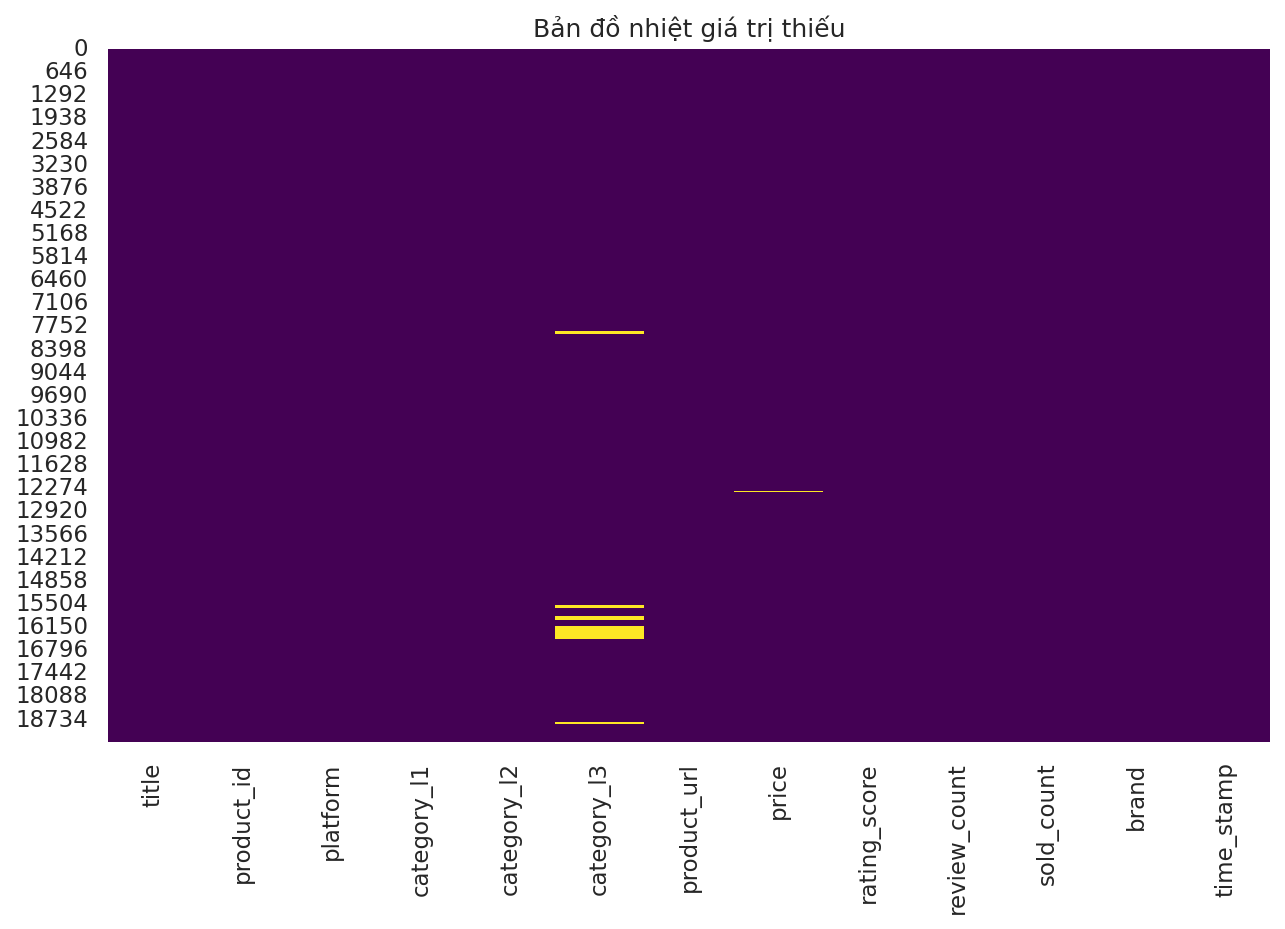

In [70]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title('Bản đồ nhiệt giá trị thiếu')
plt.show()

In [71]:
# Phân data vào 4 nhóm ngành chính
category_cols = ['category_l1', 'category_l2', 'category_l3']
for col in category_cols:
    df[col] = df[col].str.lower()

electronics_list = [
    'thiết bị số - phụ kiện số',
    'laptop - máy vi tính - linh kiện',
    'máy ảnh - máy quay phim',
    'điện thoại - máy tính bảng',
    'thiết bị điện tử',
    'phụ kiện điện tử'
]

fashion_list = [
    'phụ kiện thời trang',
    'thời trang nữ',
    'đồng hồ và trang sức',
    'thời trang nam',
    'balo và vali',
    'giày - dép nam',
    'túi thời trang nam',
    'túi thời trang nữ',
    'giày - dép nữ',
    'thời trang & phụ kiện trẻ em',
    'thời trang & phụ kiện nam',
    'thời trang & phụ kiện nữ'
]

homeliving_list = [
    'nhà cửa - đời sống',
    'điện gia dụng',
    'chăm sóc nhà cửa',
    'điện tử - điện lạnh',
    'hàng gia dụng & đời sống',
    'tv & thiết bị điện gia dụng'
]

beauty_list = [
    'làm đẹp - sức khỏe',
    'sức khỏe & làm đẹp'
]

df.loc[df['category_l1'].isin(electronics_list), 'industry_group'] = 'electronics & tech'

df.loc[df['category_l1'].isin(fashion_list), 'industry_group'] = 'fashion & accessories'

df.loc[df['category_l1'].isin(homeliving_list), 'industry_group'] = 'home & living'

df.loc[df['category_l1'].isin(beauty_list), 'industry_group'] = 'beauty & health'

df.head()

,title,product_id,platform,category_l1,category_l2,category_l3,product_url,price,rating_score,review_count,sold_count,brand,time_stamp,industry_group
0,Giá Treo Màn Hình LCD Gắn Bàn NB J7 Hồng LED R...,278994044,tiki,điện tử - điện lạnh,âm thanh & phụ kiện tivi,phụ kiện tivi,https://tiki.vn/product-p278994044.html?spid=2...,2080000.0,0.0,0,0,T-WOLF,2026-04-29 13:39:25,home & living
1,Giá Treo Màn Hình LCD Gắn Bàn NB L70 LED RGB (...,278994036,tiki,điện tử - điện lạnh,âm thanh & phụ kiện tivi,phụ kiện tivi,https://tiki.vn/product-p278994036.html?spid=2...,2080000.0,0.0,0,0,T-WOLF,2026-04-29 13:39:25,home & living
2,"Giá Treo Hai Màn Hình LCD NB H180 (17"" - 27"") ...",278973268,tiki,điện tử - điện lạnh,âm thanh & phụ kiện tivi,phụ kiện tivi,https://tiki.vn/product-p278973268.html?spid=2...,741000.0,0.0,0,0,T-WOLF,2026-04-29 13:39:25,home & living
3,"Giá Treo Hai Màn Hình LCD NB P160 (17"" - 27"") ...",278973234,tiki,điện tử - điện lạnh,âm thanh & phụ kiện tivi,phụ kiện tivi,https://tiki.vn/product-p278973234.html?spid=2...,650000.0,0.0,0,0,T-WOLF,2026-04-29 13:39:25,home & living
4,Tivi box Xiaomi Mi Box S EU 4K- Tiếng Việt - H...,278930055,tiki,điện tử - điện lạnh,âm thanh & phụ kiện tivi,"android tv box, smart box",https://tiki.vn/product-p278930055.html?spid=1...,1890000.0,0.0,0,7,Xiaomi,2026-04-29 13:39:25,home & living


## 2. Phân phối dữ liệu theo sàn và nhóm ngành

> **Câu hỏi:** Dữ liệu có phân phối đều giữa các sàn và nhóm ngành không? Số lượng thực tế so với quota thu thập ban đầu ra sao?

Chúng tôi phân loại toàn bộ sản phẩm vào 4 nhóm ngành dựa trên `category_l1`, sau đó so sánh với quota đặt ra để đánh giá mức độ hoàn thành và cân bằng của dataset.

                                Thực tế  Quota
industry_group        platform                
beauty & health       lazada       2143   2138
                      tiki          689    700
electronics & tech    lazada       2583   2743
                      tiki         1660   1687
fashion & accessories lazada       4453   4658
                      tiki         1323   1335
home & living         lazada       4006   4787
                      tiki         2504   2749


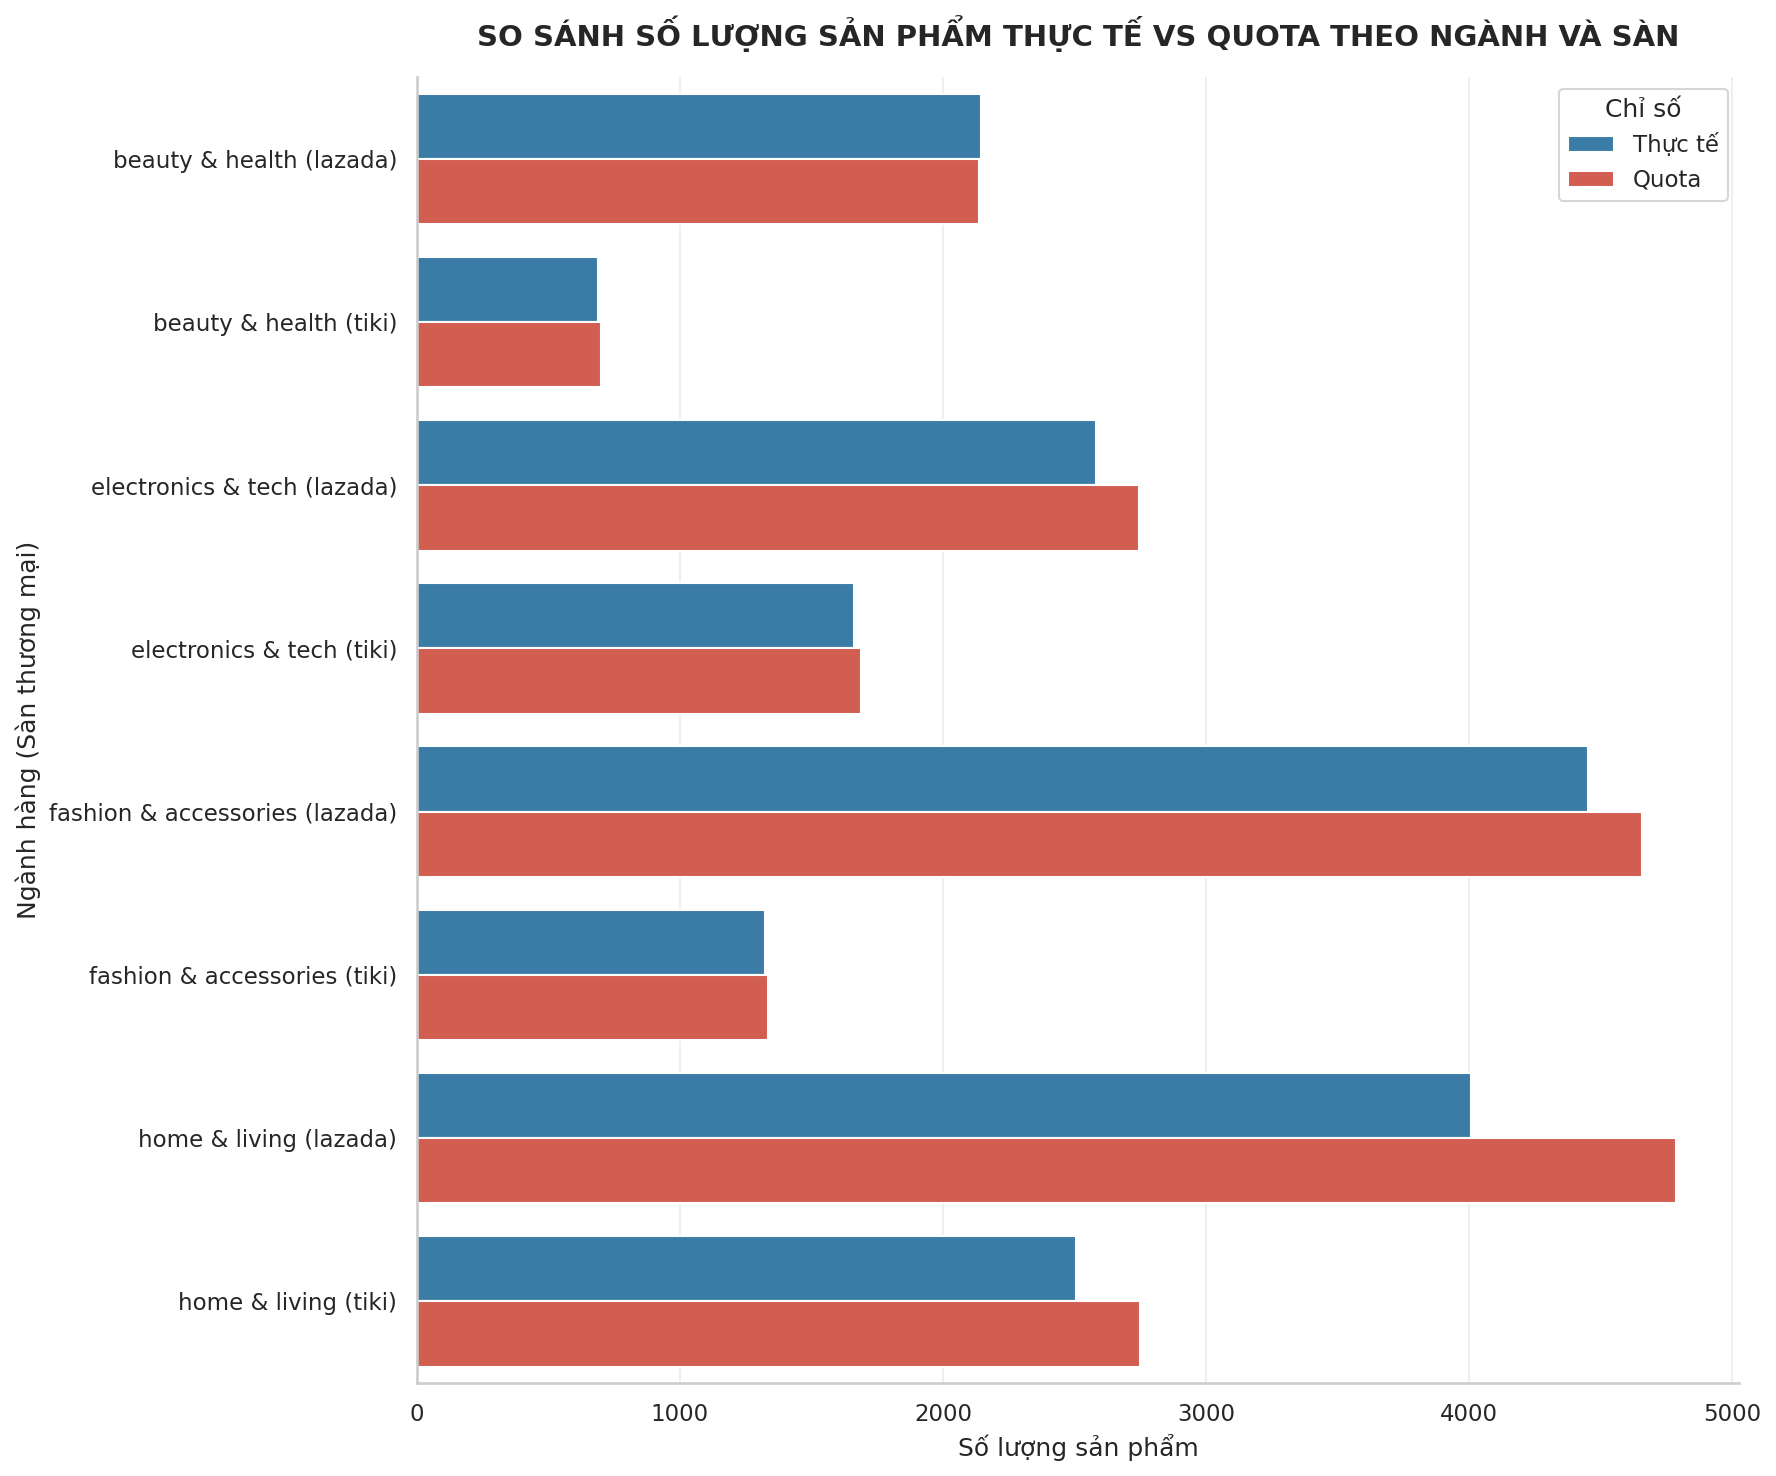

In [72]:
pivot_df = df.pivot_table(
    index=['industry_group', 'platform'],
    values='product_id',
    aggfunc='count'
).rename(columns={'product_id': 'Thực tế'})


pivot_df['Quota'] = 0

# (Ngành, Sàn): Giá_trị_quota)
quota_dict = {
    ('electronics & tech', 'tiki'): 1687,
    ('electronics & tech', 'lazada'): 2743,
    ('home & living', 'tiki'): 2749,
    ('home & living', 'lazada'): 4787,
    ('fashion & accessories', 'tiki'): 1335,
    ('fashion & accessories', 'lazada'): 4658,
    ('beauty & health', 'tiki'): 700,
    ('beauty & health', 'lazada'): 2138
}

for key, value in quota_dict.items():
    if key in pivot_df.index:
        pivot_df.loc[key, 'Quota'] = value


plot_df = pivot_df.reset_index()

melted_df = plot_df.melt(
    id_vars=['industry_group', 'platform'],
    value_vars=['Thực tế', 'Quota'],
    var_name='Chỉ số',
    value_name='Số lượng sản phẩm'
)

melted_df['Ngành - Sàn'] = melted_df['industry_group'] + " (" + melted_df['platform'] + ")"

fig, ax = plt.subplots(figsize=(12, 10))

sns.barplot(
    data=melted_df,
    x='Số lượng sản phẩm',
    y='Ngành - Sàn',
    hue='Chỉ số',
    ax=ax,
    palette=PALETTE_DUAL
)

ax.set_title('SO SÁNH SỐ LƯỢNG SẢN PHẨM THỰC TẾ VS QUOTA THEO NGÀNH VÀ SÀN', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Số lượng sản phẩm', fontsize=12)
ax.set_ylabel('Ngành hàng (Sàn thương mại)', fontsize=12)

plt.tight_layout()
plt.savefig('actual_vs_quota_chart.png', dpi=300)

print(pivot_df)

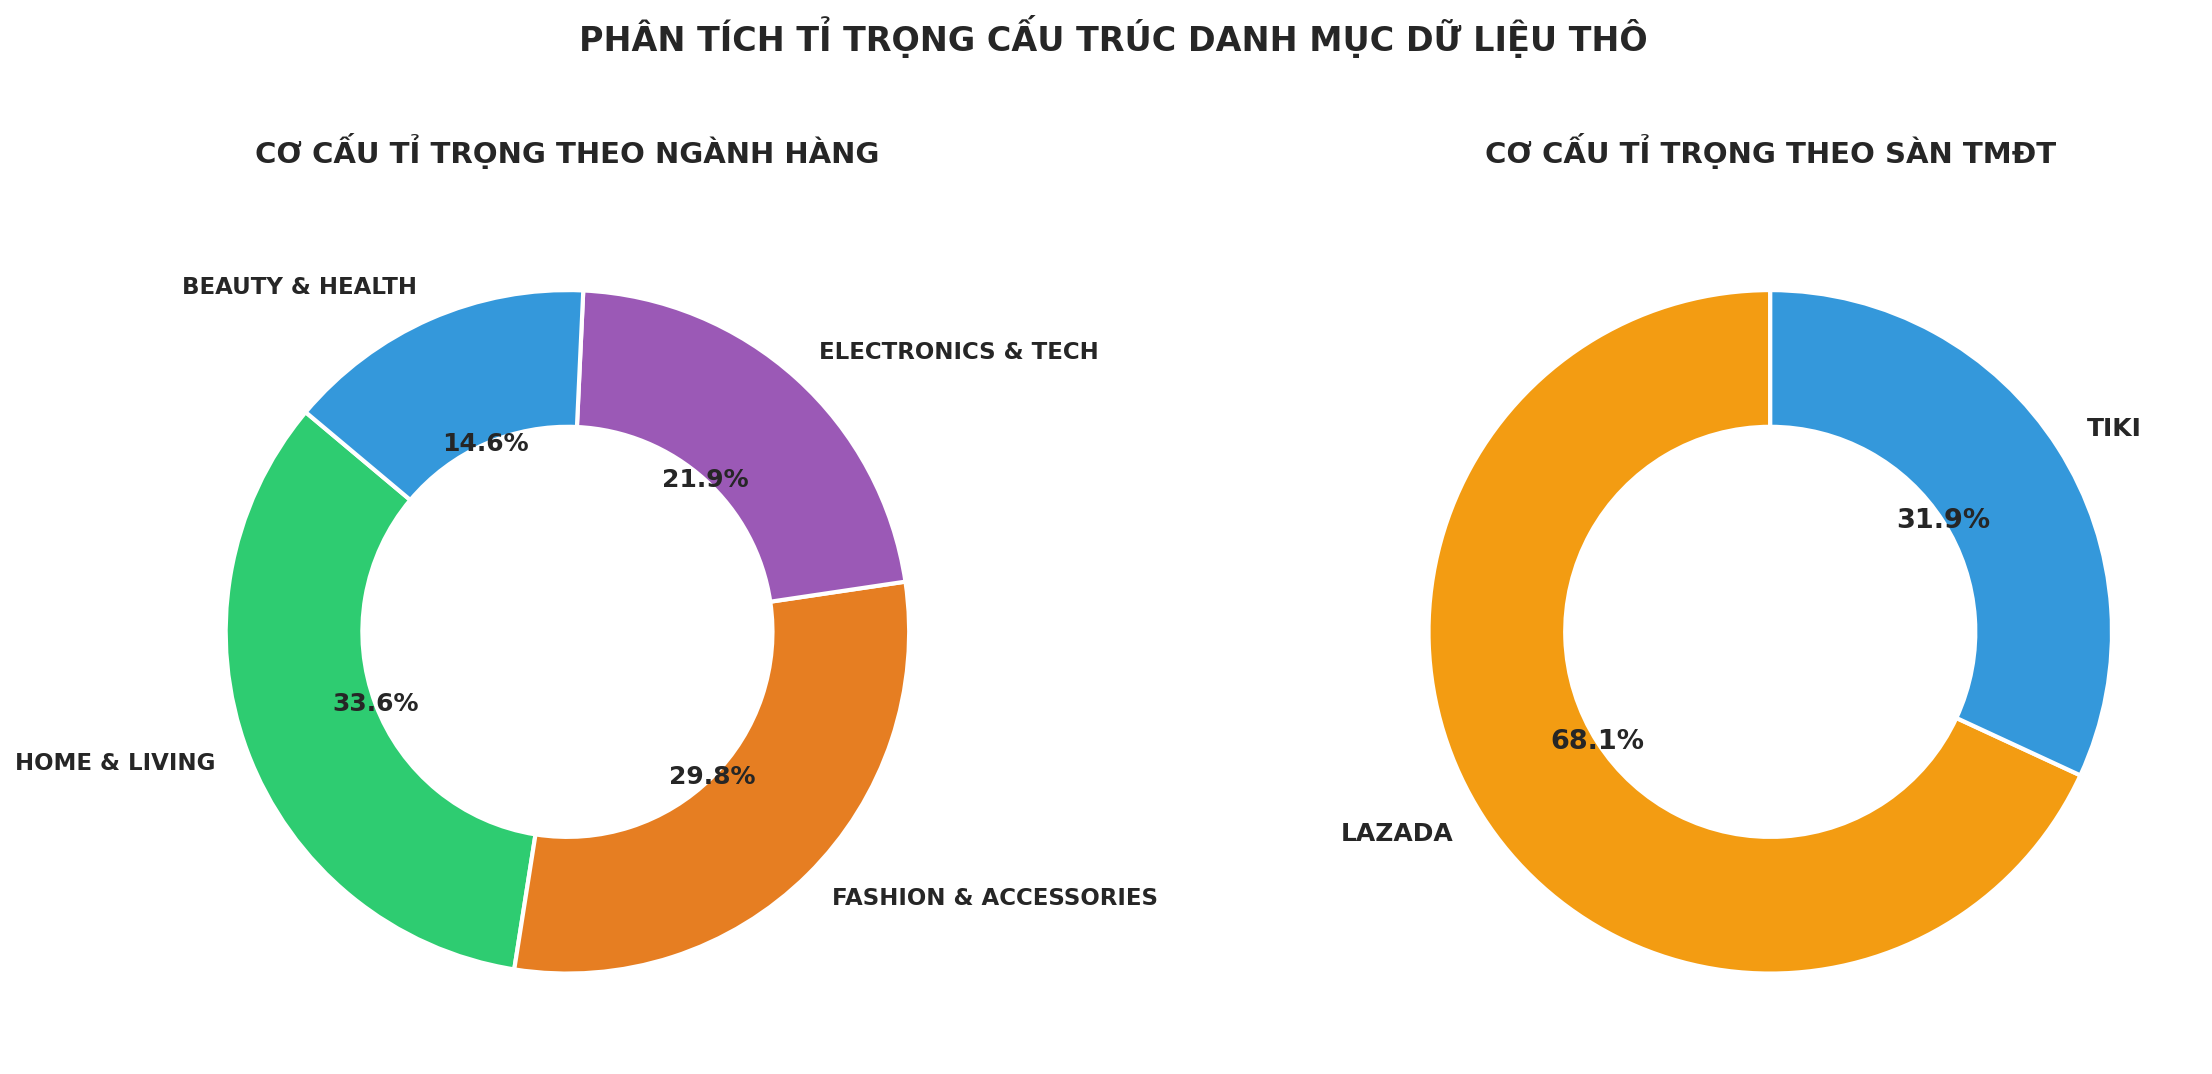

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Tỉ trọng theo từng nhóm ngành
ind_counts = df['industry_group'].value_counts()

wedges1, texts1, autotexts1 = axes[0].pie(
    ind_counts,
    labels=[str(i).upper() for i in ind_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=PALETTE_IND[:len(ind_counts)],
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), # wedgeprops tạo lỗ khuyết Donut
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
for autotext in autotexts1:
    autotext.set_fontsize(12)

axes[0].set_title('CƠ CẤU TỈ TRỌNG THEO NGÀNH HÀNG', fontweight='bold', fontsize=14, pad=20)


# Tỉ trọng theo từng sàn
plat_counts = df['platform'].value_counts()
brand_colors = [PLATFORM_PALETTE[p] for p in plat_counts.index]

wedges2, texts2, autotexts2 = axes[1].pie(
    plat_counts,
    labels=[str(p).upper() for p in plat_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=brand_colors,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

for autotext in autotexts2:
    autotext.set_fontsize(13)

axes[1].set_title('CƠ CẤU TỈ TRỌNG THEO SÀN TMĐT', fontweight='bold', fontsize=14, pad=20)

plt.suptitle('PHÂN TÍCH TỈ TRỌNG CẤU TRÚC DANH MỤC DỮ LIỆU THÔ',
             fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Insight — Phân phối dữ liệu:**
- Lazada chiếm tỷ trọng lớn hơn Tiki ở tất cả nhóm ngành — cần lưu ý khi đánh giá mô hình NER theo sàn.
- Nhóm **Fashion & Accessories** có số lượng lớn nhất, phù hợp đặc điểm TMĐT Việt Nam.
- Tất cả nhóm ngành đều đạt hoặc xấp xỉ quota → dataset đủ đại diện cho 4 miền dữ liệu.
- **Quyết định pipeline:** Gán nhãn `industry_group` ngay từ bước đầu để hỗ trợ phân tích phân tầng (stratified) ở các bước tiếp theo.

## 3. Phân tích nhiễu (Noise Analysis)

> **Câu hỏi:** Dữ liệu tiêu đề thô chứa những loại nhiễu nào? Mức độ và phân phối từng loại ra sao?

Phân tích nhiễu được chia thành 3 tầng: **(1) nhiễu ký tự**, **(2) nhiễu ngôn ngữ**, và **(3) nhiễu ngữ nghĩa**. Kết quả mỗi tầng là cơ sở thiết kế một bước cụ thể trong `CleaningPipeline._clean_text_logic()`.

### 3.1 Nhiễu ký tự (Character-level Noise)

Nhiễu ký tự bao gồm: emoji, thẻ HTML, URL, khoảng trắng thừa. Chúng tôi trước tiên thống kê tần suất từng ký tự nhiễu để xác định pattern regex, sau đó định lượng tỷ lệ ảnh hưởng theo loại, sàn, và ngành.

In [74]:
# Hàm trích xuất tất cả các ký tự nhiễu trong một chuỗi
def extract_noise(text):
    if pd.isna(text):
        return []

    text = unicodedata.normalize('NFC', str(text))
    return re.findall(r'[^\w\s,.\-/\"\'\–%\‑\°×\+&:*\×\>\″\”\℃@]', str(text))

# Áp dụng cho toàn bộ cột title và gộp thành một danh sách lớn
all_noise = []
df['title'].apply(lambda x: all_noise.extend(extract_noise(x)))

# Đếm tần suất xuất hiện của từng ký tự nhiễu
noise_counts = Counter(all_noise)

# Chuyển thành DataFrame để dễ quan sát và sort
df_noise_freq = pd.DataFrame(noise_counts.items(), columns=['Noise_Character', 'Frequency'])
df_noise_freq.sort_values(by='Frequency', ascending=False, inplace=True)

# in ra danh sách các kí tự nhiễu
print("Danh sách các ký tự nhiễu:")
print(df_noise_freq['Noise_Character'].tolist())

print("Top 10 ký tự nhiễu xuất hiện nhiều nhất:")
print(df_noise_freq.head(10))

Danh sách các ký tự nhiễu:
[')', '(', '[', ']', '|', '】', '【', '❤', '🔥', '#', '️', '!', '⚡', '，', '{', '🇳', '}', '🇻', '~', '🌠', ';', '💥', '’', '💓', '\u200b', '🎀', '🧧', '💖', '🏮', '^', '\\', '👉', '🔩', '🔗', '🔧', '<', '（', '🌸', '🚀', '🎁', '🍀', '…', '✨', '♥', '✅', '̣', '👍', '💝', '）', '❖', '\ufeff', '®', '⛔', '🌟', '★', '❣', '🥰', '🐻', '🌻', '💋', '💕', '¡', '🌷', '⭐', '🛵', '=', '￼', '·', '🚗', '⚜', '👙', '📸', '̛', '❌', '💟', '🍄', '📷', '́', '̃', '$', '🔖', '🍓', '👑', '❄', '✓', '🛑', '🎋', '̂', '💯', '™', '👜', '̆', '≤', '🌿', '\x08', '🔈', '🤗', '✍', '✏', '🖊', '✔', '—', '🎄', '🦷', '☃', '｜', '🌰', '👩', '🛁', '＞', '＜', '`', '🍁', '�', '≯', '≮', '🤝']
Top 10 ký tự nhiễu xuất hiện nhiều nhất:
   Noise_Character  Frequency
1                )       2274
0                (       2270
2                [       1176
3                ]       1171
4                |        902
10               】        126
9                【        126
28               ❤         47
29               🔥         43
8                #         42


In [75]:
# Xem những dòng có chứa kí tự nhiễu để điều chỉnh (vì một số kí hiệu có ý nghĩa trong 1 vài domain)
condition = df['title'].str.contains('@',na=False)

df_filtered = df[condition]
df_filtered['title'].tolist()

['Nồi Kho Cá JLPL@L JL-KC2510 2.5L - Màu Ngẫu Nhiên - Hàng Chính Hãng',
 'Dây Cáp Thunderbolt 3 (Chuẩn Intel) Choetech Hỗ Trợ Truyền Tải 40Gbps, Sạc PD 100W, Video 4K @ 60Hz kép / 5K 0.7m A3007 - Hàng Chính Hãng',
 'Hub chuyển đổi USB Type C 5 IN 1 Ugreen 15495 CM136 ( USB C to HD 4K@30Hz - USB 3.0 5Gbps, PD100W)',
 'Máy giặt Aqua inverter 10.0 kg giá rẻ đã qua sử dụng, nguyên zin chỉ ship HCM. Chat @392.135.024 trước khi đặt hàng',
 'Thanh lý máy giặt Toshiba inverter 10.0 kg đã qua sử dụng, nguyên zin chỉ ship HCM và tỉnh lân cận. Chat @392.135.024 trước khi đặt hàng',
 'Máy giặt Electrolux inverter 10.0 kg giá rẻ đã qua sử dụng, nguyên zin chỉ ship HCM. Chat  @392.135.024 trước khi đặt hàng',
 'Tủ Lạnh SANYO SR-125PN 120L – Nhỏ Gọn, Tiết Kiệm Điện, Phù Hợp Gia Đình Nhỏ - Sinh Viên. lh: @394_@63_632']

In [76]:
VALID_PREFIXES = {'03', '05', '07', '08', '09'}

def find_phone_numbers(text):
    if pd.isna(text):
        return []

    results = set()

    def is_valid(num):
        return len(num) == 10 and num[:2] in VALID_PREFIXES

    # Dạng 1: Số chuẩn 10 số (0966717185)
    for m in re.finditer(r'(?<!\d)(0[3-9]\d{8})(?!\d)', text):
        if is_valid(m.group(1)):
            results.add(m.group(1))

    # Dạng 2: Số có dấu chấm xen giữa (0966.71.71.85 / 0939.622220)
    for m in re.finditer(r'(?<!\d)(0[3-9][\d\.]{9,12})(?!\d)', text):
        clean = m.group(1).replace('.', '')
        if is_valid(clean):
            results.add(clean)

    # Dạng 3: @ thay 0, ngăn cách bằng . hoặc _ (@392.135.024 / @394_@63_632)
    for m in re.finditer(r'@[\d\.\_@]+', text):
        clean = m.group().replace('@', '0').replace('_', '').replace('.', '')
        if is_valid(clean):
            results.add(clean)

    return sorted(results)


df['extracted_phones'] = df['title'].apply(find_phone_numbers)
df_found = df[df['extracted_phones'].map(len) > 0].copy()

print(f"Tổng số dòng tìm được: {len(df_found)}")
print(df_found[['title', 'extracted_phones']].head(32).to_string())

Tổng số dòng tìm được: 32
                                                                                                                                                                                                title extracted_phones
3104                                                                                                                               Tủ quần áo ALALA236 gỗ HMR chống nước - www.ALALA.vn - 0939.622220     [0939622220]
3141                                                                                                                                 Bộ bàn ăn ALALA941 gỗ HMR chống nước - ww.ALALA.vn - 0939.622220     [0939622220]
7923   màn hình máy tính Hp P17A led vuông đẹp ceng rẻ, màn ko lỗi gì. Thanh lý cty ngoại hình 95% Bán gía: 400k full dây bh 1thang Mua tai: 55/108/2 Nguyễn văn cong p3 gò vấp tphcm Zalo 0977751950     [0977751950]
18976                                                                                                         máy 

/tmp/ipykernel_1123/1305749711.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_stats, x='Tỷ lệ (%)', y='Loại nhiễu', palette=PALETTE_MAIN)


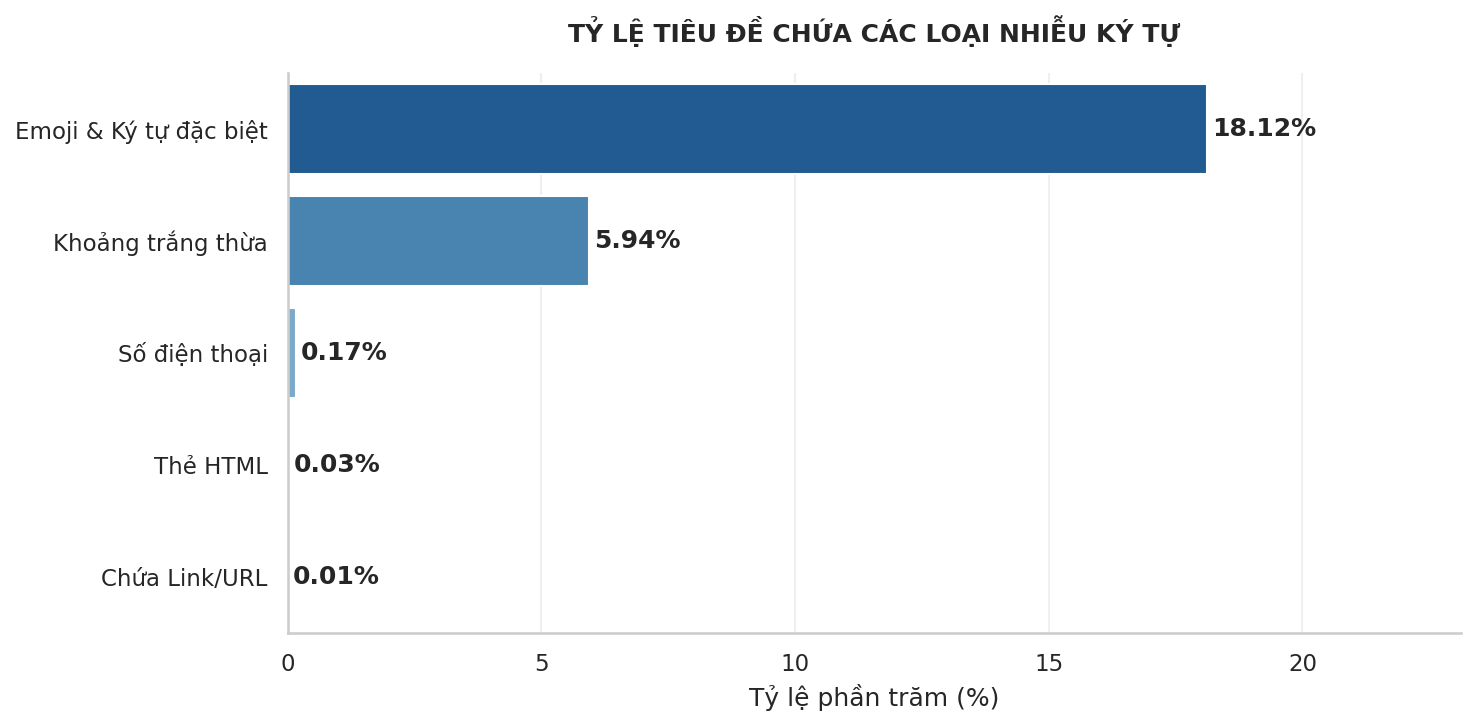

/tmp/ipykernel_1123/1305749711.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=platform_noise, x='platform', y='has_char_noise', ax=axes[0], palette=PLATFORM_PALETTE)
/tmp/ipykernel_1123/1305749711.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=industry_noise, y='industry_group', x='has_char_noise', ax=axes[1], palette=PALETTE_IND)


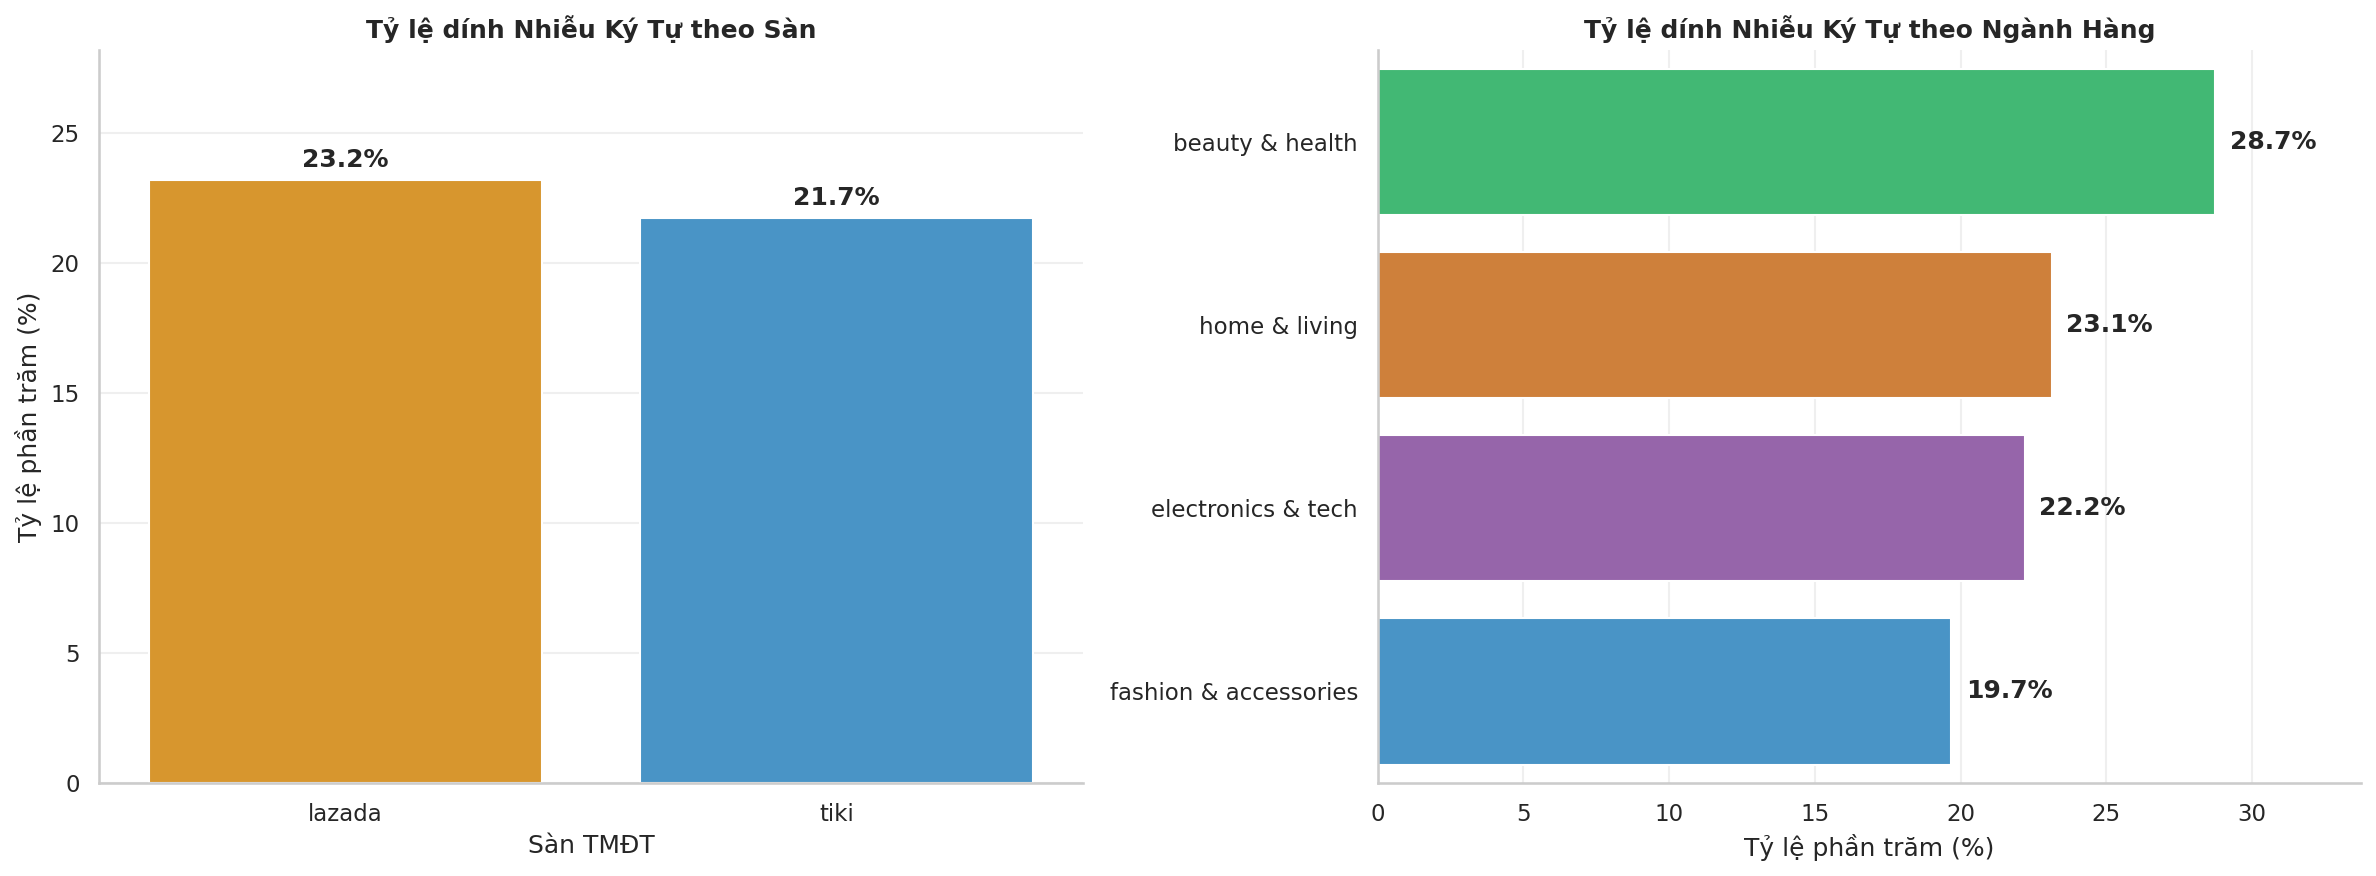

BẢNG VÍ DỤ 2 TIÊU ĐỀ THỰC TẾ CHO MỖI LOẠI NHIỄU KÝ TỰ


,Loại nhiễu,Tiêu đề thực tế
0,Emoji & Ký tự đặc biệt,Giá Treo Màn Hình LCD Gắn Bàn NB J7 Hồng LED R...
1,Emoji & Ký tự đặc biệt,Giá Treo Màn Hình LCD Gắn Bàn NB L70 LED RGB (...
2,Thẻ HTML,<br> 3.5 mm stereo female 2 male AV cable auxi...
3,Thẻ HTML,Top <br>Wall mount black Metal surveillance ca...
4,Chứa Link/URL,Tủ quần áo ALALA236 gỗ HMR chống nước - www.AL...
5,Khoảng trắng thừa,Remote Điều khiển dành cho tivi led Darling Sm...
6,Khoảng trắng thừa,Camera IP Speed Dome HIKVISION DS-2DE4xx5IW-DE...
7,Số điện thoại,Tủ quần áo ALALA236 gỗ HMR chống nước - www.AL...
8,Số điện thoại,Bộ bàn ăn ALALA941 gỗ HMR chống nước - ww.ALAL...


In [77]:
import unicodedata

def detect_char_noise(df, text_col='title'):
    df_noise = df.copy()

    # 1. Emoji & Ký tự đặc biệt
    noise_pattern = r'[^\w\s,.\|\-/\"\'\\–%\‑\°×\+&:*#\×\>\″\"\℃]'
    df_noise['noise_special_chars'] = df_noise[text_col].apply(
        lambda x: bool(re.search(noise_pattern, unicodedata.normalize('NFC', str(x))))
    )

    # 2. Thẻ HTML
    df_noise['noise_html'] = df_noise[text_col].str.contains(r'<[^>]+>', regex=True, na=False)

    # 3. Link / URL
    df_noise['noise_link'] = df_noise[text_col].str.contains(r'http[s]?://\S+|www\.\S+', regex=True, na=False)

    # 4. Khoảng trắng thừa
    df_noise['noise_spaces'] = df_noise[text_col].str.contains(r'^\s+|\s+$|\s{2,}', regex=True, na=False)

    # 5. Số điện thoại (chuẩn / dấu chấm / @ obfuscation)
    VALID_PREFIXES = {'03', '05', '07', '08', '09'}

    def has_phone(text):
        if pd.isna(text): return False
        text = str(text)
        def is_valid(n): return len(n) == 10 and n[:2] in VALID_PREFIXES
        # Dạng chuẩn
        if any(is_valid(m.group(1)) for m in re.finditer(r'(?<!\d)(0[3-9]\d{8})(?!\d)', text)):
            return True
        # Dạng dấu chấm
        for m in re.finditer(r'(?<!\d)(0[3-9][\d\.]{9,12})(?!\d)', text):
            if is_valid(m.group(1).replace('.', '')): return True
        # Dạng @ obfuscation
        for m in re.finditer(r'@[\d\.\_@]+', text):
            clean = m.group().replace('@','0').replace('_','').replace('.','')
            if is_valid(clean): return True
        return False

    df_noise['noise_phone'] = df_noise[text_col].apply(has_phone)

    df_noise['has_char_noise'] = df_noise[[
        'noise_special_chars', 'noise_html', 'noise_link', 'noise_spaces', 'noise_phone'
    ]].any(axis=1)

    return df_noise

df_char_noise = detect_char_noise(df, text_col='title')

noise_mapping = {
    'noise_special_chars': 'Emoji & Ký tự đặc biệt',
    'noise_html': 'Thẻ HTML',
    'noise_link': 'Chứa Link/URL',
    'noise_spaces': 'Khoảng trắng thừa',
    'noise_phone': 'Số điện thoại'
}

# Biểu đồ phân phối 4 loại nhiễu
stats = []
total_rows = len(df_char_noise)
for col, name in noise_mapping.items():
    count = df_char_noise[col].sum()
    stats.append({'Loại nhiễu': name, 'Tỷ lệ (%)': (count / total_rows) * 100})

df_stats = pd.DataFrame(stats).sort_values(by='Tỷ lệ (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_stats, x='Tỷ lệ (%)', y='Loại nhiễu', palette=PALETTE_MAIN)
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.1, p.get_y() + p.get_height()/2, f'{width:.2f}%', va='center', fontweight='bold')

plt.title('TỶ LỆ TIÊU ĐỀ CHỨA CÁC LOẠI NHIỄU KÝ TỰ', fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ phần trăm (%)')
plt.ylabel('')
plt.xlim(0, df_stats['Tỷ lệ (%)'].max() + 5)
plt.tight_layout()
plt.show()

# Phân phối nhiễu theo sàn, nhóm ngành
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

platform_noise = (df_char_noise.groupby('platform')['has_char_noise'].mean() * 100).reset_index()
sns.barplot(data=platform_noise, x='platform', y='has_char_noise', ax=axes[0], palette=PLATFORM_PALETTE)
for p in axes[0].patches:
    height = p.get_height()
    axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Tỷ lệ dính Nhiễu Ký Tự theo Sàn', fontweight='bold')
axes[0].set_ylabel('Tỷ lệ phần trăm (%)')
axes[0].set_xlabel('Sàn TMĐT')
axes[0].set_ylim(0, platform_noise['has_char_noise'].max() + 5)

industry_noise = (df_char_noise.groupby('industry_group')['has_char_noise'].mean() * 100).reset_index().sort_values('has_char_noise', ascending=False)
sns.barplot(data=industry_noise, y='industry_group', x='has_char_noise', ax=axes[1], palette=PALETTE_IND)
for p in axes[1].patches:
    width = p.get_width()
    axes[1].text(width + 0.5, p.get_y() + p.get_height()/2., f'{width:.1f}%', va='center', fontweight='bold')
axes[1].set_title('Tỷ lệ dính Nhiễu Ký Tự theo Ngành Hàng', fontweight='bold')
axes[1].set_xlabel('Tỷ lệ phần trăm (%)')
axes[1].set_ylabel('')
axes[1].set_xlim(0, industry_noise['has_char_noise'].max() + 5)

plt.tight_layout()
plt.show()

examples = []
for col, name in noise_mapping.items():
    samples = df_char_noise[df_char_noise[col] == True]['title'].head(2).tolist()
    for s in samples:
        examples.append({'Loại nhiễu': name, 'Tiêu đề thực tế': s})

print("BẢNG VÍ DỤ 2 TIÊU ĐỀ THỰC TẾ CHO MỖI LOẠI NHIỄU KÝ TỰ")
display(pd.DataFrame(examples))

**Insight — Nhiễu ký tự:**
- **Emoji và ký tự đặc biệt** là loại nhiễu phổ biến nhất — cần chuẩn hóa bắt buộc trước mọi bước tokenize.
- Nhóm **Fashion** có tỷ lệ nhiễu emoji cao nhất — seller thời trang dùng emoji để thu hút sự chú ý trong kết quả tìm kiếm.
- **Số điện thoại** được người bán cố tình thêm vào, cần loại bỏ vì sẽ gây rò rỉ dữ liệu.
- **Quyết định pipeline:** Áp dụng regex whitelist-based cleaning, giữ lại các ký tự có ý nghĩa trong TMĐT (`%`, `x`, `°`, `+`, `&`) và loại bỏ toàn bộ 5 loại nhiễu trên.

In [78]:
# Loại bỏ các kí tự nhiễu
def remove_noise(df, text_column):
    df_clean = df.copy()

    def clean_title(text):
      if not isinstance(text, str): return text

      # 1. Chuẩn hóa Unicode (NFC)
      text = unicodedata.normalize('NFC', text)

      # 2. Xóa thẻ HTML
      text = re.sub(r'<[^>]+>', ' ', text)

      # 3. Xóa Link / URL
      text = re.sub(r'http[s]?://\S+|www\.\S+', ' ', text)

      # 4. Xóa số điện thoại (chuẩn / dấu chấm / @ obfuscation)
      text = re.sub(r'(?<!\d)(0[3-9]\d{8})(?!\d)', ' ', text)           # chuẩn 10 số
      text = re.sub(r'(?<!\d)(0[3-9][\d\.]{9,12})(?!\d)', ' ', text)    # dấu chấm xen
      text = re.sub(r'@[\d\.\_@]+', ' ', text)                           # @ obfuscation

      # 5. Thay _ bằng khoảng trắng
      text = re.sub(r'_', ' ', text)

      # 6. Lọc ký tự nhiễu
      text = re.sub(r'[^\w\s,.\-/\"\'\–%\‑\°×\+&:*\>\″\"\℃]', '', text)

      # 7. Thu gọn khoảng trắng thừa
      text = re.sub(r'\s+', ' ', text).strip()
      return text

    df_clean['title_clean'] = df_clean[text_column].apply(clean_title)
    return df_clean

In [79]:
df = remove_noise(df, 'title')

In [80]:
def check_cleaning_pipeline(df, original_col='title', cleaned_col='title_clean'):
    """
    Kiểm tra kết quả sau khi chạy CleaningPipeline.
    So sánh cột gốc và cột đã clean, báo cáo những gì còn sót.
    """
    VALID_PREFIXES = {'03', '05', '07', '08', '09'}

    def has_phone(text):
        def is_valid(n): return len(n) == 10 and n[:2] in VALID_PREFIXES
        for m in re.finditer(r'(?<!\d)(0[3-9]\d{8})(?!\d)', text):
            if is_valid(m.group(1)): return True
        for m in re.finditer(r'(?<!\d)(0[3-9][\d\.]{9,12})(?!\d)', text):
            if is_valid(m.group(1).replace('.', '')): return True
        for m in re.finditer(r'@[\d\.\_@]+', text):
            clean = m.group().replace('@','0').replace('_','').replace('.','')
            if is_valid(clean): return True
        return False

    def has_html(text):
        return bool(re.search(r'<[^>]+>', text))

    def has_url(text):
        return bool(re.search(r'https?://\S+|www\.\S+', text))

    def has_extra_spaces(text):
        return bool(re.search(r'^\s+|\s+$|\s{2,}', text))

    def has_weird_chars(text):
        # Cho phép: ký tự tiếng Việt, ASCII cơ bản, ký hiệu TMĐT hợp lệ
        return bool(re.search(r'[^\w\s,.\/\"\'\>\–%\‑\°×\+&:*\″\"\℃\-]', text))

    checks = {
        'SĐT còn sót':        has_phone,
        'Thẻ HTML còn sót':   has_html,
        'URL còn sót':        has_url,
        'Khoảng trắng thừa':  has_extra_spaces,
        'Ký tự lạ còn sót':   has_weird_chars,
    }

    col = df[cleaned_col].dropna().astype(str)
    total = len(col)

    print("=" * 60)
    print("KIỂM TRA SAU CLEANING PIPELINE")
    print("=" * 60)
    all_pass = True
    for name, fn in checks.items():
        flagged = col[col.apply(fn)]
        count = len(flagged)
        status = "✅" if count == 0 else "⚠️"
        print(f"  {status} {name:<22}: {count:>5} / {total} ({count/total*100:.2f}%)")
        if count > 0:
            all_pass = False
            for t in flagged.head(3):
                print(f"       └─ {t[:90]}")

    print("-" * 60)
    print(f"  {'✅ Tất cả sạch' if all_pass else '⚠️  Còn vấn đề cần xem lại'}")
    print("=" * 60)


# Cách dùng
check_cleaning_pipeline(df, original_col='title', cleaned_col='title_clean')

KIỂM TRA SAU CLEANING PIPELINE
  ✅ SĐT còn sót           :     0 / 19361 (0.00%)
  ✅ Thẻ HTML còn sót      :     0 / 19361 (0.00%)
  ✅ URL còn sót           :     0 / 19361 (0.00%)
  ✅ Khoảng trắng thừa     :     0 / 19361 (0.00%)
  ✅ Ký tự lạ còn sót      :     0 / 19361 (0.00%)
------------------------------------------------------------
  ✅ Tất cả sạch


### 3.2 Nhiễu ngôn ngữ (Language-level Noise)

Tiêu đề sản phẩm TMĐT Việt Nam thường chứa hỗn hợp tiếng Việt, tiếng Anh (tên thương hiệu, thông số kỹ thuật), và code-switching. Phân tích này nhằm **định lượng phân phối ngôn ngữ** để quyết định có nên áp dụng language filtering hay không, và nếu có thì theo ngưỡng nào.

#### Thử nghiệm 1: Nhận diện ngôn ngữ với `langdetect`

Phương pháp đầu tiên được thử nghiệm là `langdetect` (Naive Bayes trên N-gram ký tự). Đây là công cụ phổ biến cho language detection trên văn bản thông thường.

In [81]:
pip install langdetect

In [82]:
from langdetect import detect, detect_langs

def detect_language_safe(text):
    """
    Hàm nhận diện ngôn ngữ an toàn cho từng dòng văn bản.
    Trả về mã ngôn ngữ (vi, en, ...) hoặc 'unknown' nếu dữ liệu lỗi.
    """
    # Kiểm tra nếu dòng dữ liệu bị rỗng hoặc không phải chuỗi
    if not isinstance(text, str) or text.strip() == "":
        return "unknown"

    # Loại bỏ bớt số và ký tự đặc biệt trước khi đưa vào máy đoán
    # để giảm nhiễu cho thuật toán Naive Bayes của langdetect
    clean_text = ''.join([c for c in text if c.isalpha() or c.isspace()])
    if clean_text.strip() == "":
        return "unknown"

    try:
        # Hàm detect() sẽ trả về ngôn ngữ có xác suất cao nhất (ví dụ: 'vi', 'en')
        return detect(clean_text)
    except Exception:
        # Tránh crash nếu câu quá ngắn hoặc chỉ chứa ký tự lạ langdetect không học
        return "unknown"

def detect_language_probability(text):
    """
    Hàm nâng cao: Trả về mức độ tự tin (Xác suất %) của ngôn ngữ dự đoán.
    """
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    try:
        # detect_langs trả về danh sách kèm xác suất, ví dụ: [vi:0.9999]
        predictions = detect_langs(text)
        # Lấy xác suất của ngôn ngữ đứng đầu
        return predictions[0].prob
    except Exception:
        return 0.0

df['lang_detected'] = df['title_clean'].apply(detect_language_safe)
df['lang_prob'] = df['title_clean'].apply(detect_language_probability)

print("=== KẾT QUẢ PHÂN LOẠI NGÔN NGỮ BẰNG LANGDETECT ===")
print(df[['title_clean', 'lang_detected', 'lang_prob']].head(10))

=== KẾT QUẢ PHÂN LOẠI NGÔN NGỮ BẰNG LANGDETECT ===
                                         title_clean lang_detected  lang_prob
0  Giá Treo Màn Hình LCD Gắn Bàn NB J7 Hồng LED R...            vi   0.999998
1  Giá Treo Màn Hình LCD Gắn Bàn NB L70 LED RGB 3...            vi   0.999999
2  Giá Treo Hai Màn Hình LCD NB H180 17" - 27" – ...            vi   0.999999
3  Giá Treo Hai Màn Hình LCD NB P160 17" - 27" – ...            vi   0.999997
4  Tivi box Xiaomi Mi Box S EU 4K- Tiếng Việt - H...            vi   0.999999
5  Khung Treo Tivi XOAY P65 Dành Cho Tivi 55 Inch...            vi   1.000000
6  Remote Điều khiển dành cho tivi led Darling Sm...            vi   0.999999
7  Khung treo tivi nghiêng D01 Thiết Kế Nghiêng, ...            vi   1.000000
8  Camera IP Wifi IMOU A42P 4.0MP Giám Sát An Nin...            vi   0.999998
9  Camera IP Wifi Trong Nhà EZVIZ C6N 1080p CS-C6...            vi   0.999996


In [83]:
not_vi = df[df['lang_detected'] != 'vi']
not_vi[['title_clean', 'lang_detected', 'lang_prob']]

,title_clean,lang_detected,lang_prob
49,Apple iPhone 17e,fr,0.714282
67,Apple iPhone Air,en,0.999995
139,Sạc dùng cho Laptop Lenovo IdeaPad 1 IdeaPad 3...,en,0.714284
220,MAIN Gigabyte H510M H – Socket 1200 HÀNG CHÍNH...,sv,0.693479
224,Behringer U-PHORIA UMC404HD Audio Interface - ...,de,0.571428
...,...,...,...
18856,Google Tivi Mini LED Sony 4K 75 inch K-75XR70 ...,en,0.857139
18857,Tivi Smart tv Asanzo 32 inch remote giọng nói ...,en,0.571425
18882,Máy quay Zoom Q8n-4K Handy Video Recorder 0509,en,0.714285
18907,Máy quay JVC GY-HM180 Ultra HD 4K Camcorder wi...,en,0.999995


**Kết luận Thử nghiệm 1 — `langdetect` không phù hợp với dữ liệu TMĐT:**

`langdetect` cho kết quả không đáng tin cậy vì hai nguyên nhân cốt lõi:

1. **Văn bản quá ngắn:** Naive Bayes với N-gram ký tự cần đủ ngữ cảnh. Tiêu đề trung bình 8–12 từ là quá ngắn để mô hình bắt được phân phối ký tự đặc trưng tiếng Việt.

2. **Nhiễu thống kê từ thông số kỹ thuật:** Các chuỗi `128GB`, `4K`, `Type-C`, `Bluetooth 5.0` mang đặc trưng N-gram Latin, lấn át tỷ trọng tiếng Việt trong tiêu đề ngắn → mô hình phân loại sai thành tiếng Anh.

→ **Cần phương pháp thay thế** phù hợp với đặc thù tiêu đề TMĐT tiếng Việt.

#### Thử nghiệm 2: Nhận diện ngôn ngữ bằng Regex + Từ điển (Rule-based)

Thay vì dùng mô hình thống kê, chúng tôi thiết kế heuristic rule-based dựa trên đặc trưng hình thái học của tiếng Việt: **sự hiện diện của dấu thanh và dấu phụ** là tín hiệu mạnh và không mơ hồ để phân biệt tiếng Việt với các ngôn ngữ Latin khác.

In [84]:
import nltk

nltk.download('words', quiet=True)
from nltk.corpus import words
english_vocab = set(w.lower() for w in words.words())

# Regex nhận diện chữ cái tiếng Việt có dấu
VN_CHARS = r'[àáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệđìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵ]'
VN_PATTERN = re.compile(VN_CHARS, re.IGNORECASE)

# Danh sách các từ tiếng Việt KHÔNG DẤU phổ biến trong E-commerce (để tránh nhận nhầm thành tiếng Anh)
COMMON_VN_NO_ACCENT = {
    'cho', 'may', 'tai', 'nghe', 'hoa','treo', 'nam',
    'kem', 'bao', 'da', 'loa', 'balo', 'pin',
}

def analyze_language_profile(text):
    """
    Phân loại ngôn ngữ của tiêu đề E-commerce thành:
    Thuần Việt, Thuần Anh, Trộn lẫn (Thiên Việt/Thiên Anh).
    """
    if not isinstance(text, str) or not text.strip():
        return "Unknown", 0.0

    # Tách từ (chỉ lấy các cụm chữ cái/số) và chuyển về chữ thường
    tokens = re.findall(r'\b\w+\b', text.lower())

    vi_count = 0
    en_count = 0

    for token in tokens:
        # LỌC NHIỄU: Bỏ qua TẤT CẢ token có chứa chữ số (Mã SP, thông số như 12gb, 4g, v2...)
        if any(char.isdigit() for char in token):
            continue

        # ƯU TIÊN 1: Nhận diện Tiếng Việt (có dấu)
        if VN_PATTERN.search(token):
            vi_count += 1
        # ƯU TIÊN 2: Nhận diện Tiếng Việt (không dấu phổ biến)
        elif token in COMMON_VN_NO_ACCENT:
            vi_count += 1
        # ƯU TIÊN 3: Nhận diện Tiếng Anh (dựa vào từ điển NLTK)
        elif token in english_vocab:
            en_count += 1

    # Tổng số từ hợp lệ (chỉ tính những từ xác định rõ ràng ngôn ngữ)
    total_valid_words = vi_count + en_count

    if total_valid_words == 0:
        return "Chỉ chứa số/Ký tự nhiễu", 0.0

    # Tính tỷ lệ Tiếng Anh
    en_ratio = en_count / total_valid_words

    # Phân loại dựa trên ngưỡng (Threshold)
    if en_ratio >= 0.90:
        profile = "Thuần Anh"
    elif en_ratio <= 0.10:
        profile = "Thuần Việt"
    elif en_ratio > 0.50:
        profile = "Code-switching (nhiều tiếng Anh)"
    else:
        profile = "Code-switching (nhiều tiếng Việt)"

    return profile, round(en_ratio, 2)

results = df['title_clean'].apply(analyze_language_profile)

# Tách kết quả tuple thành 2 cột riêng biệt
df['lang_profile'] = [res[0] for res in results]
df['en_ratio_pure'] = [res[1] for res in results]

print("\n=== KẾT QUẢ PHÂN LOẠI NGÔN NGỮ TOÀN BỘ DATASET ===")
print(df['lang_profile'].value_counts())


=== KẾT QUẢ PHÂN LOẠI NGÔN NGỮ TOÀN BỘ DATASET ===
lang_profile
Code-switching (nhiều tiếng Việt)    9554
Thuần Việt                           8829
Thuần Anh                             647
Code-switching (nhiều tiếng Anh)      329
Chỉ chứa số/Ký tự nhiễu                 2
Name: count, dtype: int64


In [85]:
df[df['lang_profile'] == 'Chỉ chứa số/Ký tự nhiễu']

,title,product_id,platform,category_l1,category_l2,category_l3,product_url,price,rating_score,review_count,sold_count,brand,time_stamp,industry_group,extracted_phones,title_clean,lang_detected,lang_prob,lang_profile,en_ratio_pure
10495,Aolie 1,13367013736,lazada,hàng gia dụng & đời sống,sửa chữa nhà cửa,dụng cụ điện ngoài trời & là...,https://www.lazada.vn/products/pdp-i1336701373...,64040.0,0.0,0,0,No Brand,2026-05-08 09:12:31,home & living,[],Aolie 1,af,0.999996,Chỉ chứa số/Ký tự nhiễu,0.0
15074,Wifi Tplink 841N,1867438628,lazada,phụ kiện điện tử,thiết bị mạng,điểm truy cập mạng,https://www.lazada.vn/products/pdp-i1867438628...,99000.0,4.2,36,146,TP-Link,2026-05-04 05:42:30,electronics & tech,[],Wifi Tplink 841N,en,0.571426,Chỉ chứa số/Ký tự nhiễu,0.0


In [86]:
df[df['lang_profile'] == 'Thuần Anh']['title_clean'].head(20).tolist()

['Apple iPhone 17e',
 'Apple iPhone Air',
 'Apple iPad Air M4 11-Inch Wi-Fi',
 'SB Furniture, Koncept, Tomo Storage Shelf C63x63, Cashew Oak Color, W63xD29xH63 cm.',
 'Immortal Realms Vampire Wars PS4 Us',
 'High-End Smart Folding Study Desk with iPad Slot, Multi-Purpose Desk with White U-Shaped Legs',
 'Simplicity Pure Color Gaming Desk Mat',
 'AIODIY Foldable Laptop table/mini Desk Study Table',
 'Folding Table for Sitting on the Floor - Smart Folding Table for Students to Work On, Study Table with Phone and iPad Slots - Study Table for Children - at',
 'Foldable Study Table for Sitting on the Floor, Used for Students and Students, for Using Laptops for Work. 40X60Cm Hard Plastic Table with Mdf Wood Surface',
 'Folding Student Desk with U-Shaped Legs',
 'Smart Folding Study Desk with iPad Slot, Super Cute Phone Holder, Desk, Multi-Purpose Desk with White U-Shaped Legs',
 'Study Desk, Work Desk with K-Shaped Iron Legs, Sturdy and Durable',
 'Wooden Top, Abs Plastic Legs 2022/ Super Be

**Insight — Phân phối ngôn ngữ:**
- **Regex dấu tiếng Việt** bắt đúng hầu hết tiêu đề có nội dung tiếng Việt, kể cả tiêu đề ngành công nghệ chứa nhiều thông số kỹ thuật.
- **Code-switching** chiếm tỷ lệ đáng kể, đặc biệt cao trong **Electronics & Tech** — tên linh kiện và chuẩn kết nối đều dùng thuật ngữ tiếng Anh quốc tế.
- **Hạn chế:** Danh sách từ tiếng Việt không dấu cần mở rộng theo heuristic; từ điển NLTK có thể nhận nhầm một số thương hiệu/thuật ngữ chuyên ngành thành tiếng Anh.
- **Quyết định pipeline:** Không lọc bỏ tiêu đề theo ngôn ngữ — code-switching là đặc điểm tự nhiên của TMĐT Việt Nam và mang thông tin hữu ích cho NER (tên thương hiệu, model sản phẩm thường là tiếng Anh).

/tmp/ipykernel_1123/3899579941.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_overall, x='Tỷ lệ (%)', y='Đặc trưng ngôn ngữ', palette=PALETTE_MAIN)


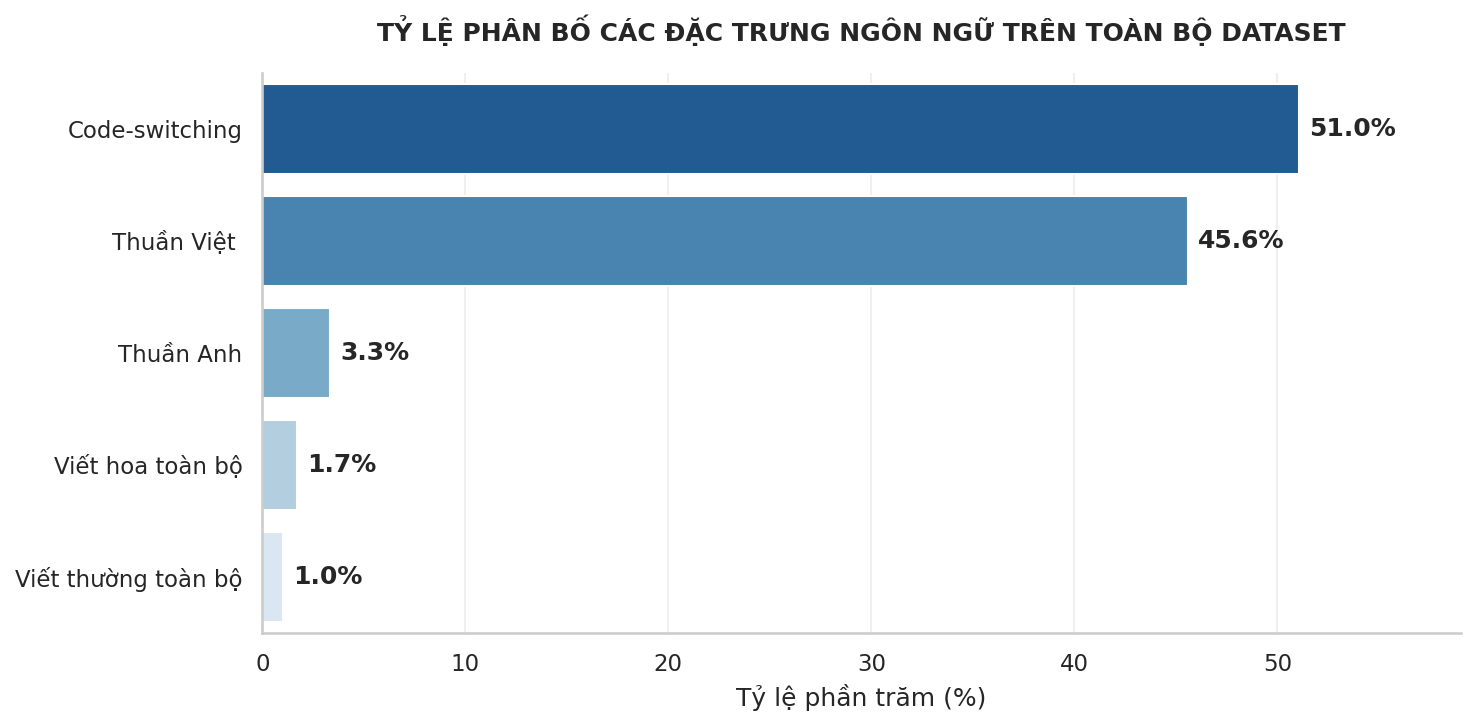

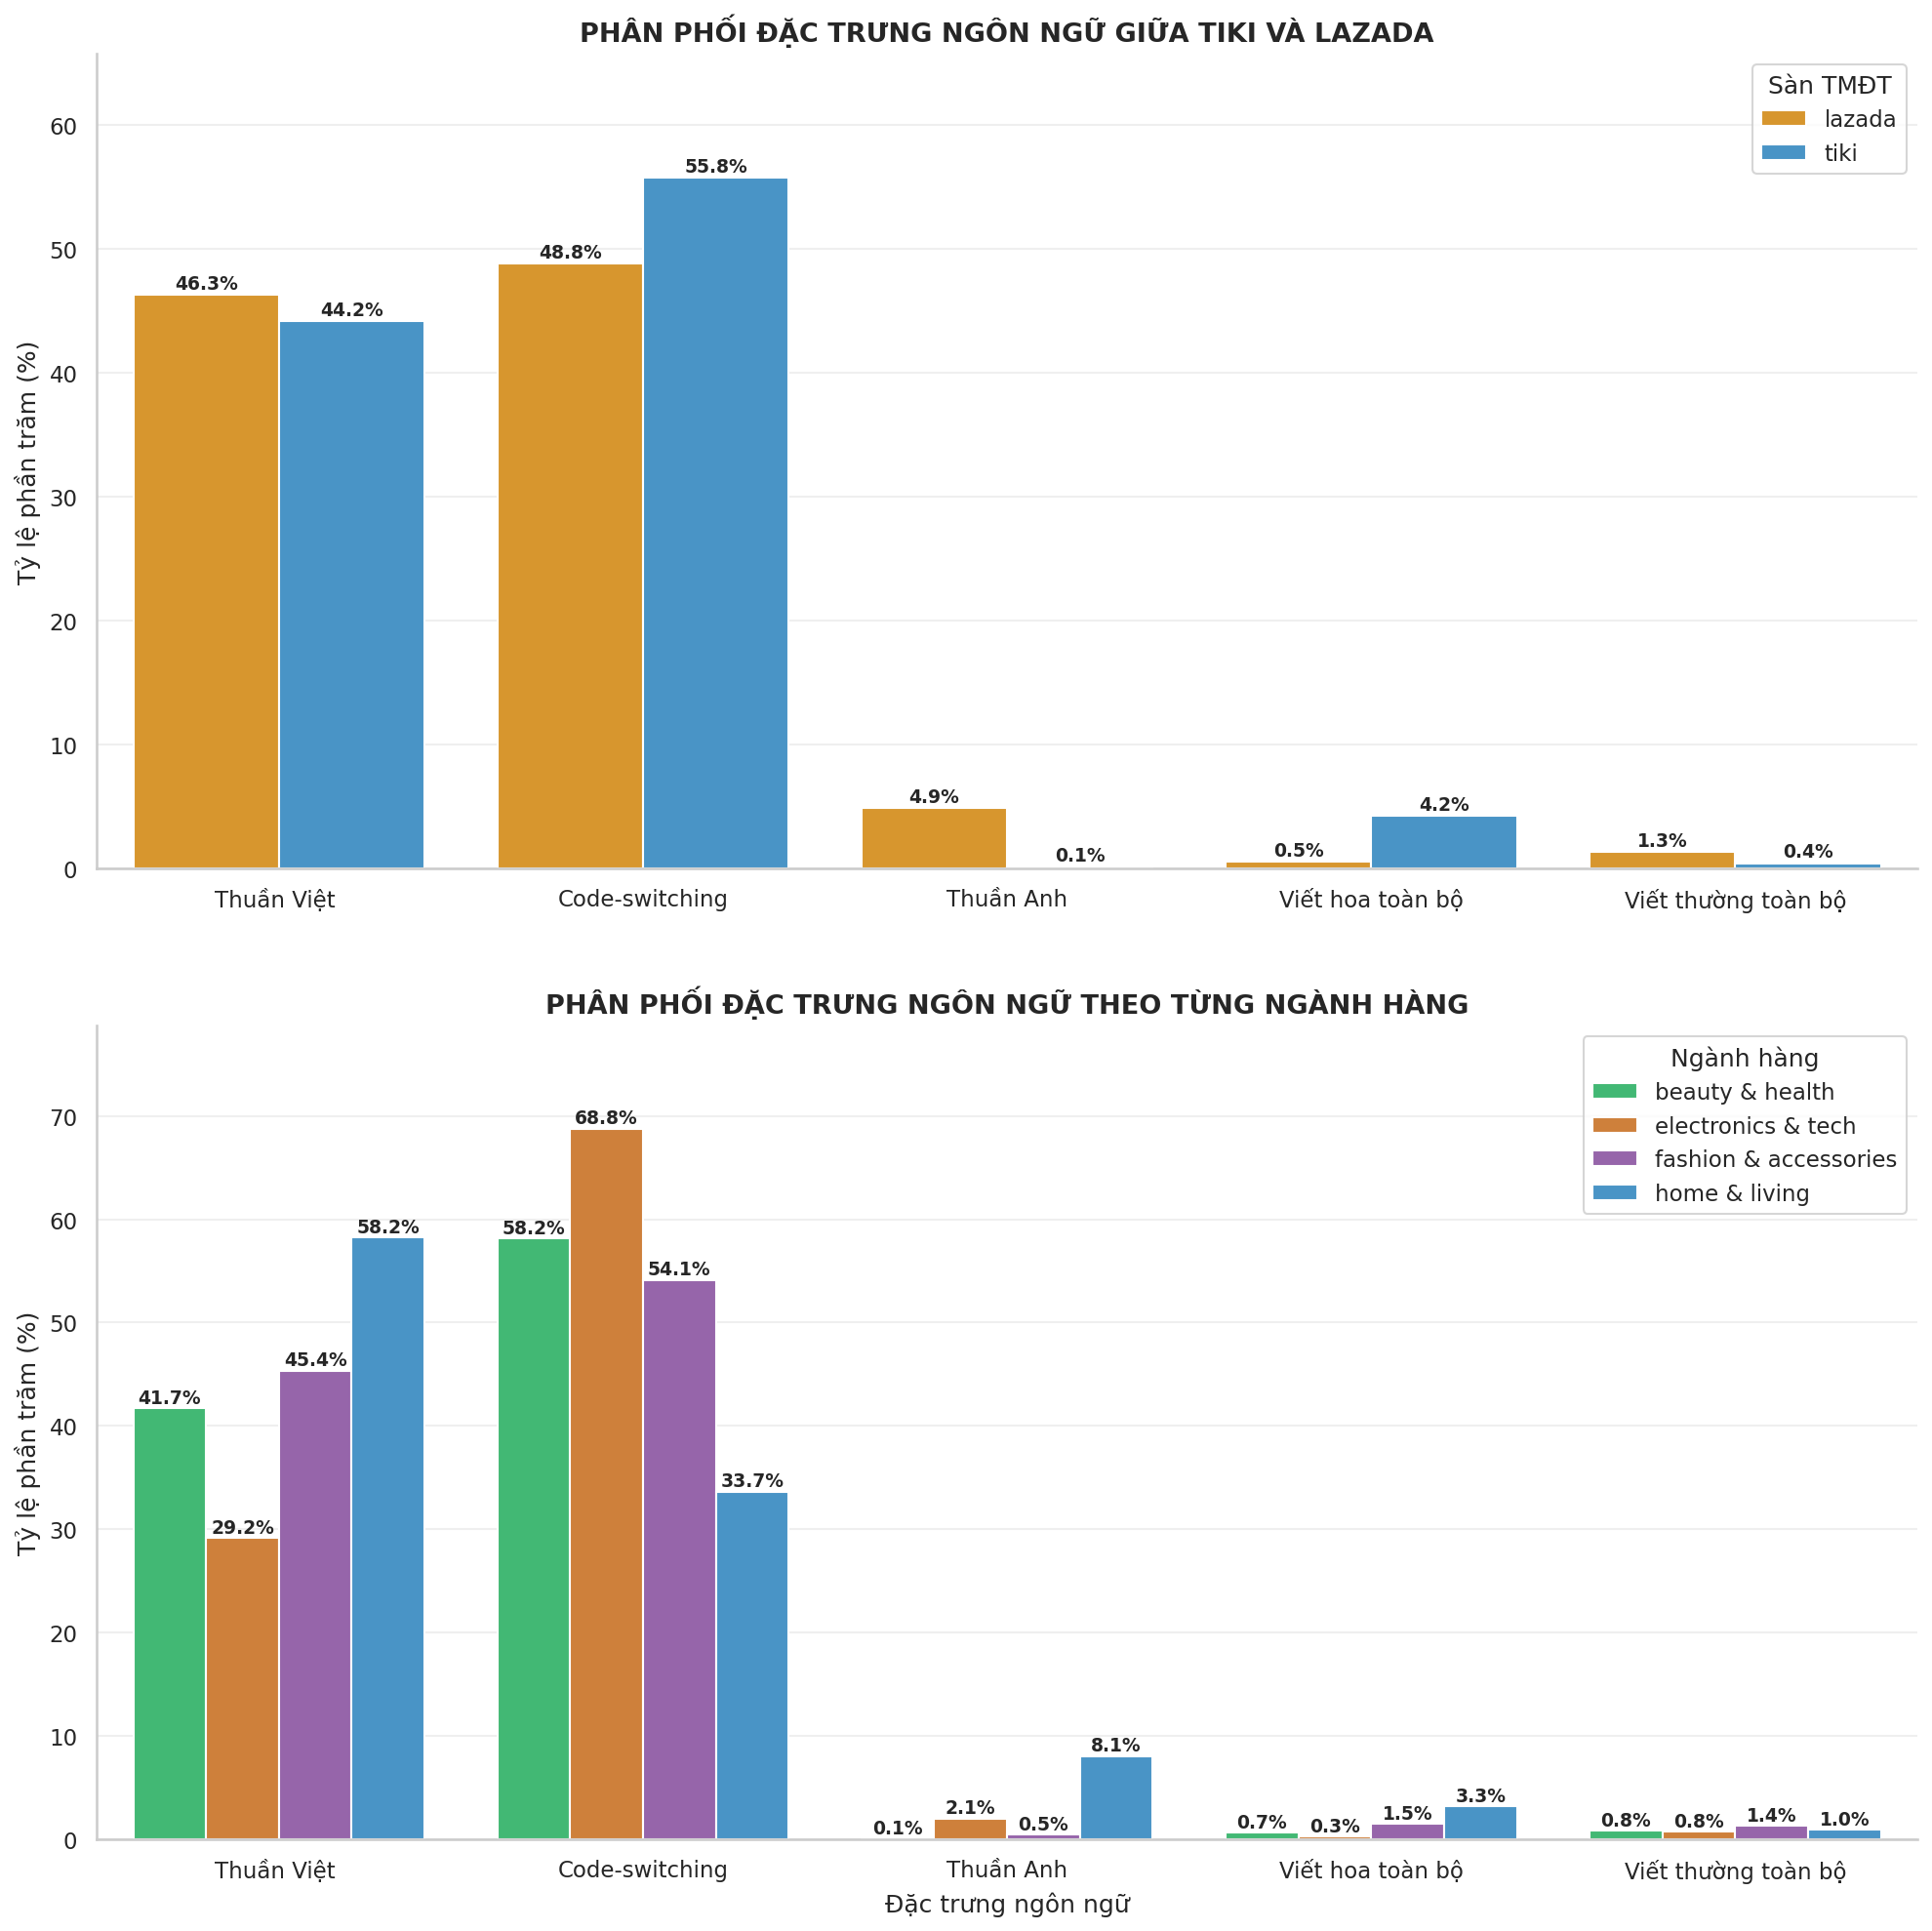

In [87]:
# Xét viết hoa/thường
# Lọc chỉ lấy chữ cái để xét (tránh việc có số/ký tự đặc biệt làm sai lệch hàm islower/isupper)
letters_only = df['title_clean'].astype(str).str.replace(r'[^a-zA-Zà-ỹÀ-Ỹ]', '', regex=True)
df['is_lower'] = (letters_only != '') & letters_only.str.islower()
df['is_upper'] = (letters_only != '') & letters_only.str.isupper()


df['is_pure_vn'] = df['lang_profile'] == 'Thuần Việt'
df['is_pure_en'] = df['lang_profile'] == 'Thuần Anh'
# Gom "Trộn lẫn (Thiên Việt)" và "Trộn lẫn (Thiên Anh)" thành Code-switching
df['is_code_switching'] = df['lang_profile'].str.contains('Code-switching', na=False)

# Danh sách các cột cần phân tích và tên hiển thị
lang_cols = ['is_pure_vn', 'is_code_switching', 'is_pure_en', 'is_upper', 'is_lower']
lang_names = {
    'is_pure_vn': 'Thuần Việt ',
    'is_code_switching': 'Code-switching',
    'is_pure_en': 'Thuần Anh',
    'is_upper': 'Viết hoa toàn bộ',
    'is_lower': 'Viết thường toàn bộ'
}

# Tính tỷ lệ % cho toàn bộ dataset
overall_stats = []
total_rows = len(df)
for col in lang_cols:
    pct = (df[col].sum() / total_rows) * 100
    overall_stats.append({'Đặc trưng ngôn ngữ': lang_names[col], 'Tỷ lệ (%)': pct})

df_overall = pd.DataFrame(overall_stats).sort_values(by='Tỷ lệ (%)', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_overall, x='Tỷ lệ (%)', y='Đặc trưng ngôn ngữ', palette=PALETTE_MAIN)
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.1f}%', va='center', fontweight='bold')

plt.title('TỶ LỆ PHÂN BỐ CÁC ĐẶC TRƯNG NGÔN NGỮ TRÊN TOÀN BỘ DATASET', fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ phần trăm (%)')
plt.ylabel('')
plt.xlim(0, df_overall['Tỷ lệ (%)'].max() + 8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Theo sàn
platform_lang = df.groupby('platform')[lang_cols].mean() * 100
platform_lang = platform_lang.rename(columns=lang_names).reset_index()
platform_melted = platform_lang.melt(id_vars='platform', var_name='Đặc trưng ngôn ngữ', value_name='Tỷ lệ (%)')

sns.barplot(data=platform_melted, x='Đặc trưng ngôn ngữ', y='Tỷ lệ (%)', hue='platform', ax=axes[0], palette=PLATFORM_PALETTE)
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].text(p.get_x() + p.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('PHÂN PHỐI ĐẶC TRƯNG NGÔN NGỮ GIỮA TIKI VÀ LAZADA', fontweight='bold', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Tỷ lệ phần trăm (%)')
axes[0].set_ylim(0, platform_melted['Tỷ lệ (%)'].max() + 10)
axes[0].legend(title='Sàn TMĐT')

# Theo nhóm ngành
industry_lang = df.groupby('industry_group')[lang_cols].mean() * 100
industry_lang = industry_lang.rename(columns=lang_names).reset_index()
industry_melted = industry_lang.melt(id_vars='industry_group', var_name='Đặc trưng ngôn ngữ', value_name='Tỷ lệ (%)')

sns.barplot(data=industry_melted, x='Đặc trưng ngôn ngữ', y='Tỷ lệ (%)', hue='industry_group', ax=axes[1], palette=PALETTE_IND)
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].text(p.get_x() + p.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', fontsize=9, fontweight='bold', rotation=0) # Có thể đổi rotation=90 nếu bị đè chữ
axes[1].set_title('PHÂN PHỐI ĐẶC TRƯNG NGÔN NGỮ THEO TỪNG NGÀNH HÀNG', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Đặc trưng ngôn ngữ')
axes[1].set_ylabel('Tỷ lệ phần trăm (%)')
axes[1].set_ylim(0, industry_melted['Tỷ lệ (%)'].max() + 10)
axes[1].legend(title='Ngành hàng', loc='upper right')

plt.tight_layout(pad=3.0)
plt.show()

### 3.3 Nhiễu ngữ nghĩa (Semantic-level Noise)

Ngoài nhiễu ký tự và ngôn ngữ, tiêu đề TMĐT còn chứa nhiễu ở cấp độ ngữ nghĩa: **keyword stuffing** (lặp từ cố ý để tối ưu tìm kiếm) và **boilerplate terms** (cụm từ sáo rỗng như 'chính hãng', 'giá rẻ' không mang thông tin phân biệt). Hai loại này không gây lỗi tokenize nhưng có thể làm giảm chất lượng biểu diễn đặc trưng.

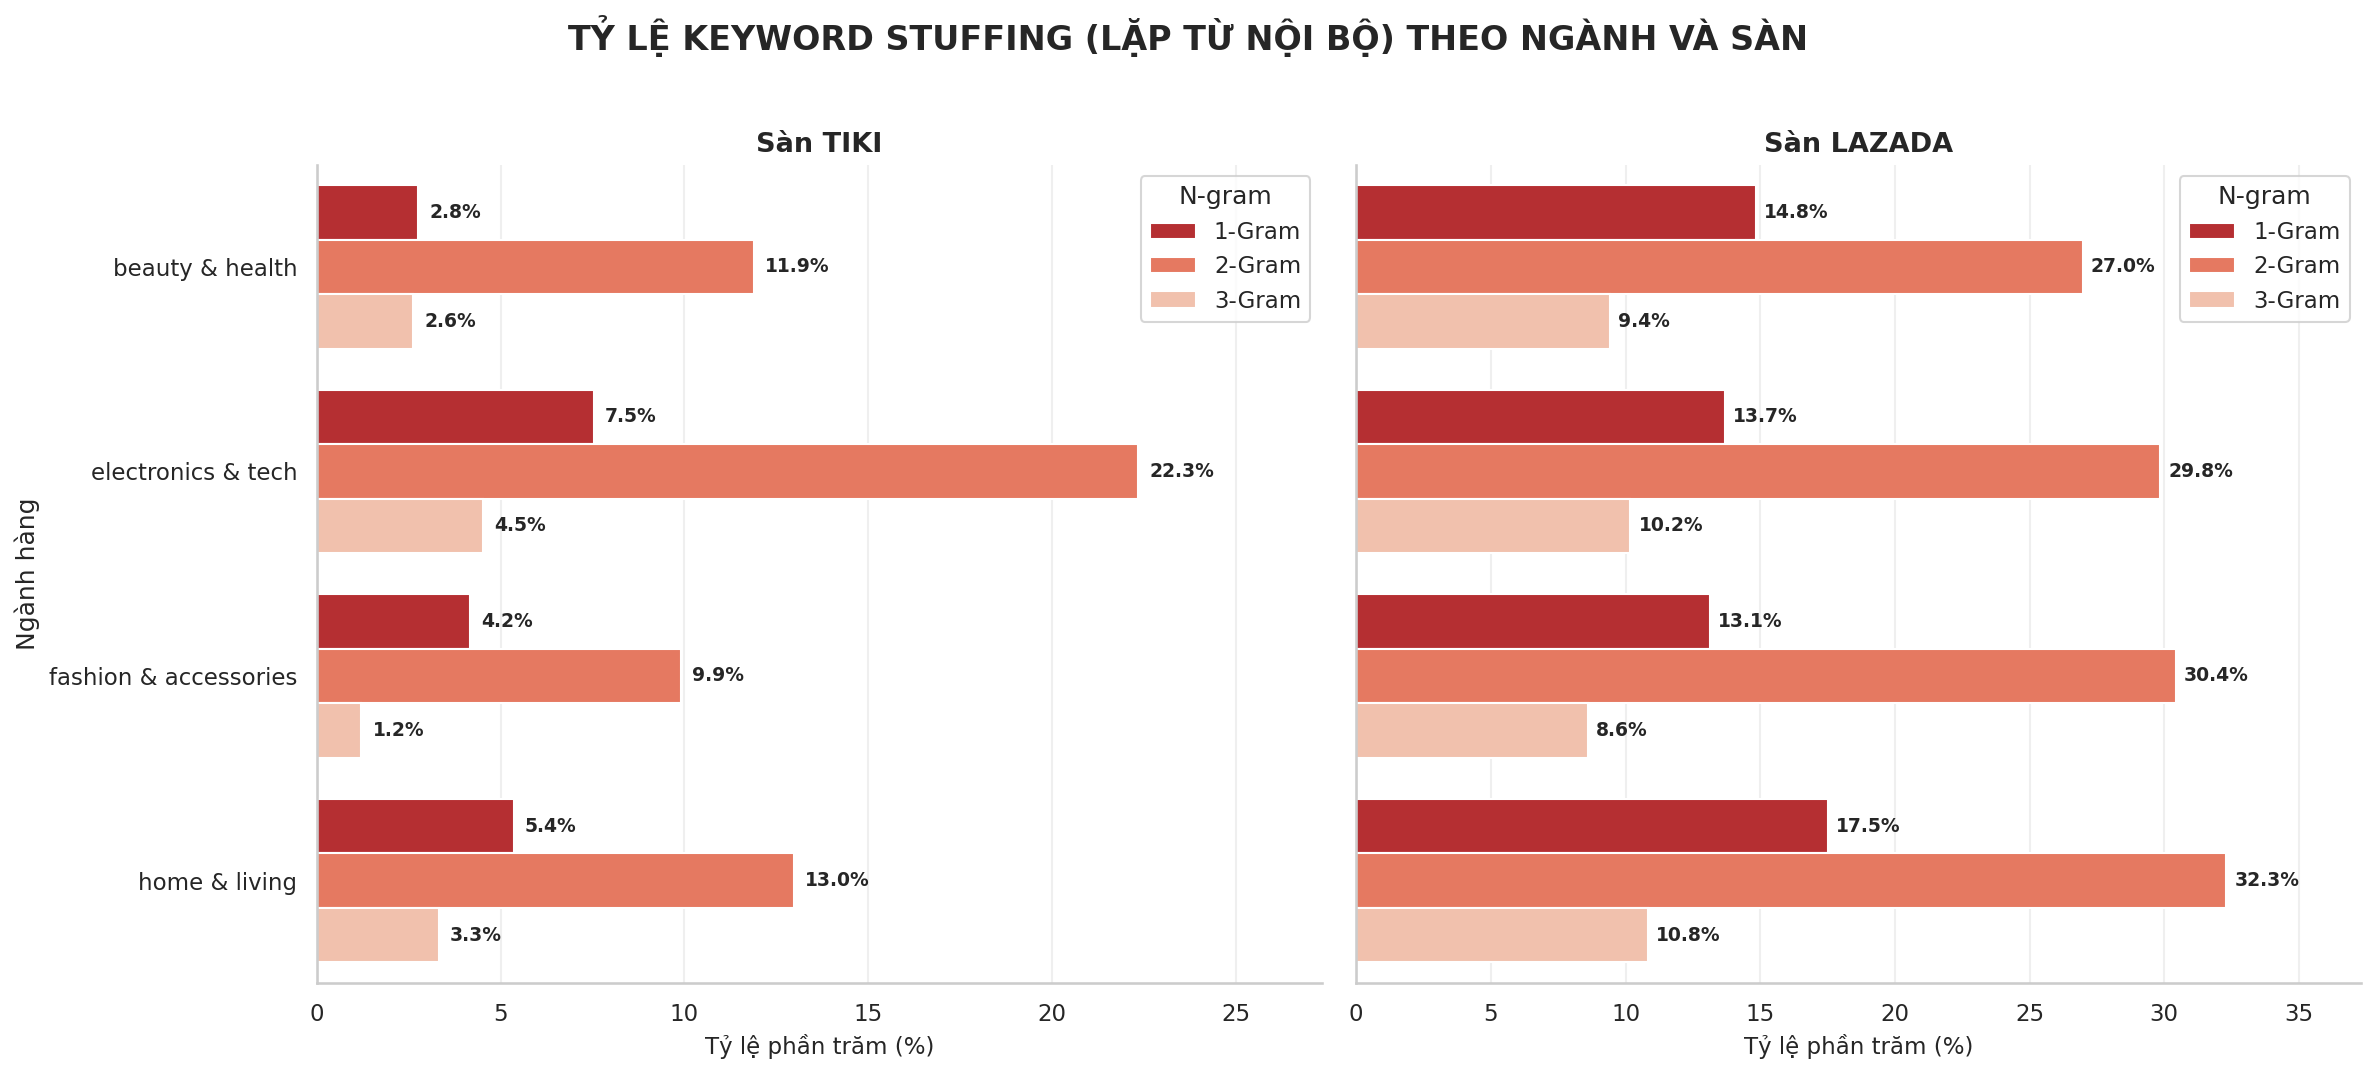

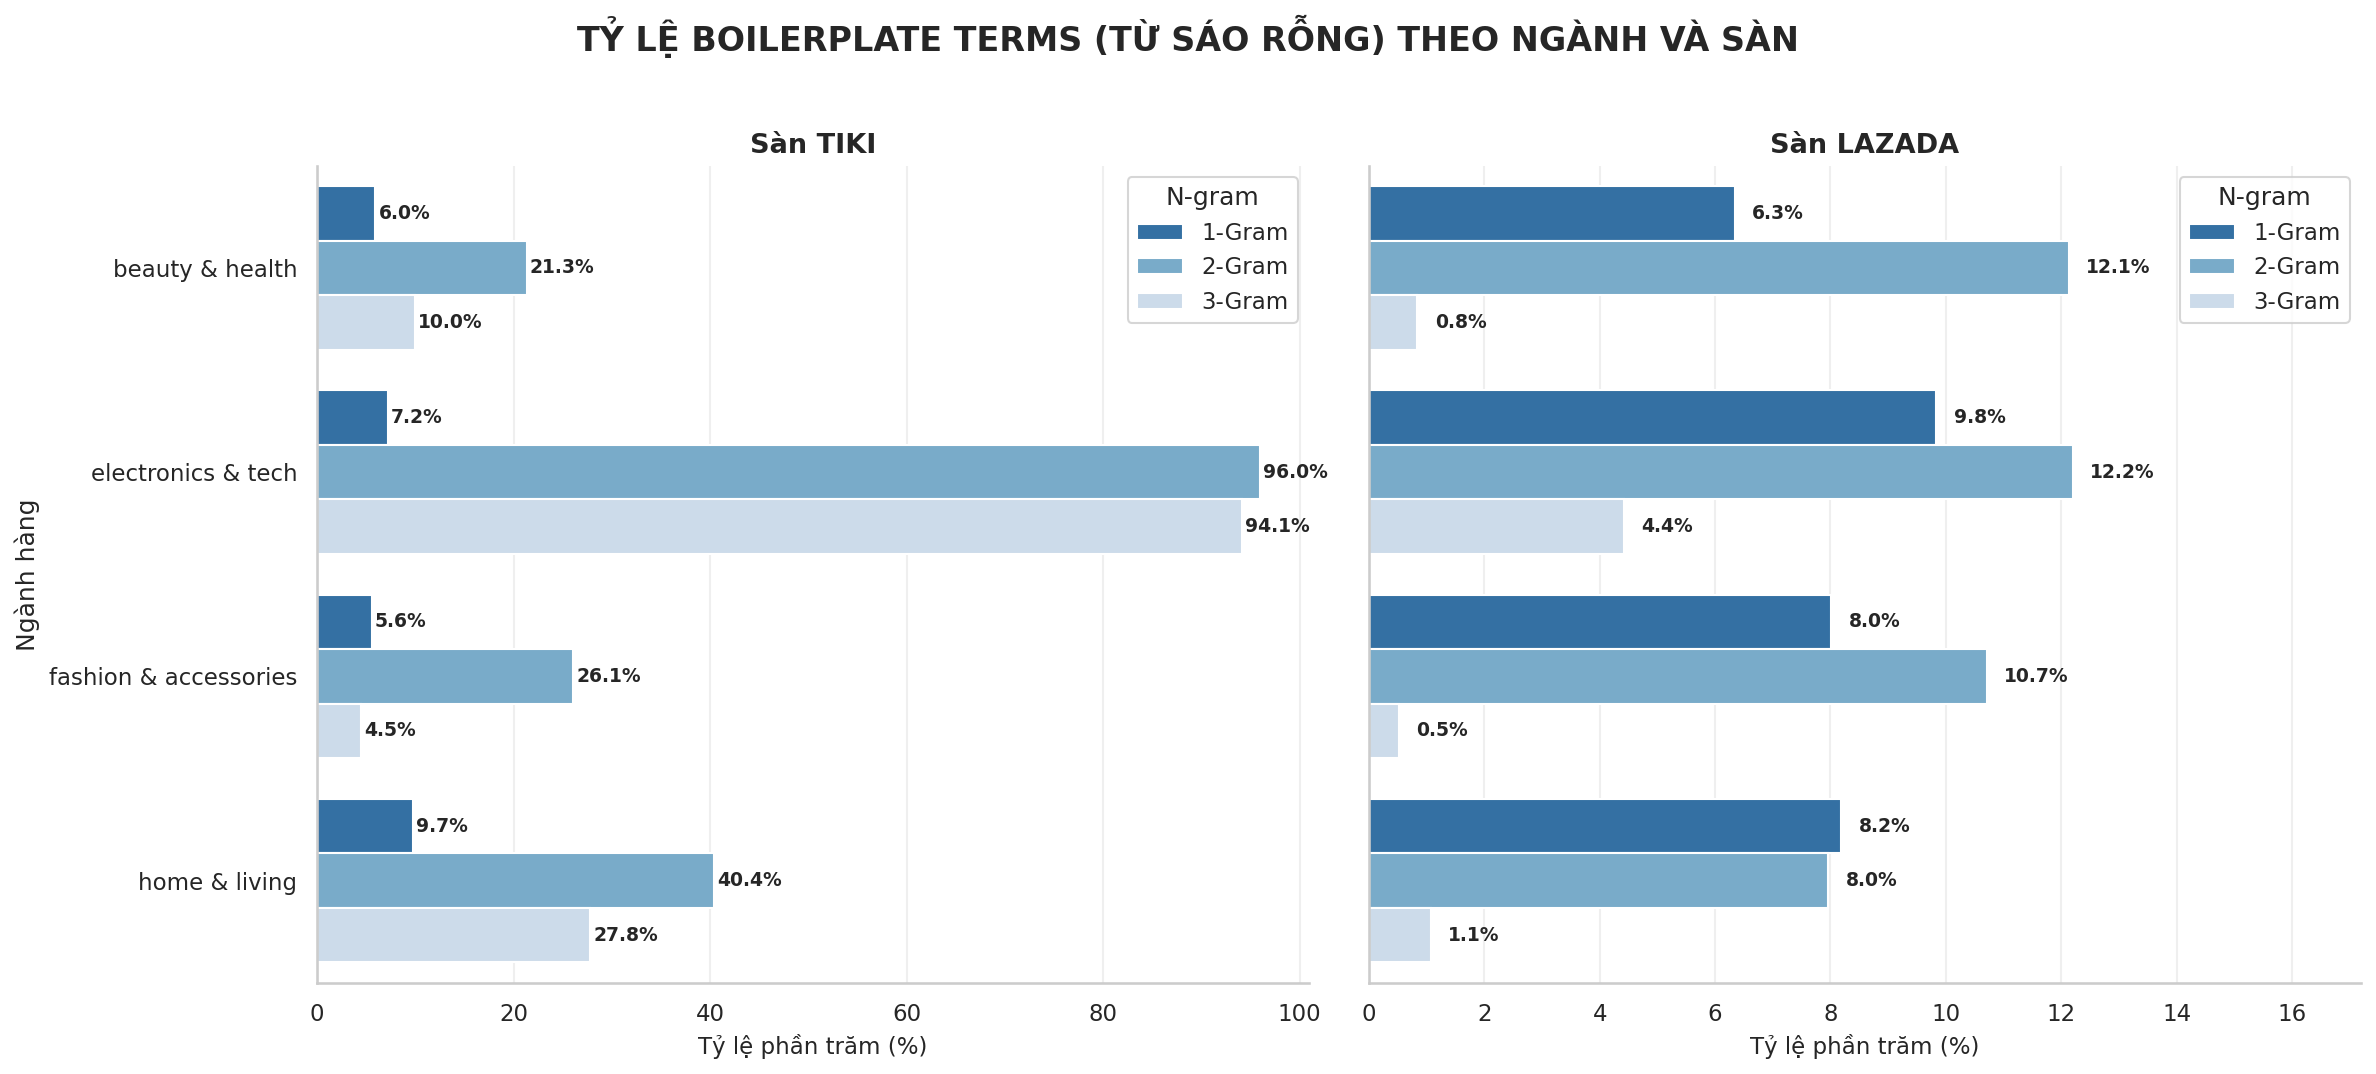

In [88]:
def check_keyword_stuffing(text, n=1):
    words = re.sub(r'[^\w\s]', '', str(text).lower()).split()
    if len(words) < n: return False

    # Tạo các N-grams
    ngrams = [' '.join(words[i:i+n]) for i in range(len(words)-n+1)]
    unique_ngrams = len(set(ngrams))

    # Tính tỷ lệ lặp
    ratio = 1.0 - (unique_ngrams / len(ngrams))

    if n == 1:
        return ratio > 0.20
    else:
        return ratio > 0.0


# Định nghĩa các tập từ sáo rỗng đặc trưng theo độ dài N-gram
boiler_1g = ['hot', 'sale', 'rẻ', 'auth', 'freeship', 'kèm', 'tặng', 'đỉnh', 'chuẩn']
boiler_2g = ['chính hãng', 'cao cấp', 'giá rẻ', 'nhập khẩu', 'miễn phí', 'xả kho', 'giảm giá', 'siêu rẻ', 'thanh lý']
boiler_3g = ['hàng chính hãng', 'giá siêu rẻ', 'tặng kèm quà', 'chất lượng cao', 'miễn phí ship', 'sale sập sàn', 'hàng nhập khẩu']

def check_boilerplate(text, n=1):
    text_lower = f" {str(text).lower()} " # Bọc khoảng trắng để bắt từ đơn chính xác
    if n == 1:
        return any(f" {w} " in text_lower for w in boiler_1g)
    elif n == 2:
        return any(w in text_lower for w in boiler_2g)
    else:
        return any(w in text_lower for w in boiler_3g)


text_col = 'title_clean' if 'title_clean' in df.columns else 'title'

# Tính Keyword Stuffing
df['stuffing_1g'] = df[text_col].apply(lambda x: check_keyword_stuffing(x, 1))
df['stuffing_2g'] = df[text_col].apply(lambda x: check_keyword_stuffing(x, 2))
df['stuffing_3g'] = df[text_col].apply(lambda x: check_keyword_stuffing(x, 3))

# Tính Boilerplate Terms
df['boiler_1g'] = df[text_col].apply(lambda x: check_boilerplate(x, 1))
df['boiler_2g'] = df[text_col].apply(lambda x: check_boilerplate(x, 2))
df['boiler_3g'] = df[text_col].apply(lambda x: check_boilerplate(x, 3))


cols_stuffing = ['stuffing_1g', 'stuffing_2g', 'stuffing_3g']
cols_boiler = ['boiler_1g', 'boiler_2g', 'boiler_3g']

# Tính trung bình (tỷ lệ %) theo Sàn và Ngành
grouped_stats = df.groupby(['platform', 'industry_group'])[cols_stuffing + cols_boiler].mean() * 100
grouped_stats = grouped_stats.reset_index()

# Bẻ bảng (Melt) cho Keyword Stuffing
melt_stuffing = grouped_stats.melt(id_vars=['platform', 'industry_group'], value_vars=cols_stuffing,
                                   var_name='N-gram', value_name='Tỷ lệ (%)')
melt_stuffing['N-gram'] = melt_stuffing['N-gram'].map({'stuffing_1g': '1-Gram', 'stuffing_2g': '2-Gram', 'stuffing_3g': '3-Gram'})

# Bẻ bảng (Melt) cho Boilerplate
melt_boiler = grouped_stats.melt(id_vars=['platform', 'industry_group'], value_vars=cols_boiler,
                                 var_name='N-gram', value_name='Tỷ lệ (%)')
melt_boiler['N-gram'] = melt_boiler['N-gram'].map({'boiler_1g': '1-Gram', 'boiler_2g': '2-Gram', 'boiler_3g': '3-Gram'})


def plot_semantic_noise(melt_df, title, palette):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=False, sharey=True)

    for i, plat in enumerate(['tiki', 'lazada']):
        data_plat = melt_df[melt_df['platform'] == plat]
        ax = sns.barplot(data=data_plat, y='industry_group', x='Tỷ lệ (%)', hue='N-gram',
                         ax=axes[i], palette=palette)

        # Format biểu đồ
        axes[i].set_title(f'Sàn {plat.upper()}', fontweight='bold', fontsize=13)
        axes[i].set_ylabel('' if i > 0 else 'Ngành hàng', fontsize=12)
        axes[i].set_xlabel('Tỷ lệ phần trăm (%)', fontsize=11)

        # Ghi chú % lên thanh bar
        for p in ax.patches:
            width = p.get_width()
            if width > 0:
                ax.text(width + 0.3, p.get_y() + p.get_height()/2, f'{width:.1f}%',
                        va='center', fontsize=9, fontweight='bold')

        axes[i].set_xlim(0, data_plat['Tỷ lệ (%)'].max() + 5)

    plt.suptitle(title, fontweight='bold', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Thực thi vẽ 2 biểu đồ
plot_semantic_noise(melt_stuffing, 'TỶ LỆ KEYWORD STUFFING (LẶP TỪ NỘI BỘ) THEO NGÀNH VÀ SÀN', 'Reds_r')
plot_semantic_noise(melt_boiler, 'TỶ LỆ BOILERPLATE TERMS (TỪ SÁO RỖNG) THEO NGÀNH VÀ SÀN', 'Blues_r')

**Insight — Nhiễu ngữ nghĩa:**
- **Keyword stuffing 2-gram** xuất hiện ở tỷ lệ đáng chú ý — seller có xu hướng lặp từ khóa để tăng thứ hạng tìm kiếm nội sàn.
- **Boilerplate 2-gram** ('chính hãng', 'giá rẻ', 'cao cấp') phổ biến hơn 3-gram — cho thấy cụm 2 từ là đơn vị SEO tự nhiên trong TMĐT tiếng Việt.
- **Quyết định pipeline:** Ghi nhận và đo lường, **không tự động xóa** — vì 'chính hãng' hay 'nhập khẩu' có thể là entity cần nhận dạng trong NER. Thông tin này được tham chiếu khi thiết kế annotation guideline.

## 4. Phân tích trùng lặp (Duplicate Analysis)

> **Câu hỏi:** Có bao nhiêu tiêu đề bị trùng lặp? Trùng lặp xảy ra chủ yếu trong cùng sàn hay chéo sàn?

Trùng lặp trong dữ liệu huấn luyện NER gây ra hai vấn đề nghiêm trọng: **(1) data leakage** nếu cùng tiêu đề xuất hiện ở train và test set, và **(2) thiên lệch phân phối** khiến mô hình overfit các pattern phổ biến. Chúng tôi phân tích 3 loại trùng lặp theo mức độ tăng dần.

=== 1. EXACT DUPLICATES (Trùng lặp 100%) ===
Số lượng dòng bị trùng lặp chính xác: 662 (3.42%)

BẢNG TỶ LỆ TRÙNG LẶP EXACT DUPLICATE THEO NGÀNH × SÀN:


platform,lazada,tiki
industry_group,,
beauty & health,2.38,1.16
electronics & tech,7.51,0.72
fashion & accessories,2.60,2.49
home & living,5.62,0.92


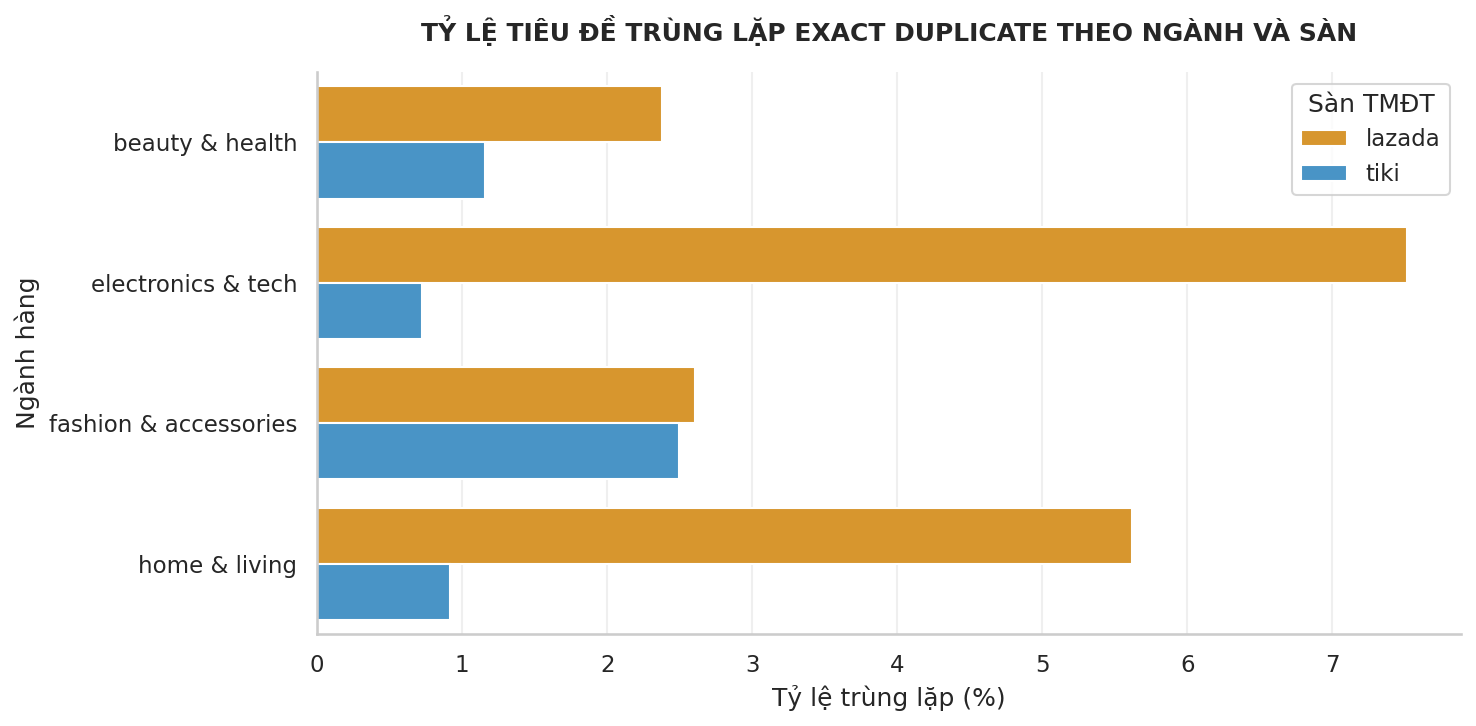


=== 2. NEAR-DUPLICATES (Trùng lặp gần giống > 95%) ===
Số lượng CẶP tiêu đề là Near-Duplicates (>95%): 229
Ước tính tổng tỷ lệ dữ liệu bị trùng lặp (Exact + Near): ~5.78%

=== 3. TRÙNG LẶP CROSS-PLATFORM ===
Số lượng tiêu đề sản phẩm xuất hiện trên CẢ 2 SÀN: 4
Tỷ lệ Overlap so với tổng số lượng tiêu đề Unique: 0.02%


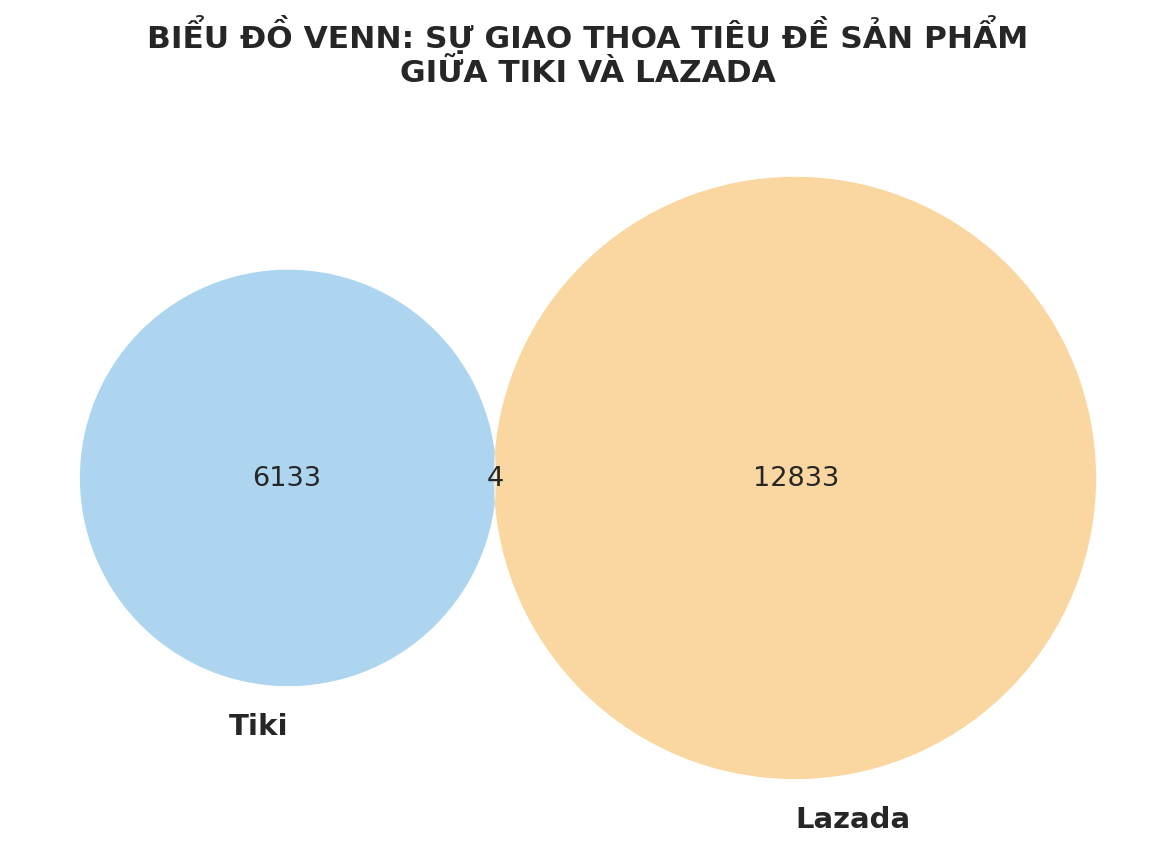


Ví dụ các sản phẩm được bán trên cả 2 sàn (Cross-platform):


,Tiêu đề Cross-platform
0,Dây Đai Half Belt Thắt Lưng Dây Nịt Quần Thun ...
1,Gel rửa mặt cho da dầu nhạy cảm La Roche-Posay...
2,"Tinh chất vitamin C dưỡng trắng, mờ thâm cao c..."
3,"Bao da dành cho iPad A16 Gen 11 2025 , Gen 10 ..."


In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib_venn import venn2

# 1. Tỉ lệ trùng hoàn toàn
# Tìm các tiêu đề xuất hiện nhiều hơn 1 lần
text_col = 'title_clean' if 'title_clean' in df.columns else 'title'

exact_dupes = df[df.duplicated(subset=[text_col], keep=False)]
num_exact_dupes = len(exact_dupes)
exact_dupe_ratio = (num_exact_dupes / len(df)) * 100

print(f"=== 1. EXACT DUPLICATES (Trùng lặp 100%) ===")
print(f"Số lượng dòng bị trùng lặp chính xác: {num_exact_dupes} ({exact_dupe_ratio:.2f}%)")

# Phân tích Exact Duplicates theo Ngành và Sàn
dupe_stats = exact_dupes.groupby(['industry_group', 'platform']).size().reset_index(name='dupe_count')
total_stats = df.groupby(['industry_group', 'platform']).size().reset_index(name='total_count')

# Merge để tính tỷ lệ %
merged_stats = pd.merge(dupe_stats, total_stats, on=['industry_group', 'platform'], how='right').fillna(0)
merged_stats['pct_duplicate'] = (merged_stats['dupe_count'] / merged_stats['total_count']) * 100

print("\nBẢNG TỶ LỆ TRÙNG LẶP EXACT DUPLICATE THEO NGÀNH × SÀN:")
display(merged_stats.pivot(index='industry_group', columns='platform', values='pct_duplicate').round(2).fillna(0))

# Vẽ Bar Chart: % Duplicate theo Ngành
plt.figure(figsize=(10, 5))
sns.barplot(data=merged_stats, x='pct_duplicate', y='industry_group', hue='platform', palette=PLATFORM_PALETTE)
plt.title('TỶ LỆ TIÊU ĐỀ TRÙNG LẶP EXACT DUPLICATE THEO NGÀNH VÀ SÀN', fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ trùng lặp (%)')
plt.ylabel('Ngành hàng')
plt.legend(title='Sàn TMĐT')
plt.tight_layout()
plt.show()


# 2. Tỉ lệ trùng lặp gần (Cosine Similarity > 0.95)
print("\n=== 2. NEAR-DUPLICATES (Trùng lặp gần giống > 95%) ===")

unique_titles_df = df.drop_duplicates(subset=[text_col]).dropna(subset=[text_col])
corpus = unique_titles_df[text_col].tolist()

# Dùng TF-IDF để vector hóa văn bản
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(corpus)

# Lấy các cặp có độ tương đồng > 0.95 (không tính đường chéo chính)
# Dùng dot product trên ma trận thưa (sparse) cho nhanh
similarity_matrix = tfidf_matrix * tfidf_matrix.T
# Lọc phần tam giác trên (upper triangle) để không bị đếm ngược (A-B và B-A)
similarity_matrix = similarity_matrix.tocoo()

near_dupes_count = 0
for i, j, v in zip(similarity_matrix.row, similarity_matrix.col, similarity_matrix.data):
    if i < j and v > 0.95:
        near_dupes_count += 1

# Tính tổng (Exact Dupes + Near Dupes)
# Lưu ý: Near dupes count ở đây là số "Cặp" (Pairs). Để quy đổi ra số dòng tương đối:
estimated_near_dupe_rows = near_dupes_count * 2
total_dupe_ratio = ((num_exact_dupes + estimated_near_dupe_rows) / len(df)) * 100

print(f"Số lượng CẶP tiêu đề là Near-Duplicates (>95%): {near_dupes_count}")
print(f"Ước tính tổng tỷ lệ dữ liệu bị trùng lặp (Exact + Near): ~{total_dupe_ratio:.2f}%")

# 3. Tỉ lệ trùng lặp chéo sàn
print("\n=== 3. TRÙNG LẶP CROSS-PLATFORM ===")

tiki_titles = set(df[df['platform'] == 'tiki'][text_col].dropna())
lazada_titles = set(df[df['platform'] == 'lazada'][text_col].dropna())

# Tìm tập giao (xuất hiện trên cả 2 sàn)
cross_platform_dupes = tiki_titles.intersection(lazada_titles)
overlap_count = len(cross_platform_dupes)

print(f"Số lượng tiêu đề sản phẩm xuất hiện trên CẢ 2 SÀN: {overlap_count}")
print(f"Tỷ lệ Overlap so với tổng số lượng tiêu đề Unique: {(overlap_count / len(tiki_titles.union(lazada_titles))) * 100:.2f}%")

# Vẽ Biểu đồ Venn
plt.figure(figsize=(8, 6))
v = venn2([tiki_titles, lazada_titles], set_labels=('Tiki', 'Lazada'), set_colors=('#3498db', '#f39c12'))

for text in v.set_labels:
    text.set_fontsize(14)
    text.set_fontweight('bold')
for text in v.subset_labels:
    if text:
        text.set_fontsize(13)

plt.title('BIỂU ĐỒ VENN: SỰ GIAO THOA TIÊU ĐỀ SẢN PHẨM\nGIỮA TIKI VÀ LAZADA', fontweight='bold', fontsize=15, pad=15)
plt.tight_layout()
plt.show()

# Xuất thử vài mẫu Cross-platform
if overlap_count > 0:
    print("\nVí dụ các sản phẩm được bán trên cả 2 sàn (Cross-platform):")
    display(pd.DataFrame({"Tiêu đề Cross-platform": list(cross_platform_dupes)[:5]}))

**Insight — Trùng lặp dữ liệu:**
- **Exact duplicates** tập trung cao ở nhóm **Electronics & Tech và Home & Living** (đặt biệt là trên sàn Lazada) thường được đăng với tiêu đề giống hệt nhau trên nhiều listing.
- **Near-duplicates (>95% cosine)** cho thấy một lượng đáng kể tiêu đề chỉ khác nhau ở vài ký tự (model, màu sắc, size, ...) — cần xử lý để tránh data leakage.
- **Cross-platform overlap** (Venn diagram): phần giao giữa Tiki và Lazada tuy nhỏ nhưng đáng kể — chứng tỏ có seller đăng sản phẩm đồng thời trên cả hai sàn.
- **Quyết định pipeline:** Exact dedup trước, sau đó near-dedup bằng TF-IDF char N-gram (ngưỡng cosine 0.90) trên toàn dataset (cả cùng sàn lẫn chéo sàn).

In [90]:
# Xóa trùng lặp dựa trên title_clean (tách ra để không ảnh hưởng df gốc)
df_nodup = df.drop_duplicates(subset=['title_clean'], keep='first').reset_index(drop=True)

print(f"Số lượng dòng gốc: {len(df)}")
print(f"Số lượng dòng sau khi xóa trùng: {len(df_nodup)}")
print(f"Số dòng bị xóa: {len(df) - len(df_nodup)}")

Số lượng dòng gốc: 19361
Số lượng dòng sau khi xóa trùng: 18970
Số dòng bị xóa: 391


## 5. Phân tích độ dài tiêu đề (Title Length Analysis)

> **Câu hỏi:** Phân phối độ dài tiêu đề có khác nhau giữa các ngành? Có tiêu đề quá ngắn hoặc quá dài bất thường không?

Độ dài tiêu đề ảnh hưởng trực tiếp đến chất lượng NER — tiêu đề quá ngắn thiếu ngữ cảnh, tiêu đề quá dài có thể chứa nội dung lặp hoặc không liên quan. Phân tích này giúp xác định ngưỡng lọc outlier hợp lý.

=== THỐNG KÊ ĐỘ DÀI TIÊU ĐỀ THEO NGÀNH HÀNG ===


,Min_Words,Max_Words,Mean_Words,Median_Words,Min_Chars,Max_Chars,Mean_Chars,Median_Chars
industry_group,,,,,,,,
beauty & health,3,57,19.84,19.0,11,255,92.56,89.0
electronics & tech,2,68,20.85,20.0,9,255,98.68,95.0
fashion & accessories,3,60,20.00,20.0,11,252,89.98,89.0
home & living,2,60,18.84,18.0,7,254,87.95,86.0


- Phát hiện 0 tiêu đề cực ngắn (<= 1 từ).
- Phát hiện 249 tiêu đề quá dài (> 200 ký tự).


/tmp/ipykernel_1123/125771537.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='industry_group', x='word_count', palette=PALETTE_IND, ax=axes[1, 0])
/tmp/ipykernel_1123/125771537.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='industry_group', x='char_count', palette=PALETTE_IND, ax=axes[1, 1])


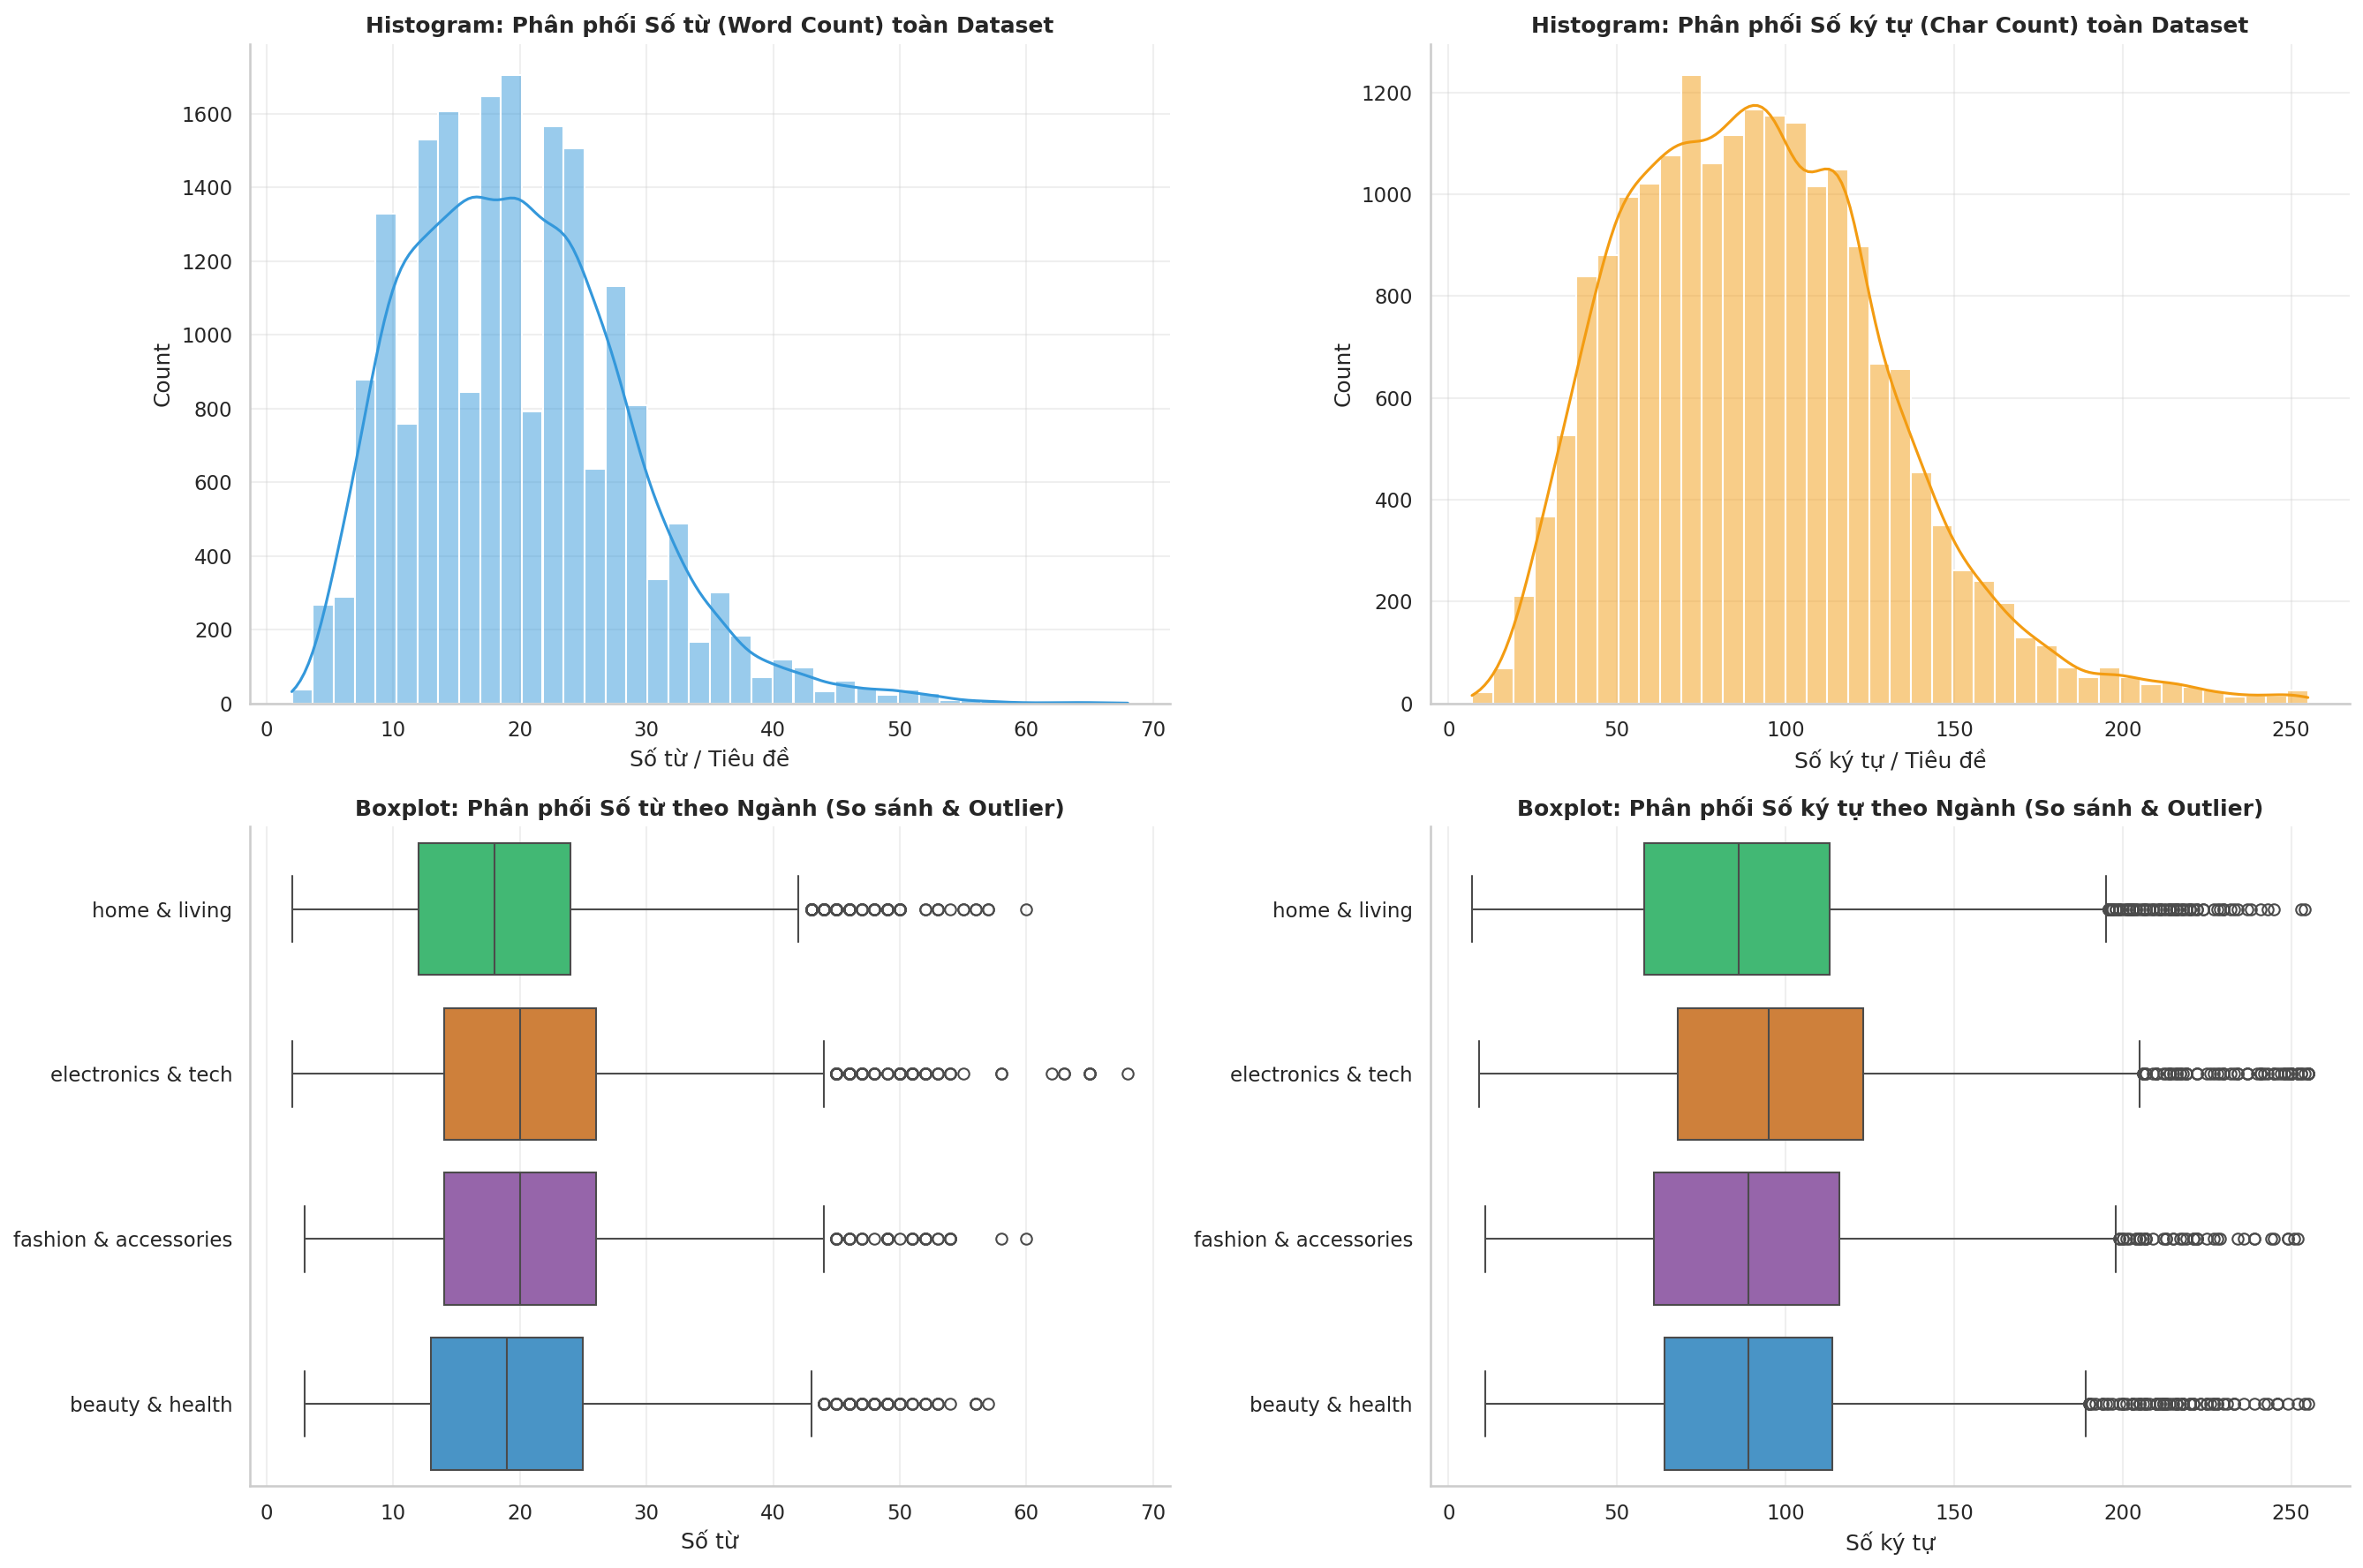

In [91]:
text_col = 'title_clean' if 'title_clean' in df.columns else 'title'

# 1. Tính toán Word Count và Char Count
df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))
df['char_count'] = df[text_col].astype(str).apply(len)

# 2. Bảng thống kê Min / Max / Mean / Median theo ngành
length_stats = df.groupby('industry_group').agg(
    Min_Words=('word_count', 'min'),
    Max_Words=('word_count', 'max'),
    Mean_Words=('word_count', 'mean'),
    Median_Words=('word_count', 'median'),
    Min_Chars=('char_count', 'min'),
    Max_Chars=('char_count', 'max'),
    Mean_Chars=('char_count', 'mean'),
    Median_Chars=('char_count', 'median')
).round(2)

print("=== THỐNG KÊ ĐỘ DÀI TIÊU ĐỀ THEO NGÀNH HÀNG ===")
display(length_stats)

# Đếm Outlier
outliers_word = len(df[df['word_count'] <= 1])
outliers_char = len(df[df['char_count'] > 200])
print(f"- Phát hiện {outliers_word} tiêu đề cực ngắn (<= 1 từ).")
print(f"- Phát hiện {outliers_char} tiêu đề quá dài (> 200 ký tự).")

# 3. Vẽ biểu đồ (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Histogram: Phân phối tổng Dataset
sns.histplot(data=df, x='word_count', bins=40, kde=True, color='#3498db', ax=axes[0, 0])
axes[0, 0].set_title('Histogram: Phân phối Số từ (Word Count) toàn Dataset', fontweight='bold')
axes[0, 0].set_xlabel('Số từ / Tiêu đề')

sns.histplot(data=df, x='char_count', bins=40, kde=True, color='#f39c12', ax=axes[0, 1])
axes[0, 1].set_title('Histogram: Phân phối Số ký tự (Char Count) toàn Dataset', fontweight='bold')
axes[0, 1].set_xlabel('Số ký tự / Tiêu đề')

# Boxplot: Phân phối theo ngành để xem Outlier
sns.boxplot(data=df, y='industry_group', x='word_count', palette=PALETTE_IND, ax=axes[1, 0])
axes[1, 0].set_title('Boxplot: Phân phối Số từ theo Ngành (So sánh & Outlier)', fontweight='bold')
axes[1, 0].set_ylabel('')
axes[1, 0].set_xlabel('Số từ')

sns.boxplot(data=df, y='industry_group', x='char_count', palette=PALETTE_IND, ax=axes[1, 1])
axes[1, 1].set_title('Boxplot: Phân phối Số ký tự theo Ngành (So sánh & Outlier)', fontweight='bold')
axes[1, 1].set_ylabel('')
axes[1, 1].set_xlabel('Số ký tự')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1123/2685696671.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freq, x='Tần suất', y='Từ khóa', ax=axes_bar[i], palette='viridis', legend=False)
/tmp/ipykernel_1123/2685696671.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freq, x='Tần suất', y='Từ khóa', ax=axes_bar[i], palette='viridis', legend=False)
/tmp/ipykernel_1123/2685696671.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freq, x='Tần suất', y='Từ khóa', ax=axes_bar[i], palette='viridis', legend=False)
/tmp/ipykernel_1123/26856

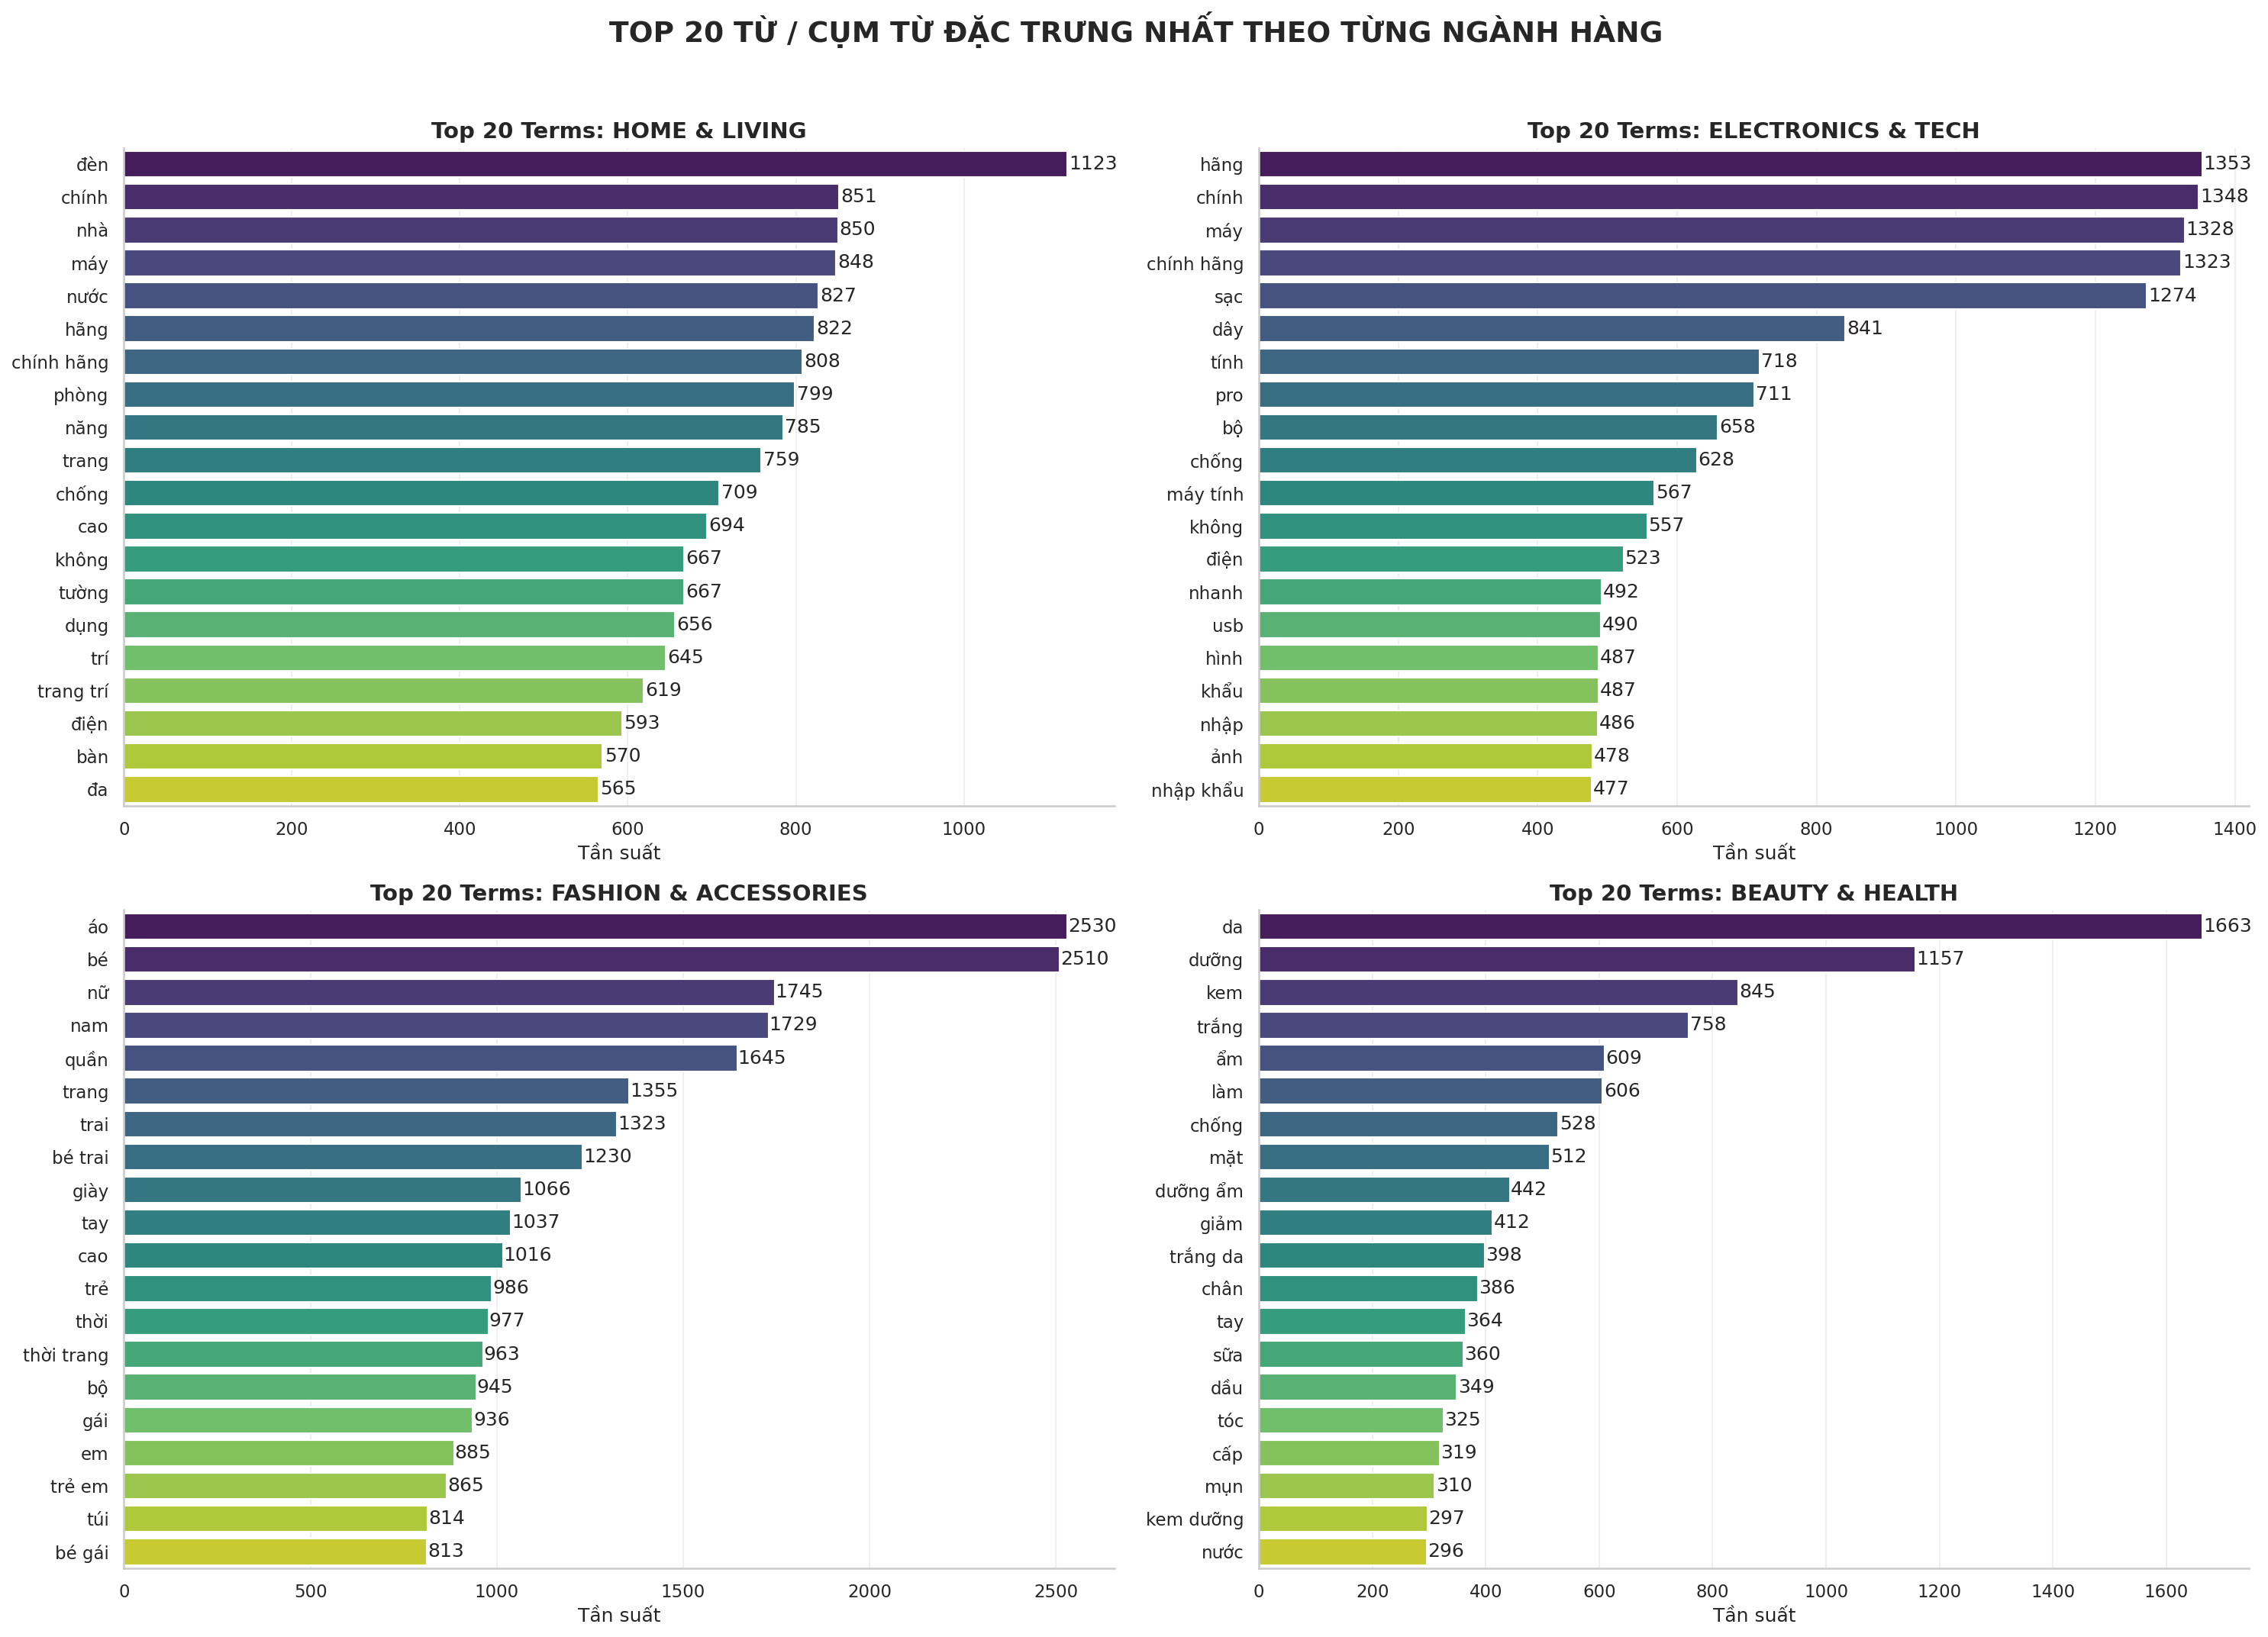

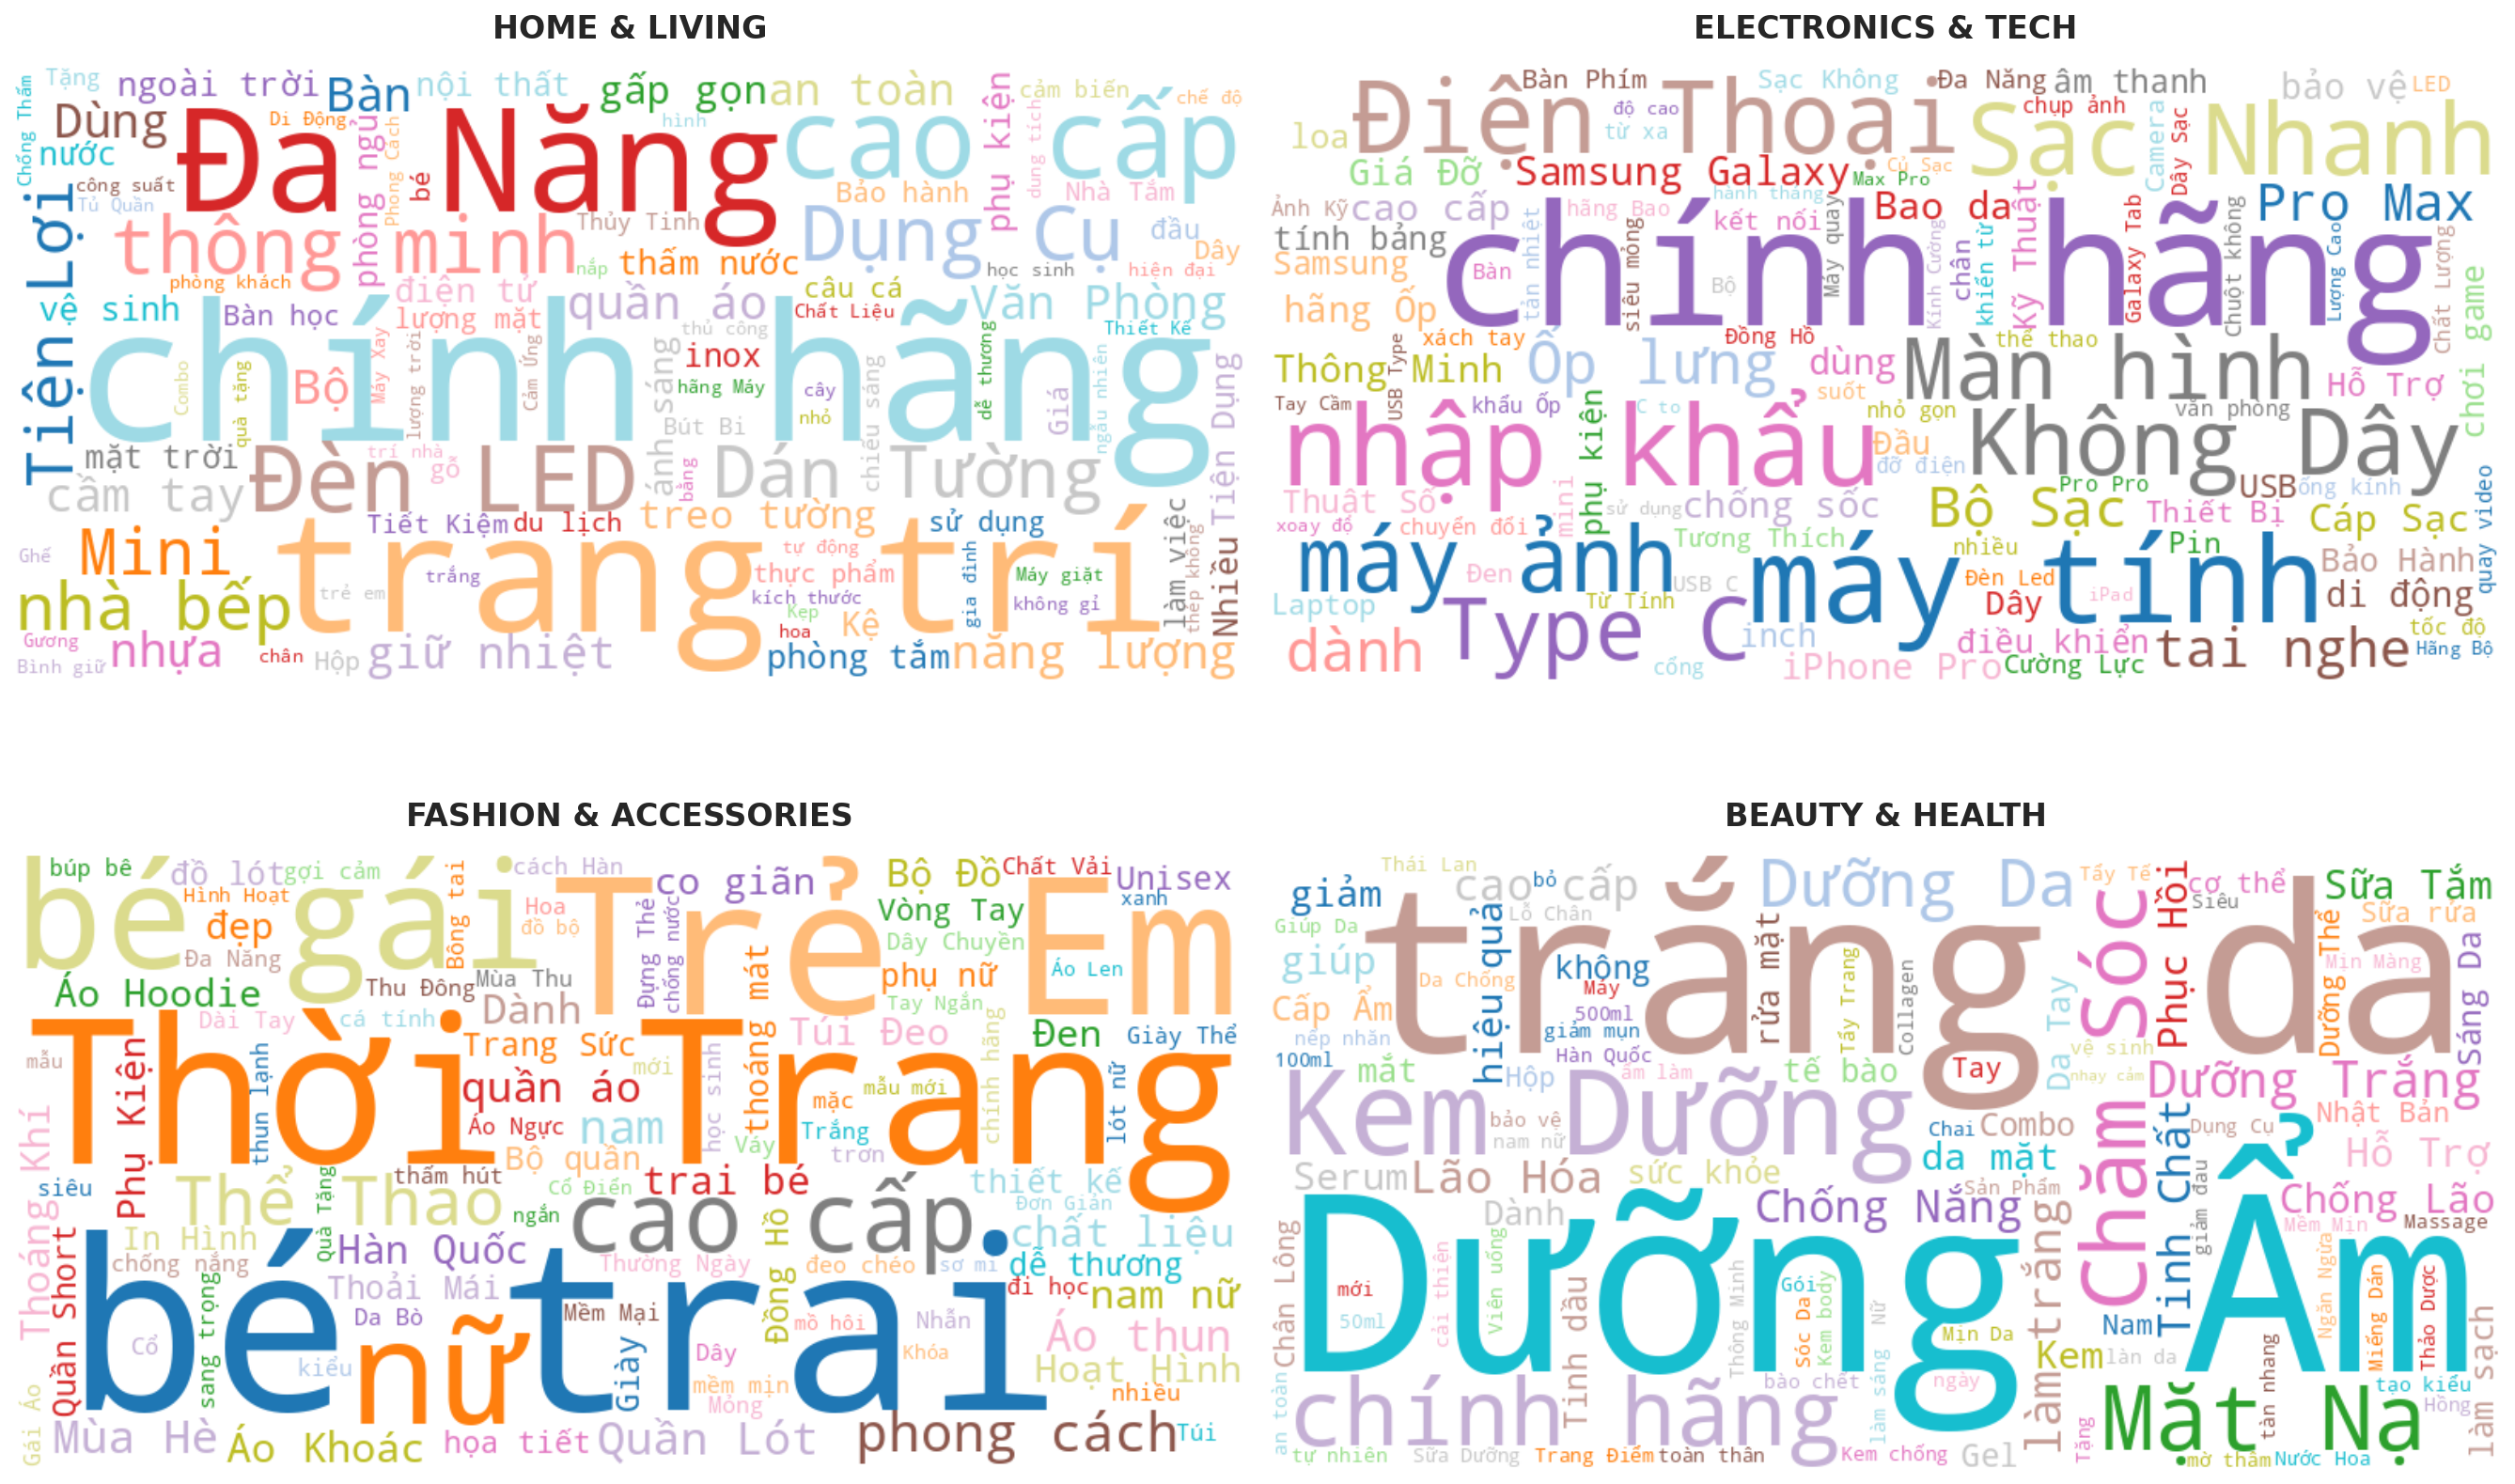

In [92]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

vi_stopwords = ['và', 'của', 'các', 'có', 'cho', 'với', 'trong', 'là', 'được', 'những',
                'một', 'để', 'này', 'loại', 'cái', 'sự', 'hàng', 'kèm', 'màu', 'size']

industries = df['industry_group'].dropna().unique()

fig_bar, axes_bar = plt.subplots(2, 2, figsize=(20, 14))
axes_bar = axes_bar.flatten()

for i, ind in enumerate(industries):
    corpus = df[df['industry_group'] == ind][text_col].dropna().astype(str).tolist()

    # Lấy cả 1-gram và 2-gram (Cụm 1 đến 2 từ)
    vec = CountVectorizer(ngram_range=(1, 2), stop_words=vi_stopwords, max_features=20)
    try:
        bag_of_words = vec.fit_transform(corpus)
        sum_words = bag_of_words.sum(axis=0)

        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

        df_freq = pd.DataFrame(words_freq, columns=['Từ khóa', 'Tần suất'])

        sns.barplot(data=df_freq, x='Tần suất', y='Từ khóa', ax=axes_bar[i], palette='viridis', legend=False)
        axes_bar[i].set_title(f'Top 20 Terms: {ind.upper()}', fontweight='bold', fontsize=14)
        axes_bar[i].set_ylabel('')

        # Thêm text tần suất vào đuôi
        for p in axes_bar[i].patches:
            width = p.get_width()
            axes_bar[i].text(width + 2, p.get_y() + p.get_height()/2, f'{int(width)}', va='center')

    except ValueError:
        pass

plt.suptitle('TOP 20 TỪ / CỤM TỪ ĐẶC TRƯNG NHẤT THEO TỪNG NGÀNH HÀNG', fontweight='bold', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

fig_wc, axes_wc = plt.subplots(2, 2, figsize=(18, 12))
axes_wc = axes_wc.flatten()

for i, ind in enumerate(industries):
    # Gom toàn bộ text của 1 ngành thành 1 chuỗi khổng lồ
    text = " ".join(df[df['industry_group'] == ind][text_col].dropna().astype(str).tolist())

    # Tạo Word Cloud
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          stopwords=set(vi_stopwords),
                          colormap='tab20',
                          max_words=100,
                          contour_width=1,
                          contour_color='steelblue').generate(text)

    axes_wc[i].imshow(wordcloud, interpolation='bilinear')
    axes_wc[i].set_title(f'{ind.upper()}', fontweight='bold', fontsize=16, pad=15)
    axes_wc[i].axis("off")

plt.tight_layout()
plt.show()

**Insight — Độ dài tiêu đề:**
- Phân phối word count dạng **right-skewed**: đa số tập trung ở 8–15 từ, nhưng có đuôi dài với outlier >30 từ thường chứa keyword stuffing.
- **Electronics & Tech** có độ dài trung bình cao nhất — tiêu đề ngành này liệt kê nhiều thông số (RAM, storage, màn hình...) và là thách thức đặc biệt cho tokenizer.
- **Tiêu đề <= 1 từ** là anomaly rõ ràng → loại bỏ trong pipeline.
- **Tiêu đề > 200 ký tự** chiếm tỷ lệ nhỏ nhưng nên kiểm tra thủ công trước khi annotation.
- Top N-gram và WordCloud xác nhận từ khóa đặc trưng theo ngành — có thể tham chiếu khi xây dựng từ điển hỗ trợ NER.


--- Top 2-grams: Sàn TIKI | Ngành HOME & LIVING ---
        Phrase  Frequency
0   chính hãng        752
1   hàng chính        664
2      cao cấp        266
3      đa năng        211
4    giữ nhiệt        138
5    trang trí        132
6   thông minh        120
7     tiện lợi        106
8  hãng miniin         87
9   treo tường         77


/tmp/ipykernel_1123/2182852266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2g, x='Frequency', y='Phrase', palette='viridis')


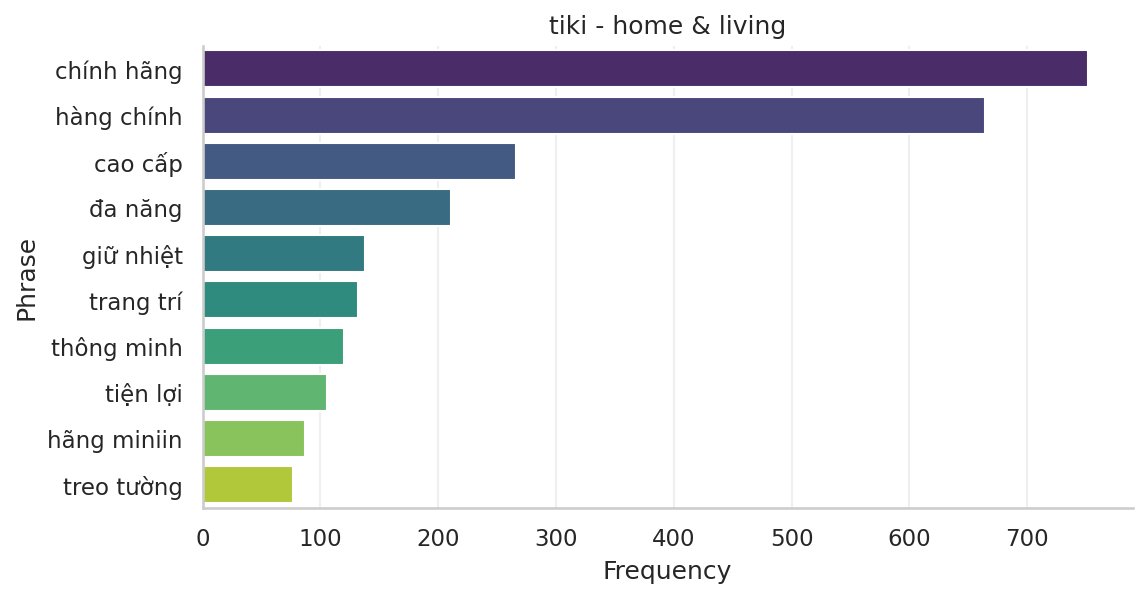


--- Top 2-grams: Sàn TIKI | Ngành ELECTRONICS & TECH ---
           Phrase  Frequency
0      chính hãng       1177
1      hàng chính       1111
2       nhập khẩu        460
3       hàng nhập        458
4        dành cho        267
5         ốp lưng        260
6      cho iphone        209
7         pro max        188
8     cho samsung        163
9  samsung galaxy        157


/tmp/ipykernel_1123/2182852266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2g, x='Frequency', y='Phrase', palette='viridis')


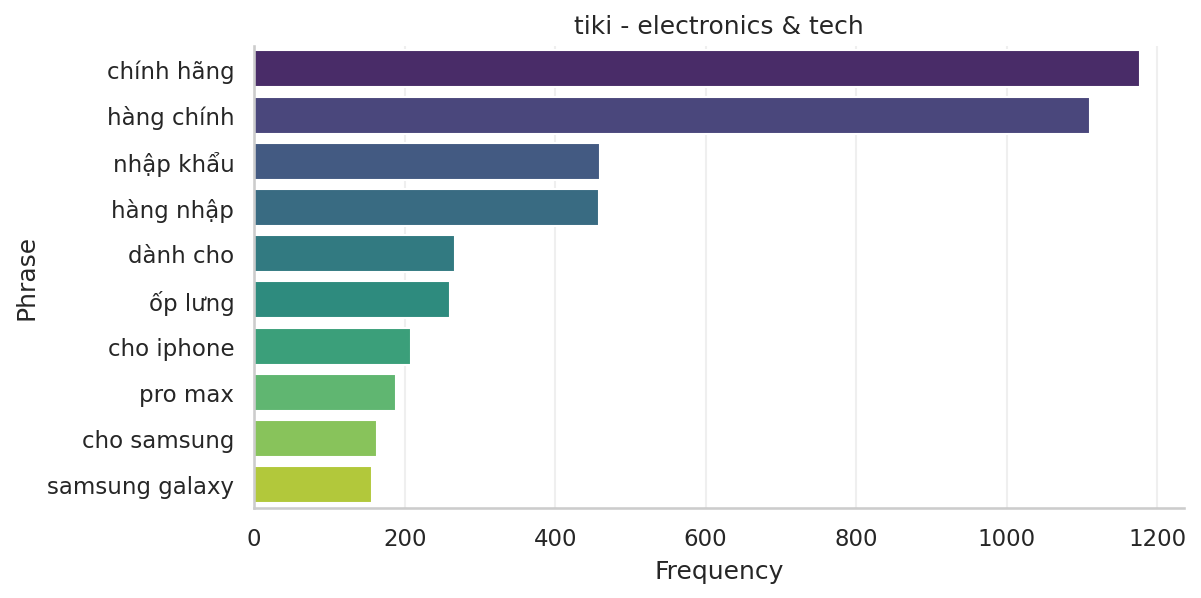


--- Top 2-grams: Sàn TIKI | Ngành FASHION & ACCESSORIES ---
       Phrase  Frequency
0     cao cấp        267
1  thời trang        144
2       da bò        101
3  phong cách         96
4  chính hãng         85
5      nam nữ         80
6    quần lót         76
7     đồng hồ         69
8    hàn quốc         60
9   chất liệu         59


/tmp/ipykernel_1123/2182852266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2g, x='Frequency', y='Phrase', palette='viridis')


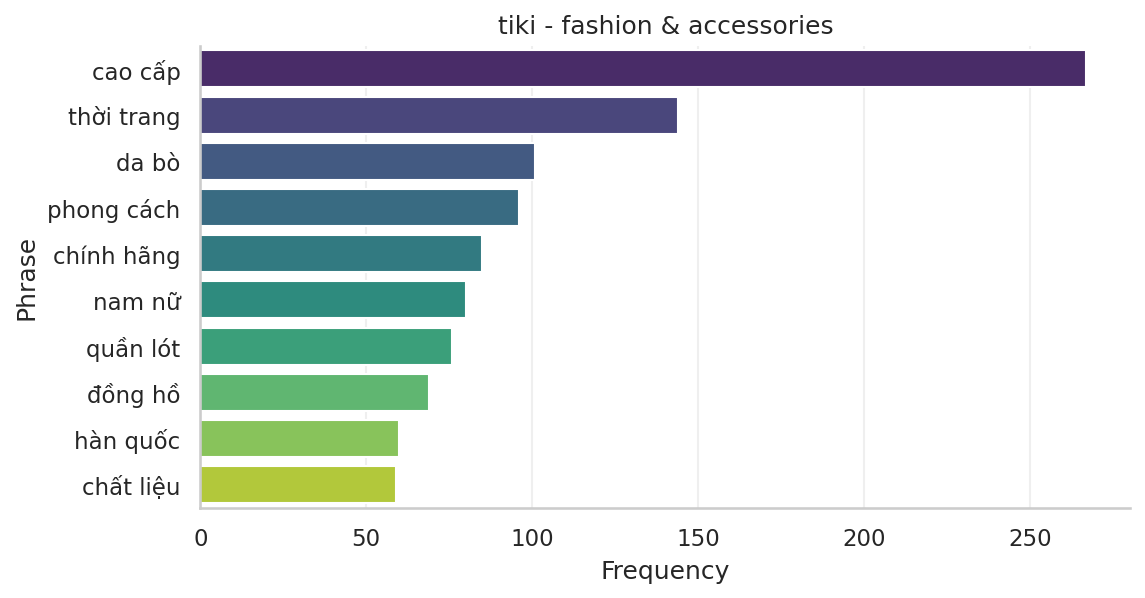


--- Top 2-grams: Sàn TIKI | Ngành BEAUTY & HEALTH ---
       Phrase  Frequency
0  chính hãng         86
1  hàng chính         58
2    tinh dầu         58
3     cao cấp         54
4      hỗ trợ         46
5  chống nắng         45
6    nhật bản         41
7   viên uống         41
8    nước hoa         37
9   kem dưỡng         33


/tmp/ipykernel_1123/2182852266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2g, x='Frequency', y='Phrase', palette='viridis')


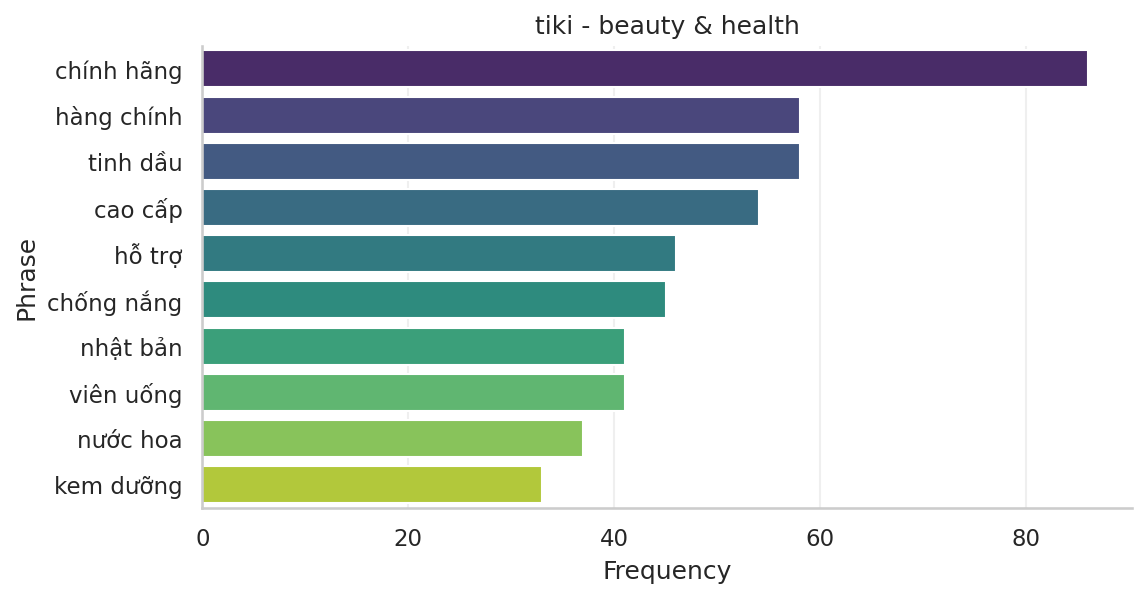


--- Top 2-grams: Sàn LAZADA | Ngành HOME & LIVING ---
       Phrase  Frequency
0   trang trí        487
1     đèn led        251
2     đa năng        242
3  năng lượng        226
4     nhà bếp        224
5     dụng cụ        199
6   dán tường        191
7   văn phòng        182
8     cao cấp        170
9   phòng tắm        166


/tmp/ipykernel_1123/2182852266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2g, x='Frequency', y='Phrase', palette='viridis')


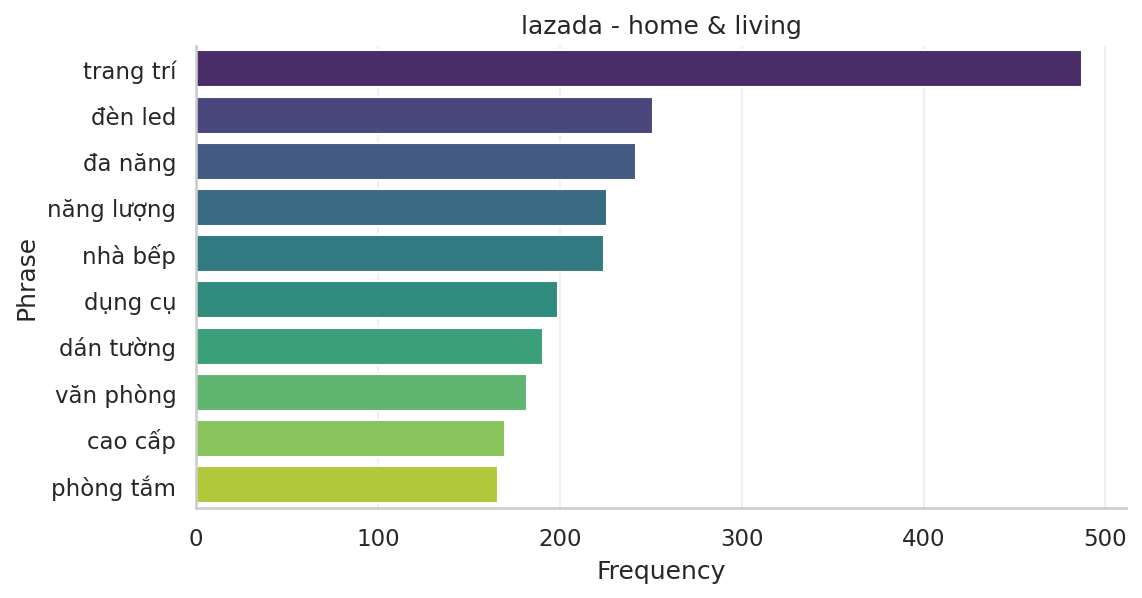


--- Top 2-grams: Sàn LAZADA | Ngành ELECTRONICS & TECH ---
       Phrase  Frequency
0    máy tính        460
1     máy ảnh        337
2   sạc nhanh        299
3  điện thoại        284
4   không dây        263
5      bộ sạc        231
6    màn hình        226
7  thông minh        182
8    tai nghe        170
9  chính hãng        146


/tmp/ipykernel_1123/2182852266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2g, x='Frequency', y='Phrase', palette='viridis')


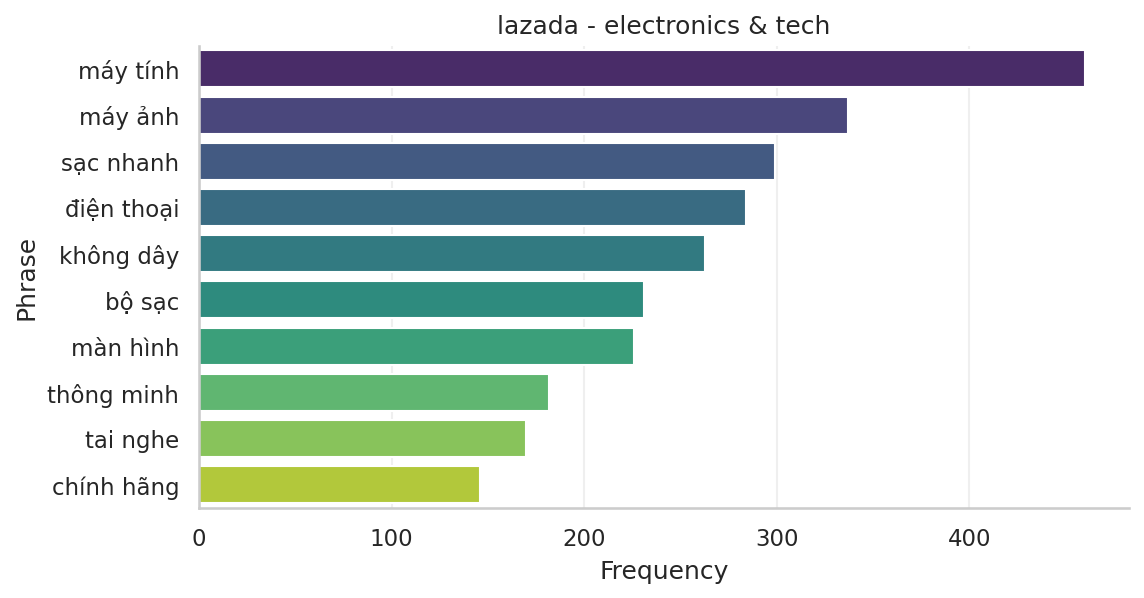


--- Top 2-grams: Sàn LAZADA | Ngành FASHION & ACCESSORIES ---
       Phrase  Frequency
0     bé trai       1230
1      cho bé       1165
2      trẻ em        864
3  thời trang        819
4      bé gái        811
5    thể thao        584
6  phong cách        413
7     cao cấp        391
8      mùa hè        371
9     quần áo        336


/tmp/ipykernel_1123/2182852266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2g, x='Frequency', y='Phrase', palette='viridis')


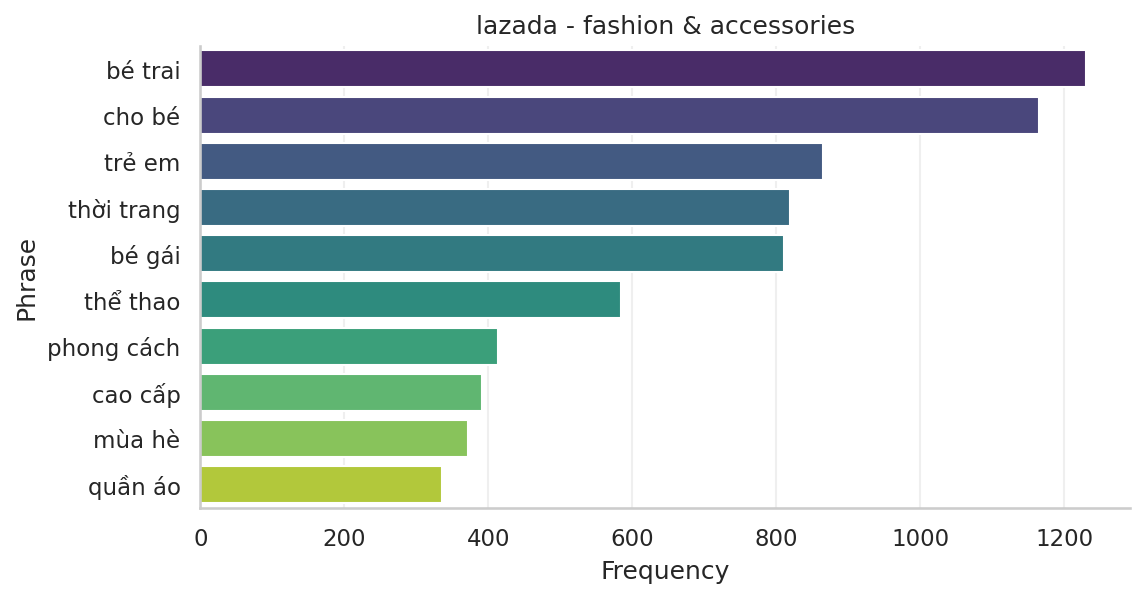


--- Top 2-grams: Sàn LAZADA | Ngành BEAUTY & HEALTH ---
        Phrase  Frequency
0     dưỡng ẩm        412
1     trắng da        368
2    kem dưỡng        264
3       mặt nạ        230
4     chăm sóc        213
5     dưỡng da        170
6    làm trắng        165
7  dưỡng trắng        164
8   chính hãng        157
9      lão hóa        148


/tmp/ipykernel_1123/2182852266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2g, x='Frequency', y='Phrase', palette='viridis')


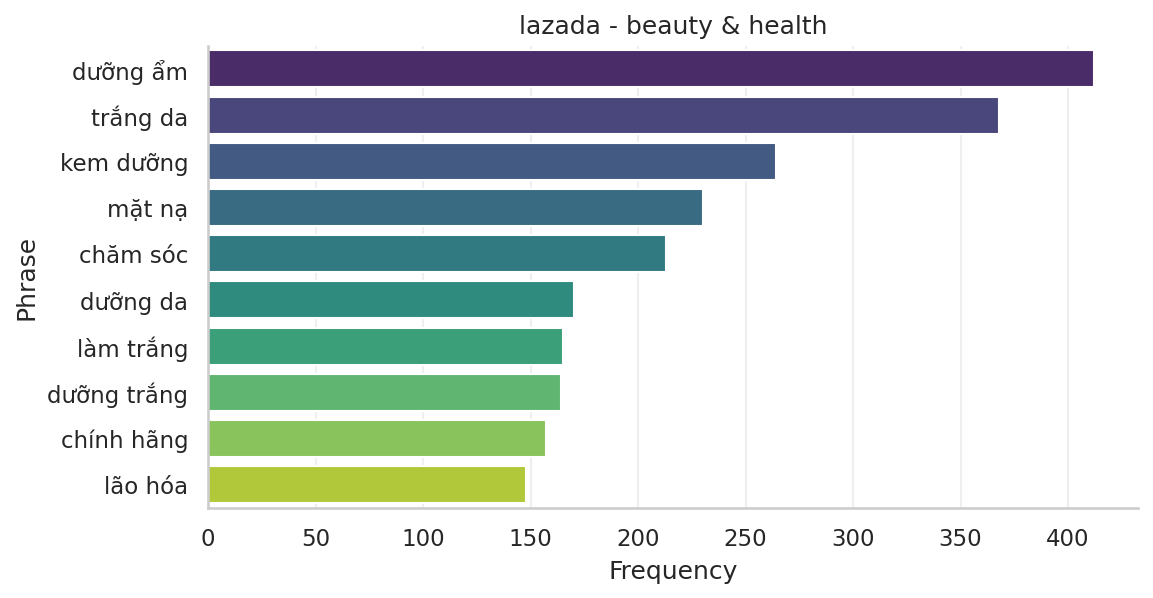

In [93]:
# 1. Hàm trích xuất N-grams cho 1 nhóm cụ thể
def get_top_ngrams(corpus, n=2, top_n=10):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_n], columns=['Phrase', 'Frequency'])

# 2. Vòng lặp chạy cho từng Ngành và Sàn
platforms = df['platform'].unique()
industries = df['industry_group'].unique()

for platform in platforms:
    for industry in industries:
        # Lọc dữ liệu
        subset = df[(df['platform'] == platform) & (df['industry_group'] == industry)]
        corpus = subset['title_clean'].dropna().astype(str).tolist()

        if len(corpus) > 0:
            print(f"\n--- Top 2-grams: Sàn {platform.upper()} | Ngành {industry.upper()} ---")
            df_2g = get_top_ngrams(corpus, n=2, top_n=10)
            print(df_2g)


            plt.figure(figsize=(8,4))
            sns.barplot(data=df_2g, x='Frequency', y='Phrase', palette='viridis')
            plt.title(f'{platform} - {industry}')
            plt.show()

## 6. Phân tích Brand (Brand Analysis)

> **Câu hỏi:** Tỷ lệ sản phẩm không có thương hiệu là bao nhiêu? Dữ liệu brand có bị nhiễu do biến thể viết hoa/thường không? Brand xuất hiện ở vị trí nào trong tiêu đề?

Brand là một trong những entity quan trọng nhất trong NER TMĐT. Phân tích này đánh giá chất lượng và đặc điểm phân phối cột `brand` — cơ sở để thiết kế `_clean_brand_logic` trong pipeline.

In [94]:
print('Số lượng brand:', df['brand'].nunique())

Số lượng brand: 2340


In [95]:
df['brand'].sort_values().tail(90)

,brand
1574,pluslamp
4003,powergra
5652,ratoff-ars
14145,realme
2738,sfarm
...,...
6139,ĐŨI VIỆT
1896,Đại Việt
2736,Đặng Gia Trang
4376,Đức Cường


=== 1. TỔNG QUAN BRAND & TỶ LỆ NO BRAND ===
Tổng số sản phẩm trong Dataset: 19,361
Số lượng sản phẩm KHÔNG CÓ thương hiệu (No Brand): 9,877 (51.01%)
Số lượng sản phẩm CÓ thương hiệu: 9,484 (48.99%)
Số lượng Thương hiệu duy nhất xuất hiện (Vùng phủ Brand xịn): 2,338



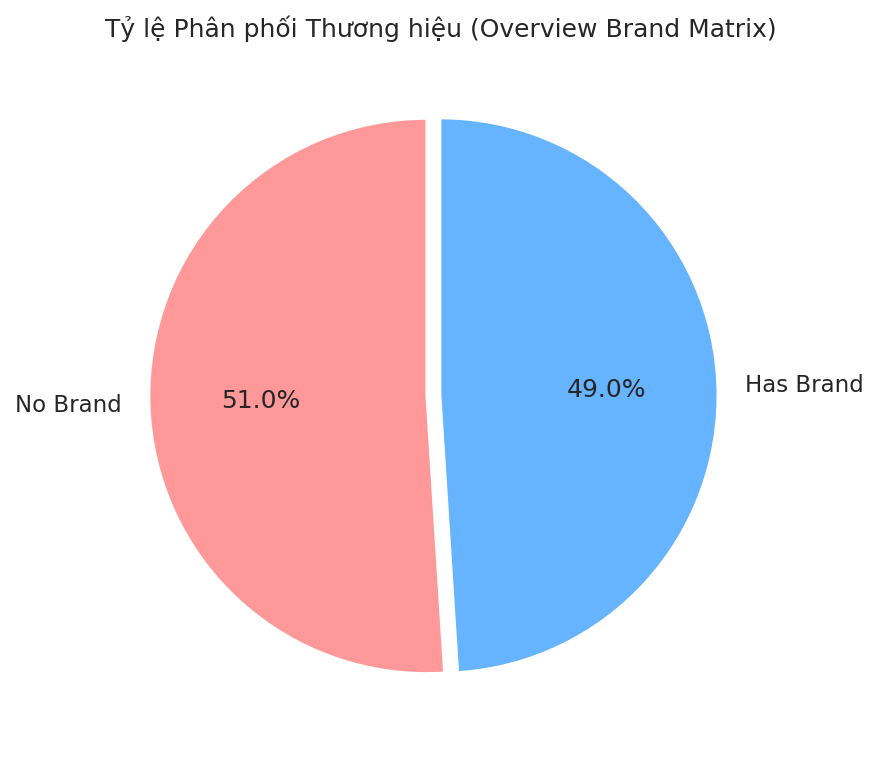

=== 2. TOP 15 BRAND PHỔ BIẾN NHẤT (LOẠI TRỪ NO BRAND) ===
brand
OEM           1090
Elmich         115
MINIIN         112
LocknLock      100
GREENCASE       89
LYNUSAN         75
UGREEN          74
Samsung         59
MINHHA          56
Logitech        52
LuckyJQR        51
MISUFUJl        50
Kai Nguyễn      46
Philips         44
E-WOITD         41
Name: count, dtype: int64




/tmp/ipykernel_1123/3403514556.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.head(top_n).values, y=brand_counts.head(top_n).index, palette='Blues_r')


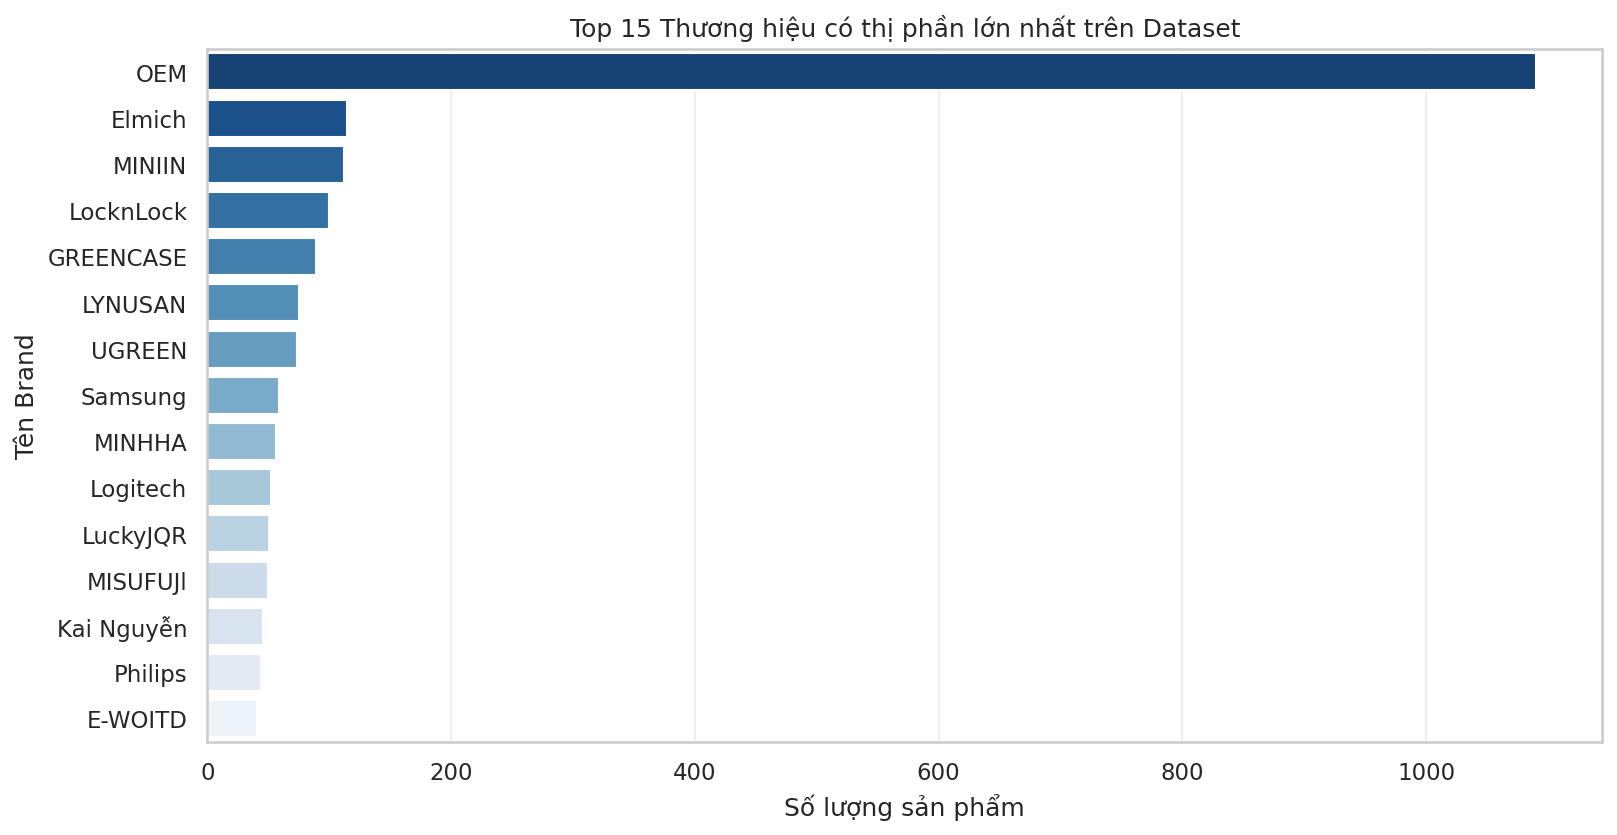

=== 3. PHÂN BỐ BRAND THEO NGÀNH HÀNG (CATEGORY_L1) ===
       industry_group  Total_Products  No_Brand_Count  No_Brand_Rate(%)  Unique_Brands
      beauty & health          2832.0          1605.0             56.67          657.0
   electronics & tech          4243.0          1864.0             43.93          609.0
fashion & accessories          5776.0          3778.0             65.41          460.0
        home & living          6510.0          2630.0             40.40          939.0




/tmp/ipykernel_1123/3403514556.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_brand_summary = self.df.groupby(self.cat_col).apply(


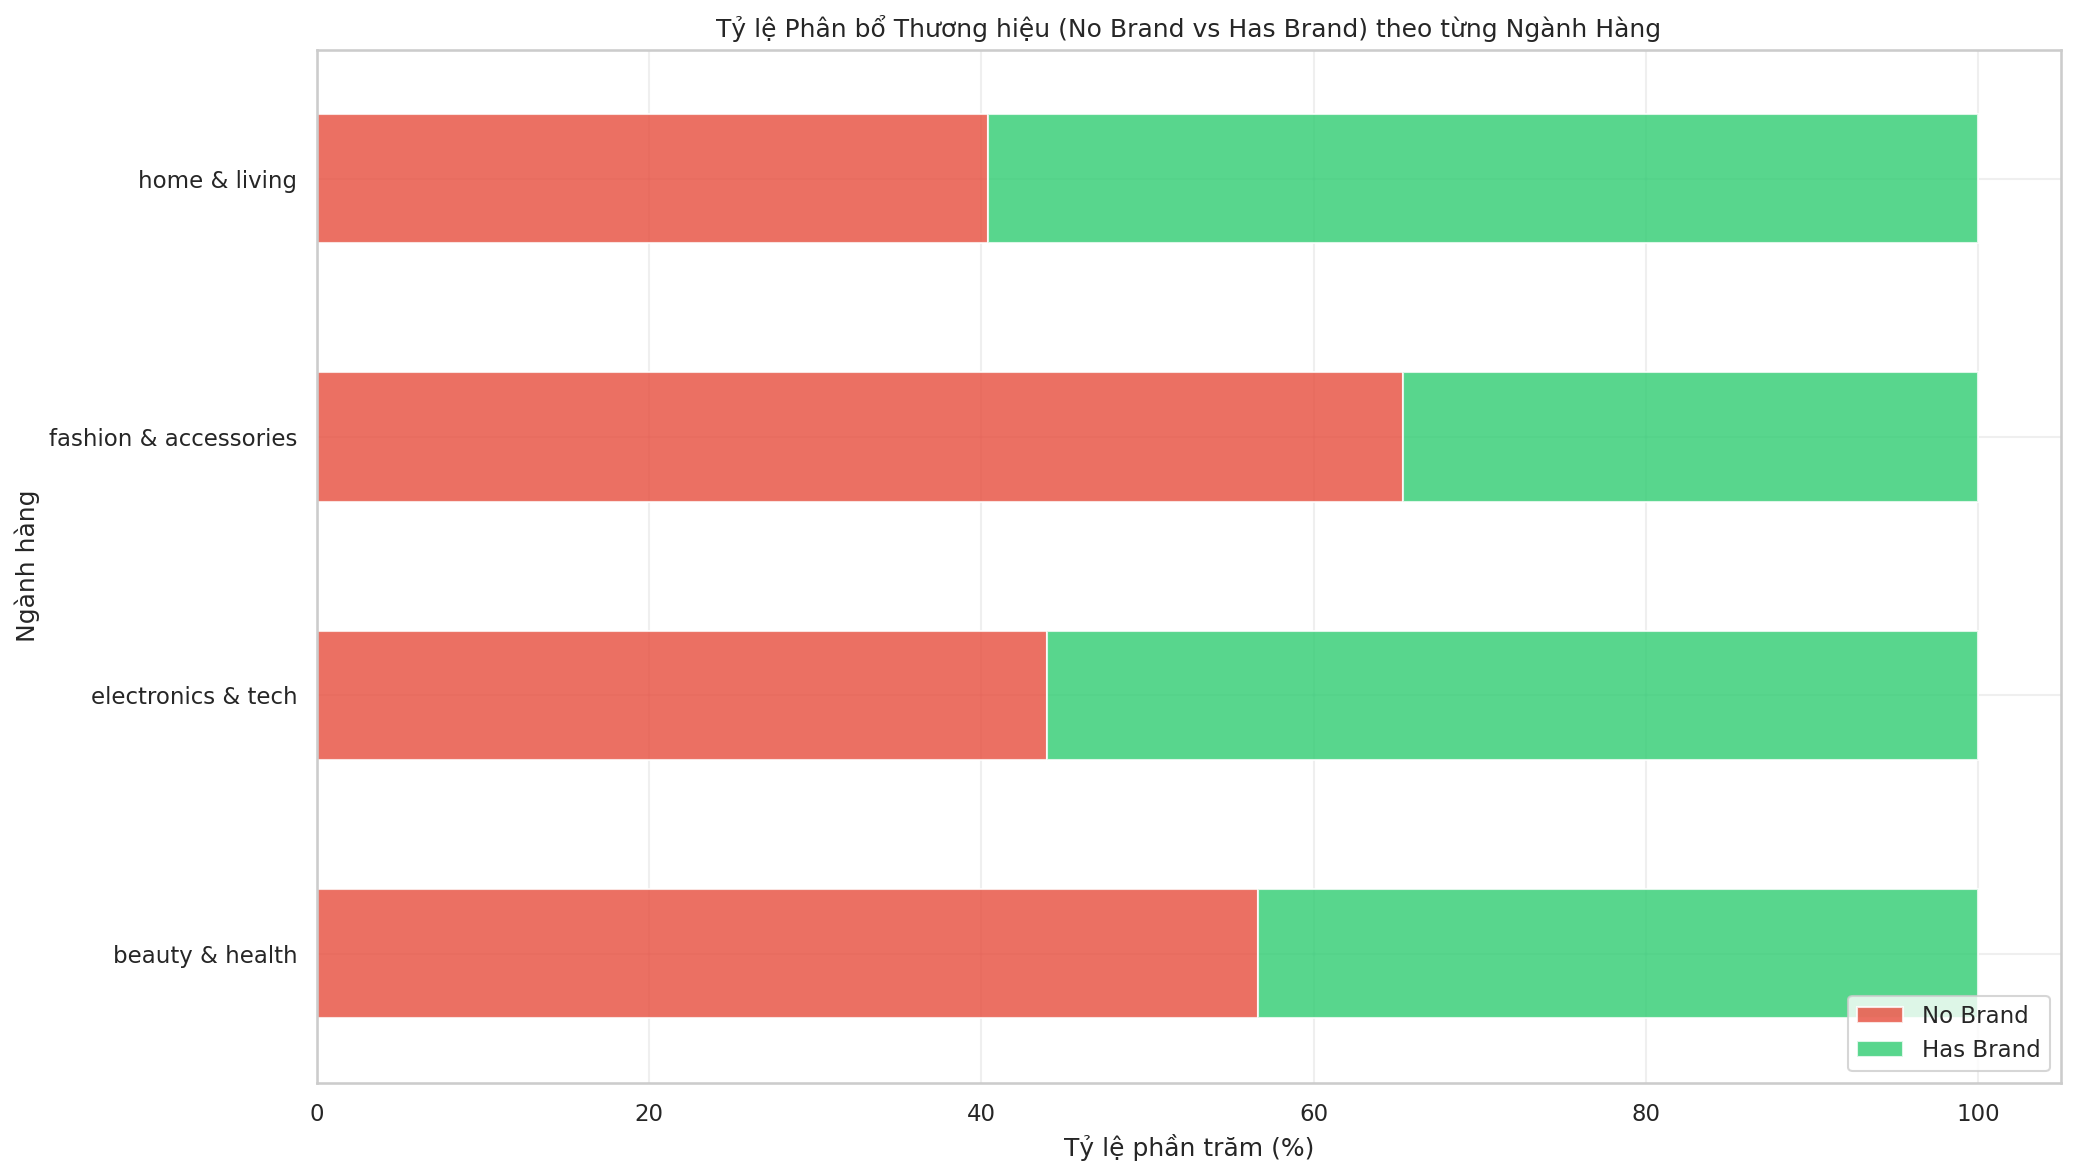

=== 4. CHẤT LƯỢNG DỮ LIỆU BRAND (VARIANTS, CASE SENSITIVE NOISE) ===
⚠️ Phát hiện 31 nhóm Thương hiệu bị nhiễu biến thể viết hoa/thường:
   • Nhóm gốc 'asus': Đang bị phân mảnh thành các nhãn ['Asus', 'ASUS']
   • Nhóm gốc 'aqua': Đang bị phân mảnh thành các nhãn ['Aqua', 'AQUA']
   • Nhóm gốc 'unitek': Đang bị phân mảnh thành các nhãn ['Unitek', 'UNITEK']
   • Nhóm gốc 'deli': Đang bị phân mảnh thành các nhãn ['Deli', 'deli']
   • Nhóm gốc 'coocaa': Đang bị phân mảnh thành các nhãn ['coocaa', 'Coocaa']
   • Nhóm gốc 'bee gee': Đang bị phân mảnh thành các nhãn ['Bee Gee', 'BEE GEE']
   • Nhóm gốc 'suunto': Đang bị phân mảnh thành các nhãn ['SUUNTO', 'Suunto']
   • Nhóm gốc 'legaxi': Đang bị phân mảnh thành các nhãn ['Legaxi', 'LeGaXi']
   • Nhóm gốc 'yamato': Đang bị phân mảnh thành các nhãn ['YAMATO', 'Yamato']
   • Nhóm gốc 'bát tràng': Đang bị phân mảnh thành các nhãn ['Bát Tràng', 'BÁT TRÀNG']


=== 5. PHÂN TÍCH PATTERN VỊ TRÍ VÀ BIGRAM CỦA BRAND TRONG TITLE ===
📍 Thống kê phân phố

In [96]:
sns.set_theme(style="whitegrid")

class EcomBrandAnalyzer:
    def __init__(self, df, title_col='title_clean', brand_col='brand', cat_col='industry_group'):
        self.df = df.copy()
        self.title_col = title_col
        self.brand_col = brand_col
        self.cat_col = cat_col

        # Chuẩn hóa giá trị rỗng của brand về 'No Brand'
        self.df[self.brand_col] = self.df[self.brand_col].fillna('No Brand').replace(['no brand', 'NoBrand', 'nobrand', ''], 'No Brand')

    def run_overview_analysis(self):
        print("=== 1. TỔNG QUAN BRAND & TỶ LỆ NO BRAND ===")
        total_records = len(self.df)
        nobrand_count = (self.df[self.brand_col] == 'No Brand').sum()
        has_brand_count = total_records - nobrand_count
        unique_brands = self.df[self.brand_col].nunique() - (1 if nobrand_count > 0 else 0)

        print(f"Tổng số sản phẩm trong Dataset: {total_records:,}")
        print(f"Số lượng sản phẩm KHÔNG CÓ thương hiệu (No Brand): {nobrand_count:,} ({nobrand_count/total_records*100:.2f}%)")
        print(f"Số lượng sản phẩm CÓ thương hiệu: {has_brand_count:,} ({has_brand_count/total_records*100:.2f}%)")
        print(f"Số lượng Thương hiệu duy nhất xuất hiện (Vùng phủ Brand xịn): {unique_brands:,}\n")

        # Vẽ biểu đồ tròn Overview
        plt.figure(figsize=(6, 6))
        plt.pie([nobrand_count, has_brand_count], labels=['No Brand', 'Has Brand'],
                autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.05, 0))
        plt.title('Tỷ lệ Phân phối Thương hiệu (Overview Brand Matrix)')
        plt.show()

    def run_top_brands(self, top_n=15):
        print(f"=== 2. TOP {top_n} BRAND PHỔ BIẾN NHẤT (LOẠI TRỪ NO BRAND) ===")
        brand_counts = self.df[self.df[self.brand_col] != 'No Brand'][self.brand_col].value_counts()
        print(brand_counts.head(top_n))
        print("\n")

        plt.figure(figsize=(12, 6))
        sns.barplot(x=brand_counts.head(top_n).values, y=brand_counts.head(top_n).index, palette='Blues_r')
        plt.title(f'Top {top_n} Thương hiệu có thị phần lớn nhất trên Dataset')
        plt.xlabel('Số lượng sản phẩm')
        plt.ylabel('Tên Brand')
        plt.show()

    def run_category_brand_distribution(self):
        print("=== 3. PHÂN BỐ BRAND THEO NGÀNH HÀNG (CATEGORY_L1) ===")
        # Tính tỷ lệ No Brand theo từng ngành
        cat_brand_summary = self.df.groupby(self.cat_col).apply(
            lambda x: pd.Series({
                'Total_Products': len(x),
                'No_Brand_Count': (x[self.brand_col] == 'No Brand').sum(),
                'No_Brand_Rate(%)': round(((x[self.brand_col] == 'No Brand').sum() / len(x)) * 100, 2),
                'Unique_Brands': x[x[self.brand_col] != 'No Brand'][self.brand_col].nunique()
            })
        ).reset_index()

        print(cat_brand_summary.to_string(index=False))
        print("\n")

        # Vẽ biểu đồ cột chồng (Stacked Bar Chart) tỷ lệ No Brand vs Has Brand theo ngành
        pivot_df = self.df.groupby([self.cat_col, self.brand_col]).size().unstack(fill_value=0)
        pivot_rate = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

        # Tách cột No Brand và phần còn lại
        plot_data = pd.DataFrame({
            'No Brand': pivot_rate['No_Brand'] if 'No_Brand' in pivot_rate else pivot_rate['No Brand'],
            'Has Brand': 100 - (pivot_rate['No_Brand'] if 'No_Brand' in pivot_rate else pivot_rate['No Brand'])
        })

        plot_data.plot(kind='barh', stacked=True, figsize=(14, 8), color=['#e74c3c', '#2ecc71'], alpha=0.8)
        plt.title('Tỷ lệ Phân bổ Thương hiệu (No Brand vs Has Brand) theo từng Ngành Hàng')
        plt.xlabel('Tỷ lệ phần trăm (%)')
        plt.ylabel('Ngành hàng')
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.show()

    def check_brand_quality_and_noise(self):
        print("=== 4. CHẤT LƯỢNG DỮ LIỆU BRAND (VARIANTS, CASE SENSITIVE NOISE) ===")
        # Tìm các biến thể chữ hoa chữ thường bị lệch nhãn (Ví dụ: apple, Apple, APPLE)
        all_brands = self.df[self.df[self.brand_col] != 'No Brand'][self.brand_col].dropna().unique()
        brand_lower_map = {}
        for b in all_brands:
            brand_lower_map.setdefault(b.lower(), []).append(b)

        variants = {k: v for k, v in brand_lower_map.items() if len(v) > 1}

        if not variants:
            print("🎉 Tuyệt vời: Không phát hiện nhiễu Case-sensitive (Trùng tên nhưng lệch Hoa/Thường).")
        else:
            print(f"⚠️ Phát hiện {len(variants)} nhóm Thương hiệu bị nhiễu biến thể viết hoa/thường:")
            for lower_name, exact_names in list(variants.items())[:10]: # In ra tối đa 10 nhóm mẫu
                print(f"   • Nhóm gốc '{lower_name}': Đang bị phân mảnh thành các nhãn {exact_names}")
        print("\n")

    def run_brand_pattern_in_title(self):
        print("=== 5. PHÂN TÍCH PATTERN VỊ TRÍ VÀ BIGRAM CỦA BRAND TRONG TITLE ===")

        position_indices = []
        bigram_list = []

        # Chỉ xét những dòng có thương hiệu xịn để tìm quy luật viết title của seller
        sub_df = self.df[(self.df[self.brand_col] != 'No Brand')].dropna(subset=[self.title_col])

        for idx, row in sub_df.iterrows():
            title = str(row[self.title_col]).lower()
            brand = str(row[self.brand_col]).lower()

            # Tìm vị trí index của từ khóa Brand trong Title
            if brand in title:
                tokens = title.split()
                try:
                    brand_first_word = brand.split()[0]
                    if brand_first_word in tokens:
                        word_pos = tokens.index(brand_first_word)
                        # Phân mảnh vị trí: Đầu câu (0-2 từ đầu), Giữa câu, Cuối câu
                        if word_pos <= 2:
                            position_indices.append("Đầu tiêu đề (Top 3 từ đầu)")
                        elif word_pos >= len(tokens) - 3:
                            position_indices.append("Cuối tiêu đề (Bottom 3 từ cuối)")
                        else:
                            position_indices.append("Giữa tiêu đề")

                        # Khai thác Bigram ngữ cảnh bao quanh Brand (Brand + từ tiếp theo)
                        if word_pos < len(tokens) - 1:
                            bigram_list.append(f"{brand} {tokens[word_pos + 1]}")
                except Exception:
                    continue

        # Thống kê vị trí xuất hiện
        pos_counts = Counter(position_indices)
        print("📍 Thống kê phân phối vị trí đặt tên Brand trong Tiêu đề:")
        for pos, count in pos_counts.items():
            print(f"   • {pos}: {count} lần ({count/len(position_indices)*100:.2f}%)")

        print("\n🔥 Top 10 Bigram ngữ cảnh phổ biến nhất chứa cấu trúc [Brand + Token_Kế_Tiếp]:")
        bigram_counts = Counter(bigram_list).most_common(10)
        for bigram, count in bigram_counts:
            print(f"   • [{bigram}]: Xuất hiện {count} lần")
        print("-" * 70)


analyzer = EcomBrandAnalyzer(df, title_col='title_clean', brand_col='brand', cat_col='industry_group')
analyzer.run_overview_analysis()
analyzer.run_top_brands()
analyzer.run_category_brand_distribution()
analyzer.check_brand_quality_and_noise()
analyzer.run_brand_pattern_in_title()

**Insight — Brand:**
- Tỷ lệ **No Brand** cao trong nhóm **Fashion** (hàng dropship, SME) và thấp hơn đáng kể trong **Electronics** — phản ánh mức độ thương hiệu hóa khác nhau giữa ngành.
- Phát hiện **case-sensitive variants** (`Samsung`, `samsung`, `SAMSUNG`) xác nhận cần chuẩn hóa lowercase cho cột brand trước khi dùng làm reference cho NER.
- **Vị trí brand trong tiêu đề:** Brand có xu hướng xuất hiện ở đầu hoặc giữa tiêu đề — nhất quán với cách viết tiêu đề chuẩn của các sàn TMĐT. Pattern này sẽ là prior hữu ích cho mô hình NER.
- **Quyết định pipeline:** Chuẩn hóa brand về lowercase, gộp các biến thể đồng nghĩa (`No Brand`, `NoBrand` → `no brand`), và dùng brand list làm dictionary feature khi annotation.

---

## Tổng kết EDA — Cơ sở cho CleaningPipeline

| Vấn đề phát hiện | Quyết định pipeline |
|---|---|
| Missing giá (MCAR) | `dropna(subset=['price'])` |
| Nhiễu ký tự (emoji, URL, khoảng trắng) | `_clean_text_logic()` với regex whitelist |
| Code-switching phổ biến | Không lọc ngôn ngữ, giữ nguyên |
| Boilerplate terms | Ghi nhận, không xóa — tham chiếu annotation guideline |
| Exact & near-duplicates | Dedup exact → near-dedup TF-IDF cosine 0.90 |
| Outlier tiêu đề (<=1 từ) | Lọc bỏ trong pipeline |
| Brand case-sensitive variants | `_clean_brand_logic()` lowercase + gộp alias |